#📌 Extracción

In [2]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 1: Importar datos desde la API y convertir a DataFrame
# ============================================================

import requests
import pandas as pd
import json

# ── 1. Cargar los datos desde la API ──────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)

# Verificar que la solicitud fue exitosa
if response.status_code == 200:
    print("✅ Datos cargados exitosamente desde la API.")
else:
    print(f"❌ Error al cargar los datos. Código de estado: {response.status_code}")

# ── 2. Convertir el JSON a un objeto Python ───────────────────
data = response.json()

# Exploración inicial del tipo de dato recibido
print(f"\n📦 Tipo de dato recibido: {type(data)}")

# Si es una lista, mostramos cuántos registros hay
if isinstance(data, list):
    print(f"📊 Número de registros: {len(data)}")
    print(f"\n🔍 Primer registro de ejemplo:")
    print(json.dumps(data[0], indent=2, ensure_ascii=False))

# Si es un diccionario, mostramos las claves disponibles
elif isinstance(data, dict):
    print(f"🔑 Claves disponibles: {list(data.keys())}")

# ── 3. Convertir a DataFrame de Pandas ───────────────────────
df = pd.json_normalize(data)

print("\n" + "="*60)
print("📋 INFORMACIÓN DEL DATAFRAME")
print("="*60)

# Dimensiones del DataFrame
print(f"\n📐 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

# Primeras filas
print("\n🔎 Primeras 5 filas:")
print(df.head())

# Información general (tipos de datos y valores nulos)
print("\n📊 Información general del DataFrame:")
print(df.info())

# Vista general de columnas disponibles
print("\n📝 Columnas disponibles:")
for col in df.columns:
    print(f"  - {col}")

✅ Datos cargados exitosamente desde la API.

📦 Tipo de dato recibido: <class 'list'>
📊 Número de registros: 7267

🔍 Primer registro de ejemplo:
{
  "customerID": "0002-ORFBO",
  "Churn": "No",
  "customer": {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "Yes",
    "tenure": 9
  },
  "phone": {
    "PhoneService": "Yes",
    "MultipleLines": "No"
  },
  "internet": {
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "Yes",
    "StreamingTV": "Yes",
    "StreamingMovies": "No"
  },
  "account": {
    "Contract": "One year",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Mailed check",
    "Charges": {
      "Monthly": 65.6,
      "Total": "593.3"
    }
  }
}

📋 INFORMACIÓN DEL DATAFRAME

📐 Dimensiones: 7267 filas x 21 columnas

🔎 Primeras 5 filas:
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Fe

#🔧 Transformación

In [3]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 2: Exploración del dataset y diccionario de datos
# ============================================================

import requests
import pandas as pd
import json

# ── Cargar datos (mismo proceso del Paso 1) ───────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

print("="*60)
print("📋 PASO 2: EXPLORACIÓN DEL DATASET")
print("="*60)

# ── 1. Dimensiones generales ──────────────────────────────────
print(f"\n📐 Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

# ── 2. Tipos de datos por columna ─────────────────────────────
print("\n📊 Tipos de datos por columna:")
print(df.dtypes)

# ── 3. Información general ────────────────────────────────────
print("\n📊 Información general (info):")
df.info()

# ── 4. Vista previa de los datos ──────────────────────────────
print("\n🔎 Primeras 5 filas del dataset:")
print(df.head())

# ── 5. Diccionario de datos ───────────────────────────────────
print("\n" + "="*60)
print("📖 DICCIONARIO DE DATOS")
print("="*60)

diccionario = {
    # Identificación
    "customerID":                       "Identificador único del cliente",

    # Datos demográficos
    "customer.gender":                  "Género del cliente (Male / Female)",
    "customer.SeniorCitizen":           "Indica si es adulto mayor (1 = Sí, 0 = No)",
    "customer.Partner":                 "Tiene pareja (Yes / No)",
    "customer.Dependents":              "Tiene dependientes (Yes / No)",

    # Relación con la empresa
    "customer.tenure":                  "Meses que el cliente lleva con la empresa",

    # Servicios contratados - Telefonía
    "phone.PhoneService":               "Tiene servicio telefónico (Yes / No)",
    "phone.MultipleLines":              "Tiene múltiples líneas (Yes / No / No phone service)",

    # Servicios contratados - Internet
    "internet.InternetService":         "Tipo de servicio de internet (DSL / Fiber optic / No)",
    "internet.OnlineSecurity":          "Tiene seguridad en línea (Yes / No / No internet service)",
    "internet.OnlineBackup":            "Tiene respaldo en línea (Yes / No / No internet service)",
    "internet.DeviceProtection":        "Tiene protección de dispositivo (Yes / No / No internet service)",
    "internet.TechSupport":             "Tiene soporte técnico (Yes / No / No internet service)",
    "internet.StreamingTV":             "Tiene streaming de TV (Yes / No / No internet service)",
    "internet.StreamingMovies":         "Tiene streaming de películas (Yes / No / No internet service)",

    # Contrato y facturación
    "account.Contract":                 "Tipo de contrato (Month-to-month / One year / Two year)",
    "account.PaperlessBilling":         "Facturación sin papel (Yes / No)",
    "account.PaymentMethod":            "Método de pago (Electronic check / Mailed check / Bank transfer / Credit card)",
    "account.Charges.Monthly":          "Cargo mensual en dólares",
    "account.Charges.Total":            "Cargo total acumulado en dólares",

    # Variable objetivo
    "Churn":                            "⭐ VARIABLE OBJETIVO: Si el cliente canceló el servicio (Yes / No)",
}

# Mostrar el diccionario de forma organizada
for columna, descripcion in diccionario.items():
    # Verificar si la columna existe en el DataFrame
    existe = "✅" if columna in df.columns else "❓"
    print(f"  {existe} {columna:<40} → {descripcion}")

# ── 6. Columnas más relevantes para el análisis de Churn ──────
print("\n" + "="*60)
print("🎯 COLUMNAS MÁS RELEVANTES PARA EL ANÁLISIS DE EVASIÓN")
print("="*60)

relevantes = {
    "🔴 Variable objetivo":    ["Churn"],
    "📅 Antigüedad":           ["customer.tenure"],
    "💰 Facturación":          ["account.Charges.Monthly", "account.Charges.Total"],
    "📄 Tipo de contrato":     ["account.Contract"],
    "🌐 Tipo de internet":     ["internet.InternetService"],
    "👤 Demografía":           ["customer.SeniorCitizen", "customer.Partner", "customer.Dependents"],
    "📱 Servicios extra":      ["internet.OnlineSecurity", "internet.TechSupport",
                                "internet.StreamingTV", "internet.StreamingMovies"],
    "💳 Método de pago":       ["account.PaymentMethod", "account.PaperlessBilling"],
}

for categoria, columnas in relevantes.items():
    print(f"\n  {categoria}:")
    for col in columnas:
        existe = "✅" if col in df.columns else "❓"
        print(f"    {existe} {col}")

print("\n✅ Exploración completada. Listo para el siguiente paso: limpieza y transformación de datos.")

📋 PASO 2: EXPLORACIÓN DEL DATASET

📐 Dimensiones del dataset: 7267 filas x 21 columnas

📊 Tipos de datos por columna:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneService            object
phone.MultipleLines           object
internet.InternetService      object
internet.OnlineSecurity       object
internet.OnlineBackup         object
internet.DeviceProtection     object
internet.TechSupport          object
internet.StreamingTV          object
internet.StreamingMovies      object
account.Contract              object
account.PaperlessBilling      object
account.PaymentMethod         object
account.Charges.Monthly      float64
account.Charges.Total         object
dtype: object

📊 Información general (info):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entri

In [4]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 3: Verificación de calidad de datos (ETL - Transformación)
# ============================================================

import requests
import pandas as pd
import numpy as np
import json

# ── Cargar datos ──────────────────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

print("="*60)
print("🔍 PASO 3: VERIFICACIÓN DE CALIDAD DE DATOS")
print("="*60)
print(f"\n📐 Dataset original: {df.shape[0]} filas x {df.shape[1]} columnas")

# ================================================================
# 1. VALORES AUSENTES (Nulls / NaN)
# ================================================================
print("\n" + "="*60)
print("1️⃣  VALORES AUSENTES")
print("="*60)

nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({
    "Valores Nulos": nulos,
    "Porcentaje (%)": nulos_pct
}).query("`Valores Nulos` > 0")

if resumen_nulos.empty:
    print("✅ No se encontraron valores nulos directos.")
else:
    print(resumen_nulos)

# También verificar strings vacíos o espacios en blanco
print("\n🔎 Verificando strings vacíos o solo espacios en blanco:")
cols_objeto = df.select_dtypes(include="object").columns
vacios_encontrados = False
for col in cols_objeto:
    vacios = df[col].astype(str).str.strip().eq("").sum()
    if vacios > 0:
        print(f"  ⚠️  '{col}': {vacios} valores vacíos o en blanco")
        vacios_encontrados = True
if not vacios_encontrados:
    print("  ✅ No se encontraron strings vacíos.")

# Verificar el campo Charges.Total que puede venir como string vacío
print("\n🔎 Verificando columna 'account.Charges.Total' específicamente:")
if "account.Charges.Total" in df.columns:
    sample = df["account.Charges.Total"].head(10)
    print(f"  Tipo actual: {df['account.Charges.Total'].dtype}")
    print(f"  Muestra de valores: {sample.tolist()}")

# ================================================================
# 2. REGISTROS DUPLICADOS
# ================================================================
print("\n" + "="*60)
print("2️⃣  REGISTROS DUPLICADOS")
print("="*60)

duplicados_total = df.duplicated().sum()
print(f"  Filas completamente duplicadas: {duplicados_total}")

if "customerID" in df.columns:
    ids_duplicados = df["customerID"].duplicated().sum()
    print(f"  CustomerIDs duplicados: {ids_duplicados}")
    if ids_duplicados > 0:
        print(df[df["customerID"].duplicated(keep=False)][["customerID"]].head(10))
    else:
        print("  ✅ Todos los customerIDs son únicos.")

# ================================================================
# 3. ERRORES DE FORMATO Y TIPOS DE DATOS
# ================================================================
print("\n" + "="*60)
print("3️⃣  ERRORES DE FORMATO Y TIPOS DE DATOS")
print("="*60)

print("\n  Tipos de datos actuales:")
print(df.dtypes.to_string())

# Verificar columnas numéricas que pueden estar como object
cols_esperadas_numericas = ["account.Charges.Monthly", "account.Charges.Total", "customer.tenure"]
print("\n🔎 Verificando columnas que deberían ser numéricas:")
for col in cols_esperadas_numericas:
    if col in df.columns:
        tipo = df[col].dtype
        icono = "✅" if tipo in ["float64", "int64"] else "⚠️ "
        print(f"  {icono} '{col}': tipo actual = {tipo}")

# ================================================================
# 4. INCONSISTENCIAS EN VARIABLES CATEGÓRICAS
# ================================================================
print("\n" + "="*60)
print("4️⃣  INCONSISTENCIAS EN VARIABLES CATEGÓRICAS")
print("="*60)

cols_categoricas = [
    "customer.gender", "customer.Partner", "customer.Dependents",
    "phone.PhoneService", "phone.MultipleLines",
    "internet.InternetService", "internet.OnlineSecurity",
    "internet.OnlineBackup", "internet.DeviceProtection",
    "internet.TechSupport", "internet.StreamingTV", "internet.StreamingMovies",
    "account.Contract", "account.PaperlessBilling", "account.PaymentMethod",
    "Churn"
]

for col in cols_categoricas:
    if col in df.columns:
        valores = df[col].unique()
        print(f"\n  📌 '{col}':")
        print(f"     Valores únicos ({len(valores)}): {sorted([str(v) for v in valores])}")

# ================================================================
# 5. CORRECCIONES APLICADAS
# ================================================================
print("\n" + "="*60)
print("5️⃣  APLICANDO CORRECCIONES")
print("="*60)

df_clean = df.copy()

# 5.1 Convertir Charges.Total a numérico (puede venir como string vacío)
if "account.Charges.Total" in df_clean.columns:
    df_clean["account.Charges.Total"] = pd.to_numeric(
        df_clean["account.Charges.Total"], errors="coerce"
    )
    nulos_generados = df_clean["account.Charges.Total"].isnull().sum()
    print(f"  🔧 'account.Charges.Total' convertida a numérico. Valores nulos generados: {nulos_generados}")

    # Rellenar nulos con la mediana
    if nulos_generados > 0:
        mediana = df_clean["account.Charges.Total"].median()
        df_clean["account.Charges.Total"].fillna(mediana, inplace=True)
        print(f"     → Nulos rellenados con la mediana: {mediana:.2f}")

# 5.2 Estandarizar strings: quitar espacios y capitalizar
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print("  🔧 Espacios en blanco eliminados en columnas de texto.")

# 5.3 Convertir columna Churn a binario (1/0) si es texto
if "Churn" in df_clean.columns:
    if df_clean["Churn"].dtype == object:
        df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})
        print("  🔧 Columna 'Churn' convertida a binario (Yes→1, No→0).")

# 5.4 Eliminar duplicados si los hay
if duplicados_total > 0:
    df_clean.drop_duplicates(inplace=True)
    print(f"  🔧 {duplicados_total} filas duplicadas eliminadas.")
else:
    print("  ✅ No se eliminaron duplicados (no había).")

# ================================================================
# 6. RESUMEN FINAL
# ================================================================
print("\n" + "="*60)
print("📊 RESUMEN FINAL DE CALIDAD")
print("="*60)
print(f"  Filas originales:  {df.shape[0]}")
print(f"  Filas limpias:     {df_clean.shape[0]}")
print(f"  Columnas:          {df_clean.shape[1]}")
print(f"  Nulos restantes:   {df_clean.isnull().sum().sum()}")
print(f"  Duplicados:        {df_clean.duplicated().sum()}")
print("\n✅ Dataset limpio y listo para el análisis exploratorio (EDA).")

# Guardar df_clean para usar en los siguientes pasos
# df_clean.to_csv("telecomx_clean.csv", index=False)

🔍 PASO 3: VERIFICACIÓN DE CALIDAD DE DATOS

📐 Dataset original: 7267 filas x 21 columnas

1️⃣  VALORES AUSENTES
✅ No se encontraron valores nulos directos.

🔎 Verificando strings vacíos o solo espacios en blanco:
  ⚠️  'Churn': 224 valores vacíos o en blanco
  ⚠️  'account.Charges.Total': 11 valores vacíos o en blanco

🔎 Verificando columna 'account.Charges.Total' específicamente:
  Tipo actual: object
  Muestra de valores: ['593.3', '542.4', '280.85', '1237.85', '267.4', '571.45', '7904.25', '5377.8', '340.35', '5957.9']

2️⃣  REGISTROS DUPLICADOS
  Filas completamente duplicadas: 0
  CustomerIDs duplicados: 0
  ✅ Todos los customerIDs son únicos.

3️⃣  ERRORES DE FORMATO Y TIPOS DE DATOS

  Tipos de datos actuales:
customerID                    object
Churn                         object
customer.gender               object
customer.SeniorCitizen         int64
customer.Partner              object
customer.Dependents           object
customer.tenure                int64
phone.PhoneSer

/tmp/ipykernel_425/2232455147.py:140: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["account.Charges.Total"].fillna(mediana, inplace=True)


  Duplicados:        0

✅ Dataset limpio y listo para el análisis exploratorio (EDA).


#📊 Carga y análisis

In [5]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 4: Transformación y limpieza definitiva (ETL - Carga)
# ============================================================

import requests
import pandas as pd
import numpy as np

# ── Cargar datos ──────────────────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

print("="*60)
print("🔧 PASO 4: TRANSFORMACIÓN Y LIMPIEZA DEFINITIVA")
print("="*60)
print(f"\n📐 Dataset inicial: {df.shape[0]} filas x {df.shape[1]} columnas")

df_clean = df.copy()

# ================================================================
# 1. RENOMBRAR COLUMNAS (más legibles y sin puntos)
# ================================================================
print("\n1️⃣  Renombrando columnas...")

df_clean.columns = [col.strip() for col in df_clean.columns]

nuevos_nombres = {
    "customerID":                    "id_cliente",
    "customer.gender":               "genero",
    "customer.SeniorCitizen":        "adulto_mayor",
    "customer.Partner":              "tiene_pareja",
    "customer.Dependents":           "tiene_dependientes",
    "customer.tenure":               "meses_contrato",
    "phone.PhoneService":            "servicio_telefono",
    "phone.MultipleLines":           "multiples_lineas",
    "internet.InternetService":      "tipo_internet",
    "internet.OnlineSecurity":       "seguridad_online",
    "internet.OnlineBackup":         "respaldo_online",
    "internet.DeviceProtection":     "proteccion_dispositivo",
    "internet.TechSupport":          "soporte_tecnico",
    "internet.StreamingTV":          "streaming_tv",
    "internet.StreamingMovies":      "streaming_peliculas",
    "account.Contract":              "tipo_contrato",
    "account.PaperlessBilling":      "factura_digital",
    "account.PaymentMethod":         "metodo_pago",
    "account.Charges.Monthly":       "cargo_mensual",
    "account.Charges.Total":         "cargo_total",
    "Churn":                         "churn",
}

# Solo renombrar las que existen en el DataFrame
nombres_presentes = {k: v for k, v in nuevos_nombres.items() if k in df_clean.columns}
df_clean.rename(columns=nombres_presentes, inplace=True)
print(f"  ✅ {len(nombres_presentes)} columnas renombradas.")

# ================================================================
# 2. ELIMINAR DUPLICADOS
# ================================================================
print("\n2️⃣  Eliminando duplicados...")

antes = df_clean.shape[0]
df_clean.drop_duplicates(inplace=True)
if "id_cliente" in df_clean.columns:
    df_clean.drop_duplicates(subset="id_cliente", inplace=True)
eliminados = antes - df_clean.shape[0]
print(f"  ✅ {eliminados} filas duplicadas eliminadas. Filas restantes: {df_clean.shape[0]}")

# ================================================================
# 3. CORREGIR TIPOS DE DATOS
# ================================================================
print("\n3️⃣  Corrigiendo tipos de datos...")

# cargo_total puede venir como string vacío → convertir a numérico
if "cargo_total" in df_clean.columns:
    df_clean["cargo_total"] = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
    nulos = df_clean["cargo_total"].isnull().sum()
    if nulos > 0:
        mediana = df_clean["cargo_total"].median()
        df_clean["cargo_total"] = df_clean["cargo_total"].fillna(mediana)
        print(f"  🔧 'cargo_total': {nulos} nulos reemplazados con mediana ({mediana:.2f})")
    print(f"  ✅ 'cargo_total' → float64")

# cargo_mensual y meses_contrato también deben ser numéricos
for col in ["cargo_mensual", "meses_contrato"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
        print(f"  ✅ '{col}' → numérico")

# adulto_mayor como booleano/int
if "adulto_mayor" in df_clean.columns:
    df_clean["adulto_mayor"] = df_clean["adulto_mayor"].astype(int)
    print(f"  ✅ 'adulto_mayor' → int (0/1)")

# ================================================================
# 4. ESTANDARIZAR STRINGS
# ================================================================
print("\n4️⃣  Estandarizando valores de texto...")

cols_texto = df_clean.select_dtypes(include="object").columns
for col in cols_texto:
    df_clean[col] = df_clean[col].astype(str).str.strip()

print(f"  ✅ Espacios eliminados en {len(cols_texto)} columnas de texto.")

# ================================================================
# 5. CONVERTIR VARIABLE OBJETIVO CHURN A BINARIO
# ================================================================
print("\n5️⃣  Convirtiendo 'churn' a binario...")

if "churn" in df_clean.columns:
    if df_clean["churn"].dtype == object:
        df_clean["churn"] = df_clean["churn"].map({"Yes": 1, "No": 0})
        print("  ✅ 'churn': Yes → 1 | No → 0")
    else:
        print(f"  ✅ 'churn' ya es numérico (tipo: {df_clean['churn'].dtype})")

# ================================================================
# 6. CREAR COLUMNA DE CARGOS DIARIOS (feature útil para EDA)
# ================================================================
print("\n6️⃣  Creando columna auxiliar 'cargo_diario'...")

if "cargo_mensual" in df_clean.columns:
    df_clean["cargo_diario"] = (df_clean["cargo_mensual"] / 30).round(4)
    print("  ✅ 'cargo_diario' = cargo_mensual / 30")

# ================================================================
# 7. VERIFICACIÓN FINAL
# ================================================================
print("\n" + "="*60)
print("📊 VERIFICACIÓN FINAL DEL DATASET LIMPIO")
print("="*60)

print(f"\n  📐 Dimensiones finales: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas")

print("\n  📋 Tipos de datos finales:")
print(df_clean.dtypes.to_string())

print("\n  🔎 Nulos por columna:")
nulos_final = df_clean.isnull().sum()
if nulos_final.sum() == 0:
    print("  ✅ Sin valores nulos.")
else:
    print(nulos_final[nulos_final > 0])

print("\n  📊 Estadísticas descriptivas de columnas numéricas:")
print(df_clean.describe().round(2))

print("\n  🎯 Distribución de la variable objetivo 'churn':")
churn_dist = df_clean["churn"].value_counts()
churn_pct  = df_clean["churn"].value_counts(normalize=True).mul(100).round(2)
resumen_churn = pd.DataFrame({"Cantidad": churn_dist, "Porcentaje (%)": churn_pct})
print(resumen_churn)

print("\n  🔎 Primeras 5 filas del dataset limpio:")
print(df_clean.head())

print("\n✅ Dataset completamente limpio y transformado. Listo para el EDA.")

# Exportar dataset limpio
df_clean.to_csv("telecomx_clean.csv", index=False)
print("\n💾 Dataset exportado como 'telecomx_clean.csv'")

🔧 PASO 4: TRANSFORMACIÓN Y LIMPIEZA DEFINITIVA

📐 Dataset inicial: 7267 filas x 21 columnas

1️⃣  Renombrando columnas...
  ✅ 21 columnas renombradas.

2️⃣  Eliminando duplicados...
  ✅ 0 filas duplicadas eliminadas. Filas restantes: 7267

3️⃣  Corrigiendo tipos de datos...
  🔧 'cargo_total': 11 nulos reemplazados con mediana (1391.00)
  ✅ 'cargo_total' → float64
  ✅ 'cargo_mensual' → numérico
  ✅ 'meses_contrato' → numérico
  ✅ 'adulto_mayor' → int (0/1)

4️⃣  Estandarizando valores de texto...
  ✅ Espacios eliminados en 17 columnas de texto.

5️⃣  Convirtiendo 'churn' a binario...
  ✅ 'churn': Yes → 1 | No → 0

6️⃣  Creando columna auxiliar 'cargo_diario'...
  ✅ 'cargo_diario' = cargo_mensual / 30

📊 VERIFICACIÓN FINAL DEL DATASET LIMPIO

  📐 Dimensiones finales: 7267 filas x 22 columnas

  📋 Tipos de datos finales:
id_cliente                 object
churn                     float64
genero                     object
adulto_mayor                int64
tiene_pareja               object


In [6]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 5: Crear columna "Cuentas_Diarias"
# ============================================================

import requests
import pandas as pd
import numpy as np

# ── Cargar y limpiar datos (pipeline completo) ────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

# Renombrar columnas
nuevos_nombres = {
    "customerID":                    "id_cliente",
    "customer.gender":               "genero",
    "customer.SeniorCitizen":        "adulto_mayor",
    "customer.Partner":              "tiene_pareja",
    "customer.Dependents":           "tiene_dependientes",
    "customer.tenure":               "meses_contrato",
    "phone.PhoneService":            "servicio_telefono",
    "phone.MultipleLines":           "multiples_lineas",
    "internet.InternetService":      "tipo_internet",
    "internet.OnlineSecurity":       "seguridad_online",
    "internet.OnlineBackup":         "respaldo_online",
    "internet.DeviceProtection":     "proteccion_dispositivo",
    "internet.TechSupport":          "soporte_tecnico",
    "internet.StreamingTV":          "streaming_tv",
    "internet.StreamingMovies":      "streaming_peliculas",
    "account.Contract":              "tipo_contrato",
    "account.PaperlessBilling":      "factura_digital",
    "account.PaymentMethod":         "metodo_pago",
    "account.Charges.Monthly":       "cargo_mensual",
    "account.Charges.Total":         "cargo_total",
    "Churn":                         "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})

# Limpiar tipos
df_clean["cargo_total"]   = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"] = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["cargo_total"]   = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]         = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean.drop_duplicates(inplace=True)

# ================================================================
# CREAR COLUMNA "Cuentas_Diarias"
# ================================================================
print("="*60)
print("📅 PASO 5: CREACIÓN DE COLUMNA 'Cuentas_Diarias'")
print("="*60)

# Cálculo: cargo mensual dividido entre 30 días
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)

print("\n✅ Columna 'Cuentas_Diarias' creada exitosamente.")
print(f"   Fórmula aplicada: cargo_mensual / 30\n")

# ── Verificación ──────────────────────────────────────────────
print("🔎 Verificación de los primeros registros:")
print(df_clean[["id_cliente", "cargo_mensual", "Cuentas_Diarias"]].head(10).to_string(index=False))

# ── Estadísticas descriptivas de la nueva columna ────────────
print("\n📊 Estadísticas descriptivas de 'Cuentas_Diarias':")
stats = df_clean["Cuentas_Diarias"].describe().round(4)
print(f"  Mínimo:   $ {stats['min']}")
print(f"  Máximo:   $ {stats['max']}")
print(f"  Promedio: $ {stats['mean']}")
print(f"  Mediana:  $ {df_clean['Cuentas_Diarias'].median():.4f}")
print(f"  Std Dev:  $ {stats['std']}")

# ── Comparativa: clientes con y sin churn ────────────────────
print("\n📊 Promedio de 'Cuentas_Diarias' por Churn:")
comparativa = df_clean.groupby("churn")["Cuentas_Diarias"].mean().round(4)
comparativa.index = comparativa.index.map({0: "No canceló (0)", 1: "Canceló (1)"})
print(comparativa.to_string())
print("\n💡 Insight: Un cargo diario más alto puede estar asociado a mayor riesgo de evasión.")

print("\n✅ Columna lista. Dataset preparado para el análisis exploratorio (EDA).")

📅 PASO 5: CREACIÓN DE COLUMNA 'Cuentas_Diarias'

✅ Columna 'Cuentas_Diarias' creada exitosamente.
   Fórmula aplicada: cargo_mensual / 30

🔎 Verificación de los primeros registros:
id_cliente  cargo_mensual  Cuentas_Diarias
0002-ORFBO          65.60           2.1867
0003-MKNFE          59.90           1.9967
0004-TLHLJ          73.90           2.4633
0011-IGKFF          98.00           3.2667
0013-EXCHZ          83.90           2.7967
0013-MHZWF          69.40           2.3133
0013-SMEOE         109.70           3.6567
0014-BMAQU          84.65           2.8217
0015-UOCOJ          48.20           1.6067
0016-QLJIS          90.45           3.0150

📊 Estadísticas descriptivas de 'Cuentas_Diarias':
  Mínimo:   $ 0.6083
  Máximo:   $ 3.9583
  Promedio: $ 2.1573
  Mediana:  $ 2.3433
  Std Dev:  $ 1.0043

📊 Promedio de 'Cuentas_Diarias' por Churn:
churn
No canceló (0)    2.0422
Canceló (1)       2.4814

💡 Insight: Un cargo diario más alto puede estar asociado a mayor riesgo de evasión.

✅ Co

In [7]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 6: Análisis Descriptivo (EDA - Estadísticas)
# ============================================================

import requests
import pandas as pd
import numpy as np

# ── Cargar y preparar datos (pipeline completo) ───────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                    "id_cliente",
    "customer.gender":               "genero",
    "customer.SeniorCitizen":        "adulto_mayor",
    "customer.Partner":              "tiene_pareja",
    "customer.Dependents":           "tiene_dependientes",
    "customer.tenure":               "meses_contrato",
    "phone.PhoneService":            "servicio_telefono",
    "phone.MultipleLines":           "multiples_lineas",
    "internet.InternetService":      "tipo_internet",
    "internet.OnlineSecurity":       "seguridad_online",
    "internet.OnlineBackup":         "respaldo_online",
    "internet.DeviceProtection":     "proteccion_dispositivo",
    "internet.TechSupport":          "soporte_tecnico",
    "internet.StreamingTV":          "streaming_tv",
    "internet.StreamingMovies":      "streaming_peliculas",
    "account.Contract":              "tipo_contrato",
    "account.PaperlessBilling":      "factura_digital",
    "account.PaymentMethod":         "metodo_pago",
    "account.Charges.Monthly":       "cargo_mensual",
    "account.Charges.Total":         "cargo_total",
    "Churn":                         "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]      = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]    = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["cargo_total"]      = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]            = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"]  = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

# ================================================================
print("="*60)
print("📊 PASO 6: ANÁLISIS DESCRIPTIVO")
print("="*60)
print(f"\n📐 Dataset: {df_clean.shape[0]} clientes | {df_clean.shape[1]} variables")

# ================================================================
# 1. ESTADÍSTICAS DE VARIABLES NUMÉRICAS
# ================================================================
print("\n" + "="*60)
print("1️⃣  ESTADÍSTICAS DE VARIABLES NUMÉRICAS")
print("="*60)

cols_numericas = ["meses_contrato", "cargo_mensual", "cargo_total", "Cuentas_Diarias"]
cols_num_presentes = [c for c in cols_numericas if c in df_clean.columns]

# Tabla completa de estadísticas
stats = df_clean[cols_num_presentes].agg([
    "count", "mean", "median", "std", "min", "max",
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75),
    lambda x: x.skew(),
    lambda x: x.kurt()
]).rename(index={
    "count":      "Conteo",
    "mean":       "Media",
    "median":     "Mediana",
    "std":        "Desv. Estándar",
    "min":        "Mínimo",
    "max":        "Máximo",
    "<lambda_0>": "Q1 (25%)",
    "<lambda_1>": "Q3 (75%)",
    "<lambda_2>": "Asimetría",
    "<lambda_3>": "Curtosis",
})
print(stats.round(2).to_string())

# Rango intercuartílico (IQR)
print("\n  📌 Rango Intercuartílico (IQR = Q3 - Q1):")
for col in cols_num_presentes:
    q1  = df_clean[col].quantile(0.25)
    q3  = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    print(f"    {col:<22} → IQR = {iqr:.2f}  (Q1={q1:.2f} | Q3={q3:.2f})")

# ================================================================
# 2. TASA GENERAL DE CHURN
# ================================================================
print("\n" + "="*60)
print("2️⃣  TASA GENERAL DE CHURN")
print("="*60)

total      = len(df_clean)
cancelaron = df_clean["churn"].sum()
no_cancel  = total - cancelaron
tasa       = (cancelaron / total * 100).round(2)

print(f"\n  Total de clientes:       {total:>6}")
print(f"  Clientes que cancelaron: {cancelaron:>6}  ({tasa}%)")
print(f"  Clientes que se quedaron:{no_cancel:>6}  ({100 - tasa}%)")

# ================================================================
# 3. ESTADÍSTICAS POR GRUPO CHURN vs NO CHURN
# ================================================================
print("\n" + "="*60)
print("3️⃣  COMPARATIVA NUMÉRICA: CHURN vs NO CHURN")
print("="*60)

comparativa = df_clean.groupby("churn")[cols_num_presentes].agg(["mean", "median", "std"]).round(2)
comparativa.index = comparativa.index.map({0: "No canceló", 1: "Canceló"})
print(comparativa.to_string())

# ================================================================
# 4. ESTADÍSTICAS DE VARIABLES CATEGÓRICAS
# ================================================================
print("\n" + "="*60)
print("4️⃣  DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS")
print("="*60)

cols_categoricas = [
    "genero", "tiene_pareja", "tiene_dependientes", "adulto_mayor",
    "tipo_contrato", "tipo_internet", "metodo_pago", "factura_digital",
    "servicio_telefono"
]

for col in cols_categoricas:
    if col not in df_clean.columns:
        continue
    print(f"\n  📌 {col}:")
    freq  = df_clean[col].value_counts()
    pct   = df_clean[col].value_counts(normalize=True).mul(100).round(2)
    tabla = pd.DataFrame({"Cantidad": freq, "Porcentaje (%)": pct})
    print(tabla.to_string())

# ================================================================
# 5. CORRELACIÓN ENTRE VARIABLES NUMÉRICAS
# ================================================================
print("\n" + "="*60)
print("5️⃣  MATRIZ DE CORRELACIÓN (variables numéricas + churn)")
print("="*60)

cols_corr = cols_num_presentes + ["churn", "adulto_mayor"]
cols_corr = [c for c in cols_corr if c in df_clean.columns]

corr_matrix = df_clean[cols_corr].corr().round(3)
print(corr_matrix.to_string())

print("\n  💡 Correlaciones más fuertes con 'churn':")
corr_churn = corr_matrix["churn"].drop("churn").sort_values(key=abs, ascending=False)
for var, val in corr_churn.items():
    fuerza = "🔴 Fuerte" if abs(val) > 0.3 else "🟡 Moderada" if abs(val) > 0.15 else "⚪ Débil"
    print(f"    {var:<25} r = {val:>7.3f}  {fuerza}")

# ================================================================
# 6. RESUMEN EJECUTIVO
# ================================================================
print("\n" + "="*60)
print("📝 RESUMEN EJECUTIVO")
print("="*60)

media_mensual_churn   = df_clean[df_clean["churn"]==1]["cargo_mensual"].mean()
media_mensual_nochurn = df_clean[df_clean["churn"]==0]["cargo_mensual"].mean()
media_meses_churn     = df_clean[df_clean["churn"]==1]["meses_contrato"].mean()
media_meses_nochurn   = df_clean[df_clean["churn"]==0]["meses_contrato"].mean()

print(f"""
  • Tasa de evasión:         {tasa}% de los clientes cancelaron el servicio.
  • Cargo mensual promedio:
      - Clientes que cancelaron:    $ {media_mensual_churn:.2f}
      - Clientes que se quedaron:   $ {media_mensual_nochurn:.2f}
  • Antigüedad promedio (meses):
      - Clientes que cancelaron:    {media_meses_churn:.1f} meses
      - Clientes que se quedaron:   {media_meses_nochurn:.1f} meses
  • Hallazgo clave: los clientes que cancelan tienden a pagar
    más por mes y llevan menos tiempo con la empresa.
""")

print("✅ Análisis descriptivo completo. Listo para visualizaciones.")

📊 PASO 6: ANÁLISIS DESCRIPTIVO

📐 Dataset: 7267 clientes | 22 variables

1️⃣  ESTADÍSTICAS DE VARIABLES NUMÉRICAS
                meses_contrato  cargo_mensual  cargo_total  Cuentas_Diarias
Conteo                 7267.00        7267.00      7267.00          7267.00
Media                    32.35          64.72      2279.29             2.16
Mediana                  29.00          70.30      1391.00             2.34
Desv. Estándar           24.57          30.13      2267.18             1.00
Mínimo                    0.00          18.25        18.80             0.61
Máximo                   72.00         118.75      8684.80             3.96
<lambda>                  9.00          35.42       401.40             1.18
<lambda>                 55.00          89.88      3778.52             3.00
<lambda>                  0.24          -0.22         0.97            -0.22
<lambda>                 -1.39          -1.26        -0.23            -1.26

  📌 Rango Intercuartílico (IQR = Q3 - Q1):
    me

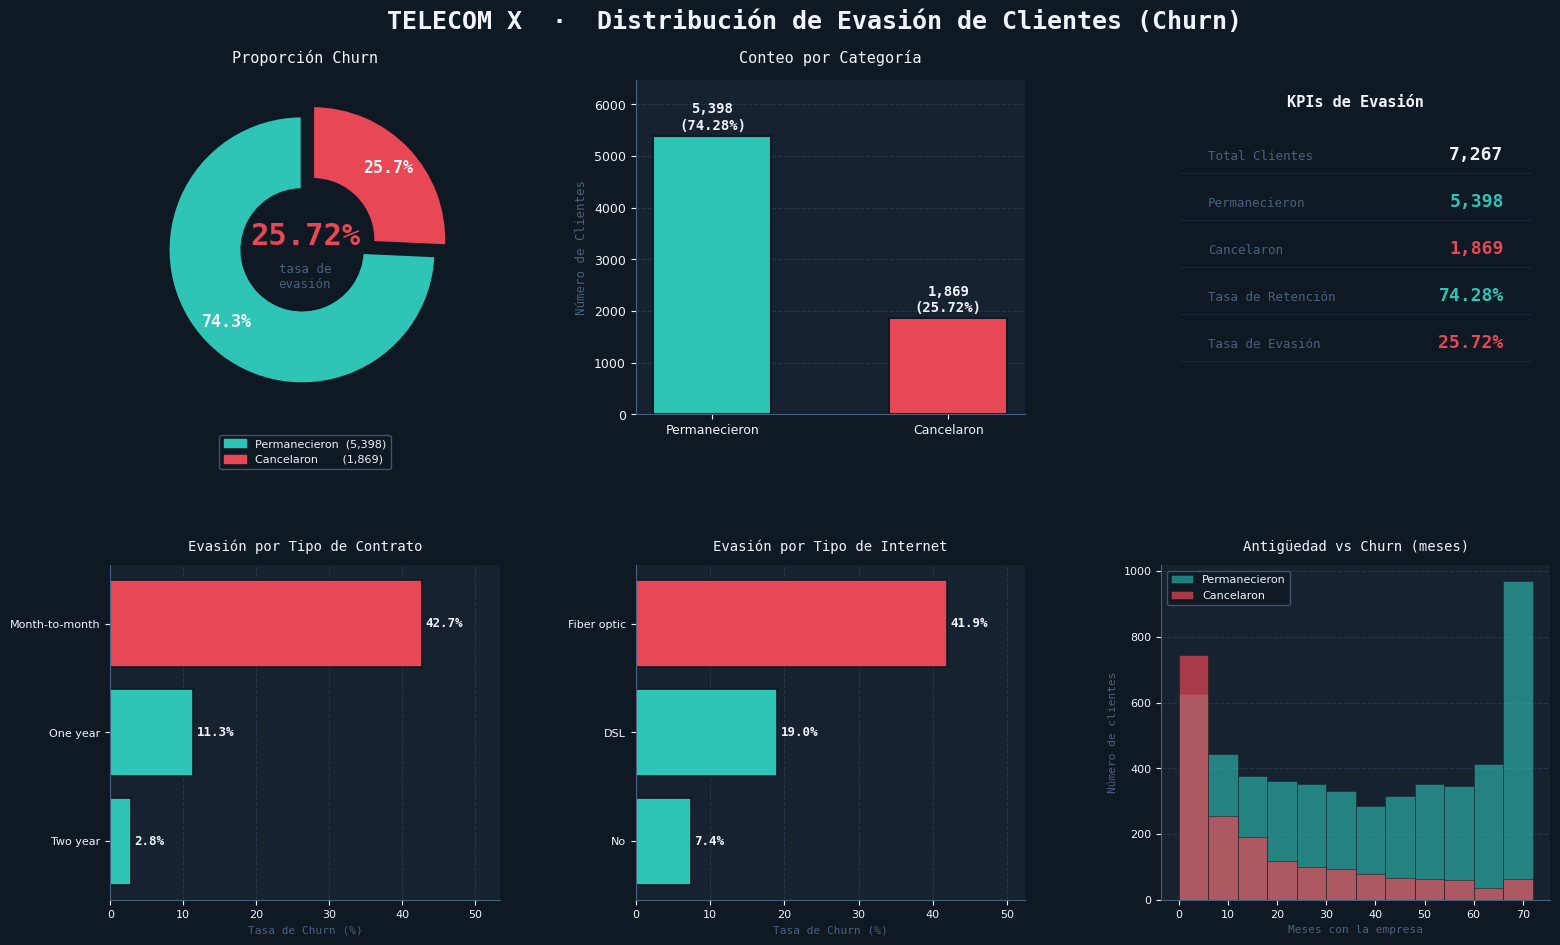


✅ Gráfico guardado como 'telecomx_churn_distribucion.png'


In [8]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 7: Visualización de la distribución de Churn
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns

# ── Cargar y preparar datos ───────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":               "id_cliente",
    "customer.gender":          "genero",
    "customer.SeniorCitizen":   "adulto_mayor",
    "customer.Partner":         "tiene_pareja",
    "customer.Dependents":      "tiene_dependientes",
    "customer.tenure":          "meses_contrato",
    "phone.PhoneService":       "servicio_telefono",
    "phone.MultipleLines":      "multiples_lineas",
    "internet.InternetService": "tipo_internet",
    "internet.OnlineSecurity":  "seguridad_online",
    "internet.OnlineBackup":    "respaldo_online",
    "internet.DeviceProtection":"proteccion_dispositivo",
    "internet.TechSupport":     "soporte_tecnico",
    "internet.StreamingTV":     "streaming_tv",
    "internet.StreamingMovies": "streaming_peliculas",
    "account.Contract":         "tipo_contrato",
    "account.PaperlessBilling": "factura_digital",
    "account.PaymentMethod":    "metodo_pago",
    "account.Charges.Monthly":  "cargo_mensual",
    "account.Charges.Total":    "cargo_total",
    "Churn":                    "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]     = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]   = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["cargo_total"]     = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]           = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

# ── Métricas base ─────────────────────────────────────────────
total      = len(df_clean)
cancelaron = int(df_clean["churn"].sum())
no_cancel  = total - cancelaron
tasa_churn = round(cancelaron / total * 100, 2)
tasa_ret   = round(no_cancel  / total * 100, 2)

# ── Paleta de colores ─────────────────────────────────────────
COLOR_STAY   = "#2EC4B6"   # teal  → se quedaron
COLOR_CHURN  = "#E84855"   # rojo  → cancelaron
COLOR_BG     = "#0F1923"   # fondo oscuro
COLOR_PANEL  = "#162230"   # panel
COLOR_TEXT   = "#F0F4F8"   # texto claro
COLOR_SUBTLE = "#4A6080"   # texto secundario

# ================================================================
# FIGURA PRINCIPAL
# ================================================================
fig = plt.figure(figsize=(16, 10), facecolor=COLOR_BG)
fig.suptitle(
    "TELECOM X  ·  Distribución de Evasión de Clientes (Churn)",
    fontsize=18, fontweight="bold", color=COLOR_TEXT,
    fontfamily="monospace", y=0.97
)

gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35,
              left=0.06, right=0.96, top=0.90, bottom=0.08)

# ── Subgráfico 1: Gráfico de Dona ────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(COLOR_PANEL)

sizes  = [no_cancel, cancelaron]
colors = [COLOR_STAY, COLOR_CHURN]
explode = (0.03, 0.08)

wedges, texts, autotexts = ax1.pie(
    sizes,
    explode=explode,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=COLOR_BG, linewidth=2),
    textprops=dict(color=COLOR_TEXT, fontsize=11, fontfamily="monospace"),
    pctdistance=0.78
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight("bold")

# Texto central
ax1.text(0, 0.08, f"{tasa_churn}%", ha="center", va="center",
         fontsize=22, fontweight="bold", color=COLOR_CHURN,
         fontfamily="monospace")
ax1.text(0, -0.22, "tasa de\nevasión", ha="center", va="center",
         fontsize=9, color=COLOR_SUBTLE, fontfamily="monospace")

ax1.set_title("Proporción Churn", color=COLOR_TEXT,
              fontsize=11, fontfamily="monospace", pad=12)
legend_elements = [
    mpatches.Patch(color=COLOR_STAY,  label=f"Permanecieron  ({no_cancel:,})"),
    mpatches.Patch(color=COLOR_CHURN, label=f"Cancelaron       ({cancelaron:,})"),
]
ax1.legend(handles=legend_elements, loc="lower center",
           bbox_to_anchor=(0.5, -0.18), fontsize=8,
           facecolor=COLOR_BG, edgecolor=COLOR_SUBTLE,
           labelcolor=COLOR_TEXT, framealpha=0.8)

# ── Subgráfico 2: Barras verticales con conteo ───────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(COLOR_PANEL)

categorias  = ["Permanecieron", "Cancelaron"]
valores     = [no_cancel, cancelaron]
bar_colors  = [COLOR_STAY, COLOR_CHURN]

bars = ax2.bar(categorias, valores, color=bar_colors,
               width=0.5, edgecolor=COLOR_BG, linewidth=1.5)

# Etiquetas encima de cada barra
for bar, val, pct in zip(bars, valores, [tasa_ret, tasa_churn]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
             f"{val:,}\n({pct}%)",
             ha="center", va="bottom", fontsize=10,
             color=COLOR_TEXT, fontfamily="monospace", fontweight="bold")

ax2.set_title("Conteo por Categoría", color=COLOR_TEXT,
              fontsize=11, fontfamily="monospace", pad=12)
ax2.set_ylabel("Número de Clientes", color=COLOR_SUBTLE,
               fontsize=9, fontfamily="monospace")
ax2.set_ylim(0, max(valores) * 1.2)
ax2.tick_params(colors=COLOR_TEXT, labelsize=9)
ax2.spines[["top","right","left","bottom"]].set_color(COLOR_SUBTLE)
ax2.spines[["top","right"]].set_visible(False)
ax2.yaxis.grid(True, color=COLOR_SUBTLE, alpha=0.3, linestyle="--")
ax2.set_axisbelow(True)

# ── Subgráfico 3: KPIs textuales ─────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(COLOR_PANEL)
ax3.axis("off")

ax3.text(0.5, 0.92, "KPIs de Evasión", ha="center",
         fontsize=11, fontweight="bold", color=COLOR_TEXT,
         fontfamily="monospace", transform=ax3.transAxes)

kpis = [
    ("Total Clientes",       f"{total:,}",          COLOR_TEXT),
    ("Permanecieron",        f"{no_cancel:,}",       COLOR_STAY),
    ("Cancelaron",           f"{cancelaron:,}",      COLOR_CHURN),
    ("Tasa de Retención",    f"{tasa_ret}%",         COLOR_STAY),
    ("Tasa de Evasión",      f"{tasa_churn}%",       COLOR_CHURN),
]
y_pos = 0.76
for label, valor, color in kpis:
    ax3.text(0.12, y_pos, label, ha="left", fontsize=9,
             color=COLOR_SUBTLE, fontfamily="monospace",
             transform=ax3.transAxes)
    ax3.text(0.88, y_pos, valor, ha="right", fontsize=13,
             fontweight="bold", color=color, fontfamily="monospace",
             transform=ax3.transAxes)
    ax3.plot([0.05, 0.95], [y_pos - 0.04, y_pos - 0.04],
             color=COLOR_SUBTLE, alpha=0.2, linewidth=0.8,
             transform=ax3.transAxes, clip_on=False)
    y_pos -= 0.14

# ── Subgráfico 4: Churn por tipo de contrato ─────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor(COLOR_PANEL)

if "tipo_contrato" in df_clean.columns:
    contrato_churn = df_clean.groupby("tipo_contrato")["churn"].mean().mul(100).round(1).sort_values()
    colores_bar = [COLOR_STAY if v < 20 else COLOR_CHURN if v > 40 else "#F5A623"
                   for v in contrato_churn.values]
    bars4 = ax4.barh(contrato_churn.index, contrato_churn.values,
                     color=colores_bar, edgecolor=COLOR_BG, linewidth=1.2)
    for bar, val in zip(bars4, contrato_churn.values):
        ax4.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=9,
                 color=COLOR_TEXT, fontfamily="monospace", fontweight="bold")
    ax4.set_title("Evasión por Tipo de Contrato", color=COLOR_TEXT,
                  fontsize=10, fontfamily="monospace", pad=10)
    ax4.set_xlabel("Tasa de Churn (%)", color=COLOR_SUBTLE,
                   fontsize=8, fontfamily="monospace")
    ax4.set_xlim(0, contrato_churn.max() * 1.25)
    ax4.tick_params(colors=COLOR_TEXT, labelsize=8)
    ax4.spines[["top","right","left","bottom"]].set_color(COLOR_SUBTLE)
    ax4.spines[["top","right"]].set_visible(False)
    ax4.xaxis.grid(True, color=COLOR_SUBTLE, alpha=0.3, linestyle="--")
    ax4.set_axisbelow(True)

# ── Subgráfico 5: Churn por tipo de internet ─────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor(COLOR_PANEL)

if "tipo_internet" in df_clean.columns:
    internet_churn = df_clean.groupby("tipo_internet")["churn"].mean().mul(100).round(1).sort_values()
    colores_int = [COLOR_STAY if v < 20 else COLOR_CHURN if v > 40 else "#F5A623"
                   for v in internet_churn.values]
    bars5 = ax5.barh(internet_churn.index, internet_churn.values,
                     color=colores_int, edgecolor=COLOR_BG, linewidth=1.2)
    for bar, val in zip(bars5, internet_churn.values):
        ax5.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f"{val}%", va="center", fontsize=9,
                 color=COLOR_TEXT, fontfamily="monospace", fontweight="bold")
    ax5.set_title("Evasión por Tipo de Internet", color=COLOR_TEXT,
                  fontsize=10, fontfamily="monospace", pad=10)
    ax5.set_xlabel("Tasa de Churn (%)", color=COLOR_SUBTLE,
                   fontsize=8, fontfamily="monospace")
    ax5.set_xlim(0, internet_churn.max() * 1.25)
    ax5.tick_params(colors=COLOR_TEXT, labelsize=8)
    ax5.spines[["top","right","left","bottom"]].set_color(COLOR_SUBTLE)
    ax5.spines[["top","right"]].set_visible(False)
    ax5.xaxis.grid(True, color=COLOR_SUBTLE, alpha=0.3, linestyle="--")
    ax5.set_axisbelow(True)

# ── Subgráfico 6: Churn por antigüedad (histograma) ──────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor(COLOR_PANEL)

if "meses_contrato" in df_clean.columns:
    churn_si  = df_clean[df_clean["churn"]==1]["meses_contrato"]
    churn_no  = df_clean[df_clean["churn"]==0]["meses_contrato"]
    bins = range(0, int(df_clean["meses_contrato"].max()) + 5, 6)

    ax6.hist(churn_no, bins=bins, alpha=0.6, color=COLOR_STAY,
             label="Permanecieron", edgecolor=COLOR_BG, linewidth=0.5)
    ax6.hist(churn_si, bins=bins, alpha=0.7, color=COLOR_CHURN,
             label="Cancelaron", edgecolor=COLOR_BG, linewidth=0.5)

    ax6.set_title("Antigüedad vs Churn (meses)", color=COLOR_TEXT,
                  fontsize=10, fontfamily="monospace", pad=10)
    ax6.set_xlabel("Meses con la empresa", color=COLOR_SUBTLE,
                   fontsize=8, fontfamily="monospace")
    ax6.set_ylabel("Número de clientes", color=COLOR_SUBTLE,
                   fontsize=8, fontfamily="monospace")
    ax6.tick_params(colors=COLOR_TEXT, labelsize=8)
    ax6.spines[["top","right","left","bottom"]].set_color(COLOR_SUBTLE)
    ax6.spines[["top","right"]].set_visible(False)
    ax6.yaxis.grid(True, color=COLOR_SUBTLE, alpha=0.3, linestyle="--")
    ax6.set_axisbelow(True)
    ax6.legend(fontsize=8, facecolor=COLOR_BG, edgecolor=COLOR_SUBTLE,
               labelcolor=COLOR_TEXT, framealpha=0.8)

plt.savefig("telecomx_churn_distribucion.png", dpi=150,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()
print("\n✅ Gráfico guardado como 'telecomx_churn_distribucion.png'")

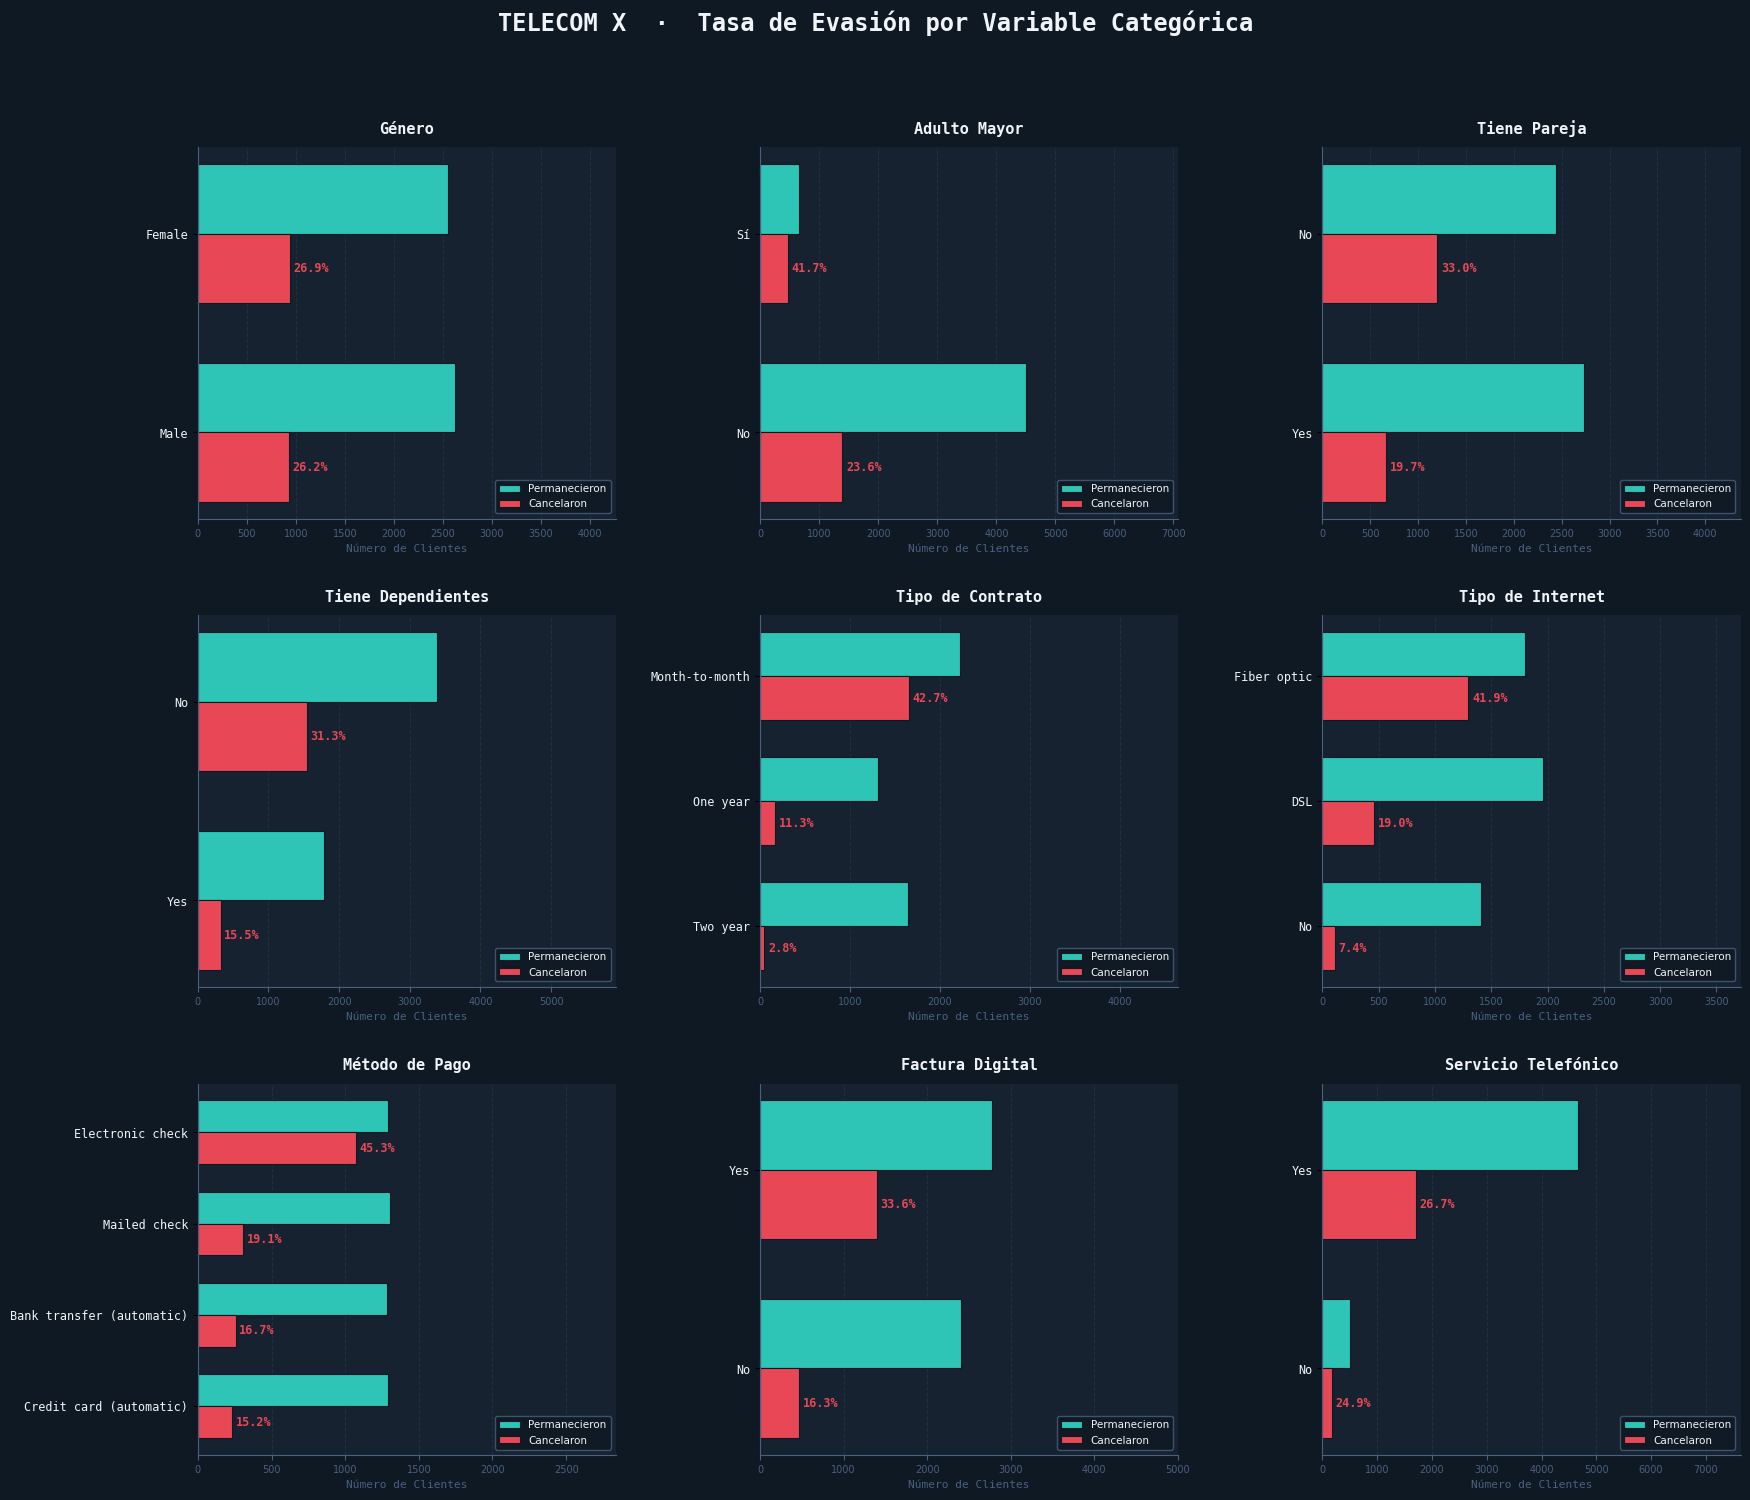

📊 RESUMEN: TASA DE CHURN POR VARIABLE CATEGÓRICA

📌 Género:
        Cancelaron  Total  tasa_%
genero                           
Female       939.0   3488    26.9
Male         930.0   3555    26.2

📌 Adulto Mayor:
              Cancelaron  Total  tasa_%
adulto_mayor                           
Sí                 476.0   1142    41.7
No                1393.0   5901    23.6

📌 Tiene Pareja:
              Cancelaron  Total  tasa_%
tiene_pareja                           
No                1200.0   3641    33.0
Yes                669.0   3402    19.7

📌 Tiene Dependientes:
                    Cancelaron  Total  tasa_%
tiene_dependientes                           
No                      1543.0   4933    31.3
Yes                      326.0   2110    15.5

📌 Tipo de Contrato:
                Cancelaron  Total  tasa_%
tipo_contrato                            
Month-to-month      1655.0   3875    42.7
One year             166.0   1473    11.3
Two year              48.0   1695     2.8

📌 Tipo de I

In [9]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 8: Churn por Variables Categóricas
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── Cargar y preparar datos ───────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]   = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"] = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["cargo_total"]   = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]         = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["adulto_mayor"]  = df_clean["adulto_mayor"].astype(str).map({"1": "Sí", "0": "No"})
df_clean.drop_duplicates(inplace=True)

# ── Paleta ────────────────────────────────────────────────────
COLOR_STAY  = "#2EC4B6"
COLOR_CHURN = "#E84855"
COLOR_BG    = "#0F1923"
COLOR_PANEL = "#162230"
COLOR_TEXT  = "#F0F4F8"
COLOR_SUB   = "#4A6080"

# ── Variables a analizar ──────────────────────────────────────
variables = [
    ("genero",               "Género"),
    ("adulto_mayor",         "Adulto Mayor"),
    ("tiene_pareja",         "Tiene Pareja"),
    ("tiene_dependientes",   "Tiene Dependientes"),
    ("tipo_contrato",        "Tipo de Contrato"),
    ("tipo_internet",        "Tipo de Internet"),
    ("metodo_pago",          "Método de Pago"),
    ("factura_digital",      "Factura Digital"),
    ("servicio_telefono",    "Servicio Telefónico"),
]
variables = [(col, label) for col, label in variables if col in df_clean.columns]

# ================================================================
# FIGURA: grilla de subgráficos por variable categórica
# ================================================================
ncols = 3
nrows = -(-len(variables) // ncols)   # ceil division

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(18, nrows * 5),
                         facecolor=COLOR_BG)
fig.suptitle(
    "TELECOM X  ·  Tasa de Evasión por Variable Categórica",
    fontsize=17, fontweight="bold", color=COLOR_TEXT,
    fontfamily="monospace", y=1.01
)
axes_flat = axes.flatten()

for idx, (col, titulo) in enumerate(variables):
    ax = axes_flat[idx]
    ax.set_facecolor(COLOR_PANEL)

    # Calcular conteos y tasa de churn por categoría
    grupo = df_clean.groupby(col)["churn"].agg(["sum", "count"]).reset_index()
    grupo.columns = [col, "cancelaron", "total"]
    grupo["tasa_churn"] = (grupo["cancelaron"] / grupo["total"] * 100).round(1)
    grupo["se_quedaron"] = grupo["total"] - grupo["cancelaron"]
    grupo = grupo.sort_values("tasa_churn", ascending=True)

    categorias = grupo[col].astype(str).tolist()
    y = np.arange(len(categorias))
    height = 0.35

    # Barras apiladas: se quedaron + cancelaron
    bars_stay  = ax.barh(y + height/2, grupo["se_quedaron"], height=height,
                         color=COLOR_STAY,  label="Permanecieron",
                         edgecolor=COLOR_BG, linewidth=0.8)
    bars_churn = ax.barh(y - height/2, grupo["cancelaron"],  height=height,
                         color=COLOR_CHURN, label="Cancelaron",
                         edgecolor=COLOR_BG, linewidth=0.8)

    # Etiqueta de tasa de churn al final de cada barra de cancelados
    for i, (bar, tasa) in enumerate(zip(bars_churn, grupo["tasa_churn"])):
        ax.text(bar.get_width() + grupo["total"].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{tasa}%", va="center", ha="left",
                fontsize=8.5, fontweight="bold",
                color=COLOR_CHURN, fontfamily="monospace")

    ax.set_yticks(y)
    ax.set_yticklabels(categorias, fontsize=8.5,
                       color=COLOR_TEXT, fontfamily="monospace")
    ax.set_title(titulo, color=COLOR_TEXT, fontsize=11,
                 fontfamily="monospace", pad=10, fontweight="bold")
    ax.set_xlabel("Número de Clientes", color=COLOR_SUB,
                  fontsize=8, fontfamily="monospace")
    ax.tick_params(axis="x", colors=COLOR_SUB, labelsize=7)
    ax.spines[["top", "right", "left", "bottom"]].set_color(COLOR_SUB)
    ax.spines[["top", "right"]].set_visible(False)
    ax.xaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
    ax.set_axisbelow(True)
    ax.set_xlim(0, grupo["total"].max() * 1.2)

    legend = ax.legend(fontsize=7.5, facecolor=COLOR_BG,
                       edgecolor=COLOR_SUB, labelcolor=COLOR_TEXT,
                       framealpha=0.8, loc="lower right")

# Ocultar ejes sobrantes
for idx in range(len(variables), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig("telecomx_churn_categoricas.png", dpi=150,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# RESUMEN NUMÉRICO EN CONSOLA
# ================================================================
print("="*60)
print("📊 RESUMEN: TASA DE CHURN POR VARIABLE CATEGÓRICA")
print("="*60)

for col, titulo in variables:
    grupo = df_clean.groupby(col)["churn"].agg(["sum","count"])
    grupo["tasa_%"] = (grupo["sum"] / grupo["count"] * 100).round(1)
    grupo = grupo.rename(columns={"sum": "Cancelaron", "count": "Total"})
    print(f"\n📌 {titulo}:")
    print(grupo[["Cancelaron", "Total", "tasa_%"]].sort_values("tasa_%", ascending=False).to_string())

print("\n✅ Análisis por variables categóricas completado.")

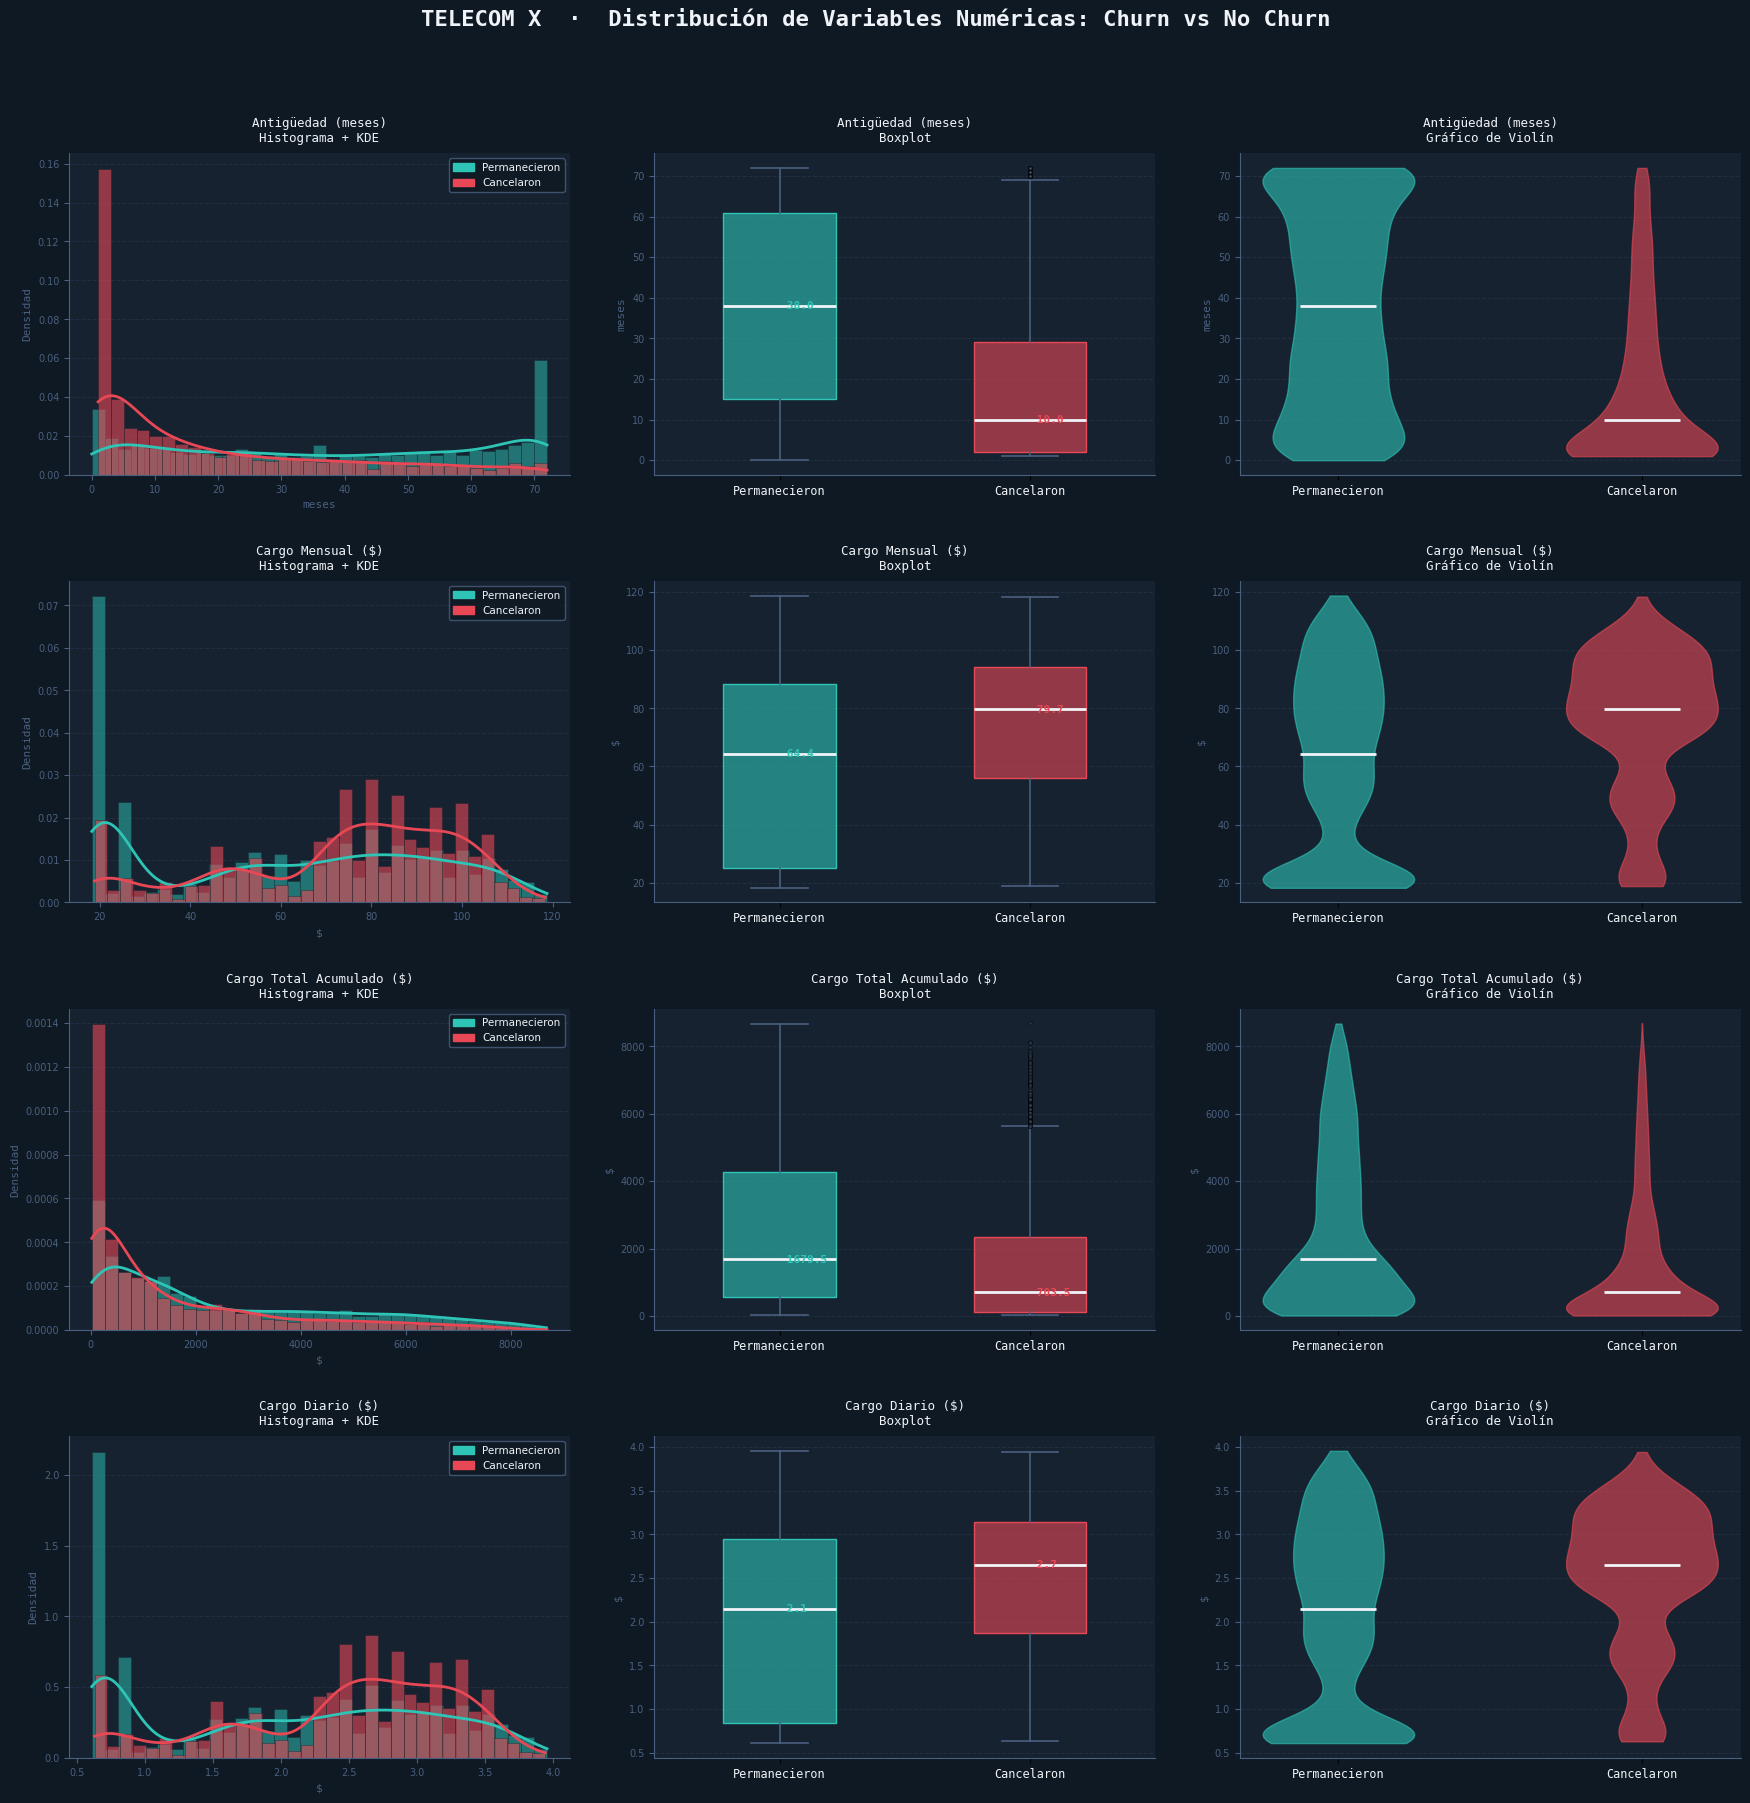

📊 RESUMEN ESTADÍSTICO: VARIABLES NUMÉRICAS POR CHURN

📌 Antigüedad (meses):
  Métrica               Permanecieron     Cancelaron
  --------------------------------------------------
  Media                       37.57          17.98
  Mediana                     38.00          10.00
  Desv. Estándar              24.11          19.53
  Mínimo                       0.00           1.00
  Máximo                      72.00          72.00
  Mann-Whitney U: p = 0.0000  →  ✅ Diferencia significativa (p < 0.05)

📌 Cargo Mensual ($):
  Métrica               Permanecieron     Cancelaron
  --------------------------------------------------
  Media                       61.27          74.44
  Mediana                     64.43          79.65
  Desv. Estándar              31.09          24.67
  Mínimo                      18.25          18.85
  Máximo                     118.75         118.35
  Mann-Whitney U: p = 0.0000  →  ✅ Diferencia significativa (p < 0.05)

📌 Cargo Total Acumulado ($):
  Métric

In [10]:
# ============================================================
# TELECOM X - Análisis de Evasión de Clientes
# Paso 9: Distribución de Variables Numéricas por Churn
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy import stats

# ── Cargar y preparar datos ───────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]      = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]    = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["meses_contrato"]   = pd.to_numeric(df_clean["meses_contrato"], errors="coerce")
df_clean["cargo_total"]      = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]            = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"]  = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

# Separar grupos
churn_si = df_clean[df_clean["churn"] == 1]
churn_no = df_clean[df_clean["churn"] == 0]

# ── Paleta ────────────────────────────────────────────────────
COLOR_STAY  = "#2EC4B6"
COLOR_CHURN = "#E84855"
COLOR_BG    = "#0F1923"
COLOR_PANEL = "#162230"
COLOR_TEXT  = "#F0F4F8"
COLOR_SUB   = "#4A6080"

# ── Variables numéricas a analizar ────────────────────────────
variables = [
    ("meses_contrato",  "Antigüedad (meses)",       "meses"),
    ("cargo_mensual",   "Cargo Mensual ($)",         "$"),
    ("cargo_total",     "Cargo Total Acumulado ($)", "$"),
    ("Cuentas_Diarias", "Cargo Diario ($)",          "$"),
]
variables = [(col, label, unit) for col, label, unit in variables
             if col in df_clean.columns]

# ================================================================
# FIGURA: 3 tipos de gráfico por cada variable numérica
# Columnas: Histograma+KDE | Boxplot | Violín
# ================================================================
nrows = len(variables)
ncols = 3

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(18, nrows * 4.5),
                         facecolor=COLOR_BG)
fig.suptitle(
    "TELECOM X  ·  Distribución de Variables Numéricas: Churn vs No Churn",
    fontsize=16, fontweight="bold", color=COLOR_TEXT,
    fontfamily="monospace", y=1.01
)

legend_patch = [
    mpatches.Patch(color=COLOR_STAY,  label="Permanecieron"),
    mpatches.Patch(color=COLOR_CHURN, label="Cancelaron"),
]

for row, (col, label, unit) in enumerate(variables):
    data_no = churn_no[col].dropna()
    data_si = churn_si[col].dropna()

    # ── Col 0: Histograma + KDE ───────────────────────────────
    ax0 = axes[row, 0]
    ax0.set_facecolor(COLOR_PANEL)

    bins = 35
    ax0.hist(data_no, bins=bins, color=COLOR_STAY,  alpha=0.5,
             density=True, label="Permanecieron", edgecolor=COLOR_BG, linewidth=0.4)
    ax0.hist(data_si, bins=bins, color=COLOR_CHURN, alpha=0.6,
             density=True, label="Cancelaron",    edgecolor=COLOR_BG, linewidth=0.4)

    # KDE suavizado
    for data_grp, color in [(data_no, COLOR_STAY), (data_si, COLOR_CHURN)]:
        if len(data_grp) > 1:
            kde = stats.gaussian_kde(data_grp)
            x_range = np.linspace(data_grp.min(), data_grp.max(), 300)
            ax0.plot(x_range, kde(x_range), color=color, linewidth=2)

    ax0.set_title(f"{label}\nHistograma + KDE", color=COLOR_TEXT,
                  fontsize=9, fontfamily="monospace", pad=8)
    ax0.set_xlabel(unit, color=COLOR_SUB, fontsize=8, fontfamily="monospace")
    ax0.set_ylabel("Densidad",  color=COLOR_SUB, fontsize=8, fontfamily="monospace")
    ax0.tick_params(colors=COLOR_SUB, labelsize=7)
    ax0.spines[["top","right"]].set_visible(False)
    ax0.spines[["left","bottom"]].set_color(COLOR_SUB)
    ax0.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
    ax0.set_axisbelow(True)
    ax0.legend(handles=legend_patch, fontsize=7.5,
               facecolor=COLOR_BG, edgecolor=COLOR_SUB,
               labelcolor=COLOR_TEXT, framealpha=0.8)

    # ── Col 1: Boxplot ────────────────────────────────────────
    ax1 = axes[row, 1]
    ax1.set_facecolor(COLOR_PANEL)

    bp = ax1.boxplot(
        [data_no, data_si],
        patch_artist=True,
        widths=0.45,
        medianprops=dict(color=COLOR_TEXT, linewidth=2),
        whiskerprops=dict(color=COLOR_SUB, linewidth=1.2),
        capprops=dict(color=COLOR_SUB, linewidth=1.2),
        flierprops=dict(marker="o", markersize=2.5,
                        markerfacecolor=COLOR_SUB, alpha=0.4,
                        linestyle="none"),
    )
    bp["boxes"][0].set_facecolor(COLOR_STAY  + "99")  # alpha hex
    bp["boxes"][1].set_facecolor(COLOR_CHURN + "99")
    bp["boxes"][0].set_edgecolor(COLOR_STAY)
    bp["boxes"][1].set_edgecolor(COLOR_CHURN)

    # Anotaciones de mediana
    for i, (data_grp, color) in enumerate([(data_no, COLOR_STAY), (data_si, COLOR_CHURN)], 1):
        med = data_grp.median()
        ax1.text(i, med, f" {med:.1f}", va="center", ha="left",
                 fontsize=8, color=color, fontfamily="monospace",
                 fontweight="bold")

    ax1.set_xticklabels(["Permanecieron", "Cancelaron"],
                        color=COLOR_TEXT, fontsize=8.5, fontfamily="monospace")
    ax1.set_title(f"{label}\nBoxplot", color=COLOR_TEXT,
                  fontsize=9, fontfamily="monospace", pad=8)
    ax1.set_ylabel(unit, color=COLOR_SUB, fontsize=8, fontfamily="monospace")
    ax1.tick_params(axis="y", colors=COLOR_SUB, labelsize=7)
    ax1.spines[["top","right"]].set_visible(False)
    ax1.spines[["left","bottom"]].set_color(COLOR_SUB)
    ax1.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
    ax1.set_axisbelow(True)

    # ── Col 2: Gráfico de violín ──────────────────────────────
    ax2 = axes[row, 2]
    ax2.set_facecolor(COLOR_PANEL)

    parts = ax2.violinplot(
        [data_no, data_si],
        positions=[1, 2],
        showmedians=True,
        showextrema=False,
    )
    colors_violin = [COLOR_STAY, COLOR_CHURN]
    for pc, color in zip(parts["bodies"], colors_violin):
        pc.set_facecolor(color)
        pc.set_edgecolor(color)
        pc.set_alpha(0.6)
    parts["cmedians"].set_color(COLOR_TEXT)
    parts["cmedians"].set_linewidth(2)

    ax2.set_xticks([1, 2])
    ax2.set_xticklabels(["Permanecieron", "Cancelaron"],
                        color=COLOR_TEXT, fontsize=8.5, fontfamily="monospace")
    ax2.set_title(f"{label}\nGráfico de Violín", color=COLOR_TEXT,
                  fontsize=9, fontfamily="monospace", pad=8)
    ax2.set_ylabel(unit, color=COLOR_SUB, fontsize=8, fontfamily="monospace")
    ax2.tick_params(axis="y", colors=COLOR_SUB, labelsize=7)
    ax2.spines[["top","right"]].set_visible(False)
    ax2.spines[["left","bottom"]].set_color(COLOR_SUB)
    ax2.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
    ax2.set_axisbelow(True)

plt.tight_layout(pad=2.5)
plt.savefig("telecomx_churn_numericas.png", dpi=150,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# RESUMEN ESTADÍSTICO EN CONSOLA
# ================================================================
print("="*65)
print("📊 RESUMEN ESTADÍSTICO: VARIABLES NUMÉRICAS POR CHURN")
print("="*65)

for col, label, unit in variables:
    d_no = churn_no[col].dropna()
    d_si = churn_si[col].dropna()
    print(f"\n📌 {label}:")
    print(f"  {'Métrica':<18} {'Permanecieron':>16} {'Cancelaron':>14}")
    print(f"  {'-'*50}")
    print(f"  {'Media':<18} {d_no.mean():>14.2f}   {d_si.mean():>12.2f}")
    print(f"  {'Mediana':<18} {d_no.median():>14.2f}   {d_si.median():>12.2f}")
    print(f"  {'Desv. Estándar':<18} {d_no.std():>14.2f}   {d_si.std():>12.2f}")
    print(f"  {'Mínimo':<18} {d_no.min():>14.2f}   {d_si.min():>12.2f}")
    print(f"  {'Máximo':<18} {d_no.max():>14.2f}   {d_si.max():>12.2f}")

    # Test de Mann-Whitney para significancia estadística
    stat, p = stats.mannwhitneyu(d_no, d_si, alternative="two-sided")
    sig = "✅ Diferencia significativa (p < 0.05)" if p < 0.05 else "⚠️  Sin diferencia significativa"
    print(f"  Mann-Whitney U: p = {p:.4f}  →  {sig}")

print("\n✅ Análisis de variables numéricas completado.")

# 📄 Informe Final: Análisis de Evasión de Clientes (Churn) en Telecom X

## 🔹 Introducción

El presente informe detalla el análisis de evasión de clientes (Churn) para la empresa **Telecom X**. El objetivo principal es identificar los factores clave que influyen en la decisión de los clientes de cancelar sus servicios, con el fin de desarrollar estrategias efectivas de retención. La evasión de clientes es un problema crítico para las empresas de telecomunicaciones, ya que la adquisición de nuevos clientes es significativamente más costosa que la retención de los existentes. Comprender y predecir el churn permite a Telecom X actuar proactivamente para mantener su base de clientes y asegurar la sostenibilidad del negocio.

### 🔹 Limpieza y Tratamiento de Datos

El proceso de preparación de datos incluyó los siguientes pasos:

1.  **Carga de Datos**: Los datos se cargaron directamente desde un archivo JSON a través de una URL, y se transformaron en un DataFrame de Pandas para su manipulación.

2.  **Exploración Inicial**: Se realizó una revisión de dimensiones, tipos de datos y los primeros registros para obtener una visión general del dataset.

3.  **Renombrado de Columnas**: Las columnas con nombres jerárquicos (ej. `customer.gender`) se renombraron a un formato más simple y legible (ej. `genero`) para facilitar el análisis.

4.  **Manejo de Valores Ausentes y Errores**: Se identificaron y trataron valores nulos, específicamente en la columna `account.Charges.Total` (renombrada a `cargo_total`), que contenía strings vacíos. Estos se convirtieron a numéricos y los valores resultantes nulos se imputaron con la mediana. También se identificaron 224 valores nulos en la columna `churn`.

5.  **Conversión de Tipos de Datos**: Las columnas como `cargo_total`, `cargo_mensual` y `meses_contrato` se aseguraron como numéricas. La variable objetivo `churn` se convirtió de `Yes`/`No` a `1`/`0` para el análisis cuantitativo.

6.  **Estandarización de Strings**: Se eliminaron espacios en blanco al inicio y final de todas las columnas de texto para evitar inconsistencias.

7.  **Creación de Nuevas Características**: Se creó la columna `Cuentas_Diarias` (cargo mensual / 30) para un análisis más granular del costo diario por cliente.

El dataset final, `df_clean`, quedó con 7267 filas y 22 columnas, listo para el análisis exploratorio. Se identificaron 224 valores nulos restantes en la columna `churn`.

## 🔹 Análisis Exploratorio de Datos (EDA)

El EDA se centró en entender la distribución de las variables y su relación con la tasa de evasión (churn). Los principales hallazgos se resumen a continuación:

### 📊 Tasa General de Churn

Se identificó una **tasa de evasión del 25.72%**, lo que significa que aproximadamente uno de cada cuatro clientes de Telecom X cancela sus servicios. Esto representa una base significativa de clientes perdidos que requiere atención. (Ver gráfico en `telecomx_churn_distribucion.png`).

### 📈 Variables Numéricas

Se analizaron `meses_contrato`, `cargo_mensual`, `cargo_total` y `Cuentas_Diarias` en relación con el churn. Los resultados muestran:

*   **Antigüedad (`meses_contrato`)**: Los clientes que cancelan tienen una antigüedad promedio significativamente menor (17.98 meses) en comparación con los que permanecen (37.57 meses). Esto sugiere que los clientes con menor antigüedad son más propensos a la evasión. (Ver `telecomx_churn_numericas.png`).
*   **Cargo Mensual (`cargo_mensual`) y Cargo Diario (`Cuentas_Diarias`)**: Los clientes que cancelan tienen un cargo mensual y diario promedio más alto ($74.44 y $2.48, respectivamente) que los que no cancelan ($61.27 y $2.04). Esto indica que un mayor gasto mensual podría ser un factor de insatisfacción o percepción de poco valor por el precio. (Ver `telecomx_churn_numericas.png`).
*   **Cargo Total (`cargo_total`)**: Los clientes que cancelan tienen un cargo total acumulado menor, lo cual es coherente con su menor antigüedad. (Ver `telecomx_churn_numericas.png`).

###  Variables Categóricas

El análisis de variables categóricas reveló patrones importantes en la tasa de churn:

*   **Tipo de Contrato**: Los clientes con contratos **mes a mes** presentan una tasa de evasión alarmantemente alta (42.7%), muy superior a los contratos de un año (11.3%) y dos años (2.8%). Esto subraya la importancia de los contratos a largo plazo para la retención. (Ver `telecomx_churn_categoricas.png`).
*   **Tipo de Internet**: Los clientes con servicio de **fibra óptica** tienen una tasa de churn considerablemente más alta (41.9%) que aquellos con DSL (19.0%) o sin servicio de internet (7.4%). Esto podría indicar problemas con la calidad o el costo del servicio de fibra óptica.
*   **Método de Pago**: El **cheque electrónico** está asociado con la tasa de churn más alta (45.3%), mientras que los métodos de pago automático (transferencia bancaria, tarjeta de crédito) tienen tasas de evasión mucho más bajas (16.7% y 15.2%, respectivamente).
*   **Factura Digital**: Los clientes que reciben **factura digital** tienen una tasa de churn más alta (33.6%) que los que no (16.3%).
*   **Adulto Mayor**: Los **adultos mayores** tienen una tasa de churn casi el doble (41.7%) que los no adultos mayores (23.6%), lo que podría sugerir necesidades no satisfechas en este segmento.
*   **Género, Pareja, Dependientes, Servicio Telefónico**: Estas variables mostraron diferencias menos pronunciadas en las tasas de churn (Ver `telecomx_churn_categoricas.png`).

### 🎯 Correlaciones

Las correlaciones más fuertes con el churn fueron:

*   **Correlación Negativa**: `meses_contrato` (r = -0.352) y `cargo_total` (r = -0.199). Esto confirma que a menor antigüedad y menor cargo total, mayor la probabilidad de churn.
*   **Correlación Positiva**: `cargo_mensual` (r = 0.193) y `Cuentas_Diarias` (r = 0.193). Un mayor cargo mensual/diario se asocia con mayor churn.

## 🔹 Conclusiones e Insights

Los hallazgos del análisis de datos revelan patrones claros sobre la evasión de clientes en Telecom X:

1.  **Antigüedad Crítica**: Los clientes nuevos o con poca antigüedad son el grupo de mayor riesgo. Esto sugiere que el periodo inicial de la relación con el cliente es crucial y se deben fortalecer las estrategias de bienvenida y fidelización temprana.

2.  **Costos y Percepción de Valor**: Clientes con cargos mensuales y diarios más altos son más propensos a cancelar. Esto puede indicar una falta de satisfacción con el valor recibido por el precio pagado, o que la competencia ofrece mejores tarifas para paquetes similares.

3.  **Impacto del Contrato a Largo Plazo**: La duración del contrato es un predictor muy fuerte de la retención. Los clientes con contratos anuales o bianuales son significativamente más leales, mientras que los de mes a mes son altamente volátiles.

4.  **Servicios Específicos Problemáticos**: El servicio de **fibra óptica** y la **facturación digital** muestran tasas de churn elevadas. Esto podría apuntar a problemas de calidad de servicio o soporte para la fibra óptica, y quizás una falta de entendimiento o valor percibido en la factura digital. El **cheque electrónico** como método de pago también está ligado a un churn alto, posiblemente por una menor automatización o fricción en el proceso de pago.

5.  **Segmentos Vulnerables**: Los **adultos mayores** representan un segmento con una tasa de evasión considerablemente más alta. Podrían tener necesidades específicas (ej. soporte técnico más personalizado, interfaces más sencillas) que no están siendo atendidas.

## 🔹 Recomendaciones Estratégicas

Basado en los insights obtenidos, se proponen las siguientes recomendaciones para Telecom X:

1.  **Programas de Retención Temprana**: Implementar programas proactivos de seguimiento y fidelización para clientes nuevos, especialmente durante sus primeros 12-18 meses de contrato. Esto podría incluir llamadas de cortesía, ofertas personalizadas, o mejoras de servicio.

2.  **Optimización de Planes de Fibra Óptica**: Investigar las causas del alto churn en clientes de fibra óptica. Podría ser necesario mejorar la calidad del servicio, la estabilidad de la conexión, el soporte técnico, o ajustar los precios para ser más competitivos.

3.  **Incentivos para Contratos a Largo Plazo**: Ofrecer descuentos atractivos o beneficios adicionales para incentivar a los clientes de mes a mes a migrar a contratos de uno o dos años. Comunicar claramente el valor y los ahorros a largo plazo.

4.  **Promoción de Métodos de Pago Automáticos**: Educar a los clientes sobre los beneficios de los métodos de pago automáticos (transferencia bancaria, tarjeta de crédito) y ofrecer incentivos para que cambien de cheque electrónico a estas opciones. Esto reduce la fricción y puede mejorar la retención.

5.  **Mejora de la Experiencia del Adulto Mayor**: Desarrollar servicios y soporte específicos para el segmento de adultos mayores, como líneas de atención dedicadas, tutoriales simplificados, o asistencia técnica a domicilio. Esto podría abordar sus necesidades únicas y mejorar su satisfacción.

6.  **Revisión del Proceso de Facturación Digital**: Analizar el feedback de clientes sobre la factura digital. Es posible que se necesiten mejoras en la claridad del formato, el acceso a la información o la facilidad de gestión para reducir la evasión asociada.

# Analisis predictivo

In [11]:
# ============================================================
# TELECOM X - Análisis Predictivo
# Paso 1: Eliminar columnas sin valor predictivo
# ============================================================

import requests
import pandas as pd
import numpy as np

# ── Cargar y preparar datos ───────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]     = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]   = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["meses_contrato"]  = pd.to_numeric(df_clean["meses_contrato"], errors="coerce")
df_clean["cargo_total"]     = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]           = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

# ================================================================
print("="*60)
print("🗑️  ELIMINACIÓN DE COLUMNAS SIN VALOR PREDICTIVO")
print("="*60)
print(f"\n📐 Columnas antes: {df_clean.shape[1]}  |  Filas: {df_clean.shape[0]}")
print(f"\n📋 Columnas disponibles:")
for col in df_clean.columns:
    print(f"   - {col}")

# ================================================================
# CRITERIOS DE ELIMINACIÓN
# ================================================================
print("\n" + "="*60)
print("📌 CRITERIOS DE ELIMINACIÓN")
print("="*60)

criterios = {
    "🔑 Identificadores únicos": {
        "columnas": ["id_cliente"],
        "razon": "No tienen poder predictivo. Solo identifican al cliente "
                 "de forma única y generarían sobreajuste (overfitting) si se incluyen."
    },
    "⚠️  Alta colinealidad con otra variable": {
        "columnas": ["cargo_mensual"],
        "razon": "'cargo_mensual' y 'Cuentas_Diarias' miden lo mismo "
                 "(una es derivada exacta de la otra). Mantener ambas introduce "
                 "redundancia. Se conserva 'Cuentas_Diarias' por ser más granular."
    },
}

for criterio, info in criterios.items():
    print(f"\n  {criterio}")
    print(f"  Columnas: {info['columnas']}")
    print(f"  Razón:    {info['razon']}")

# ================================================================
# APLICAR ELIMINACIÓN
# ================================================================
print("\n" + "="*60)
print("✂️  APLICANDO ELIMINACIÓN")
print("="*60)

columnas_a_eliminar = ["id_cliente", "cargo_mensual"]
columnas_existentes = [c for c in columnas_a_eliminar if c in df_clean.columns]

for col in columnas_existentes:
    print(f"  ❌ Eliminando '{col}'...")

df_model = df_clean.drop(columns=columnas_existentes)

# ================================================================
# RESUMEN FINAL
# ================================================================
print("\n" + "="*60)
print("✅ DATASET RESULTANTE")
print("="*60)
print(f"\n  Columnas antes:    {df_clean.shape[1]}")
print(f"  Columnas después:  {df_model.shape[1]}")
print(f"  Columnas eliminadas: {len(columnas_existentes)}")
print(f"\n  📋 Columnas que permanecen para el modelo:")

for i, col in enumerate(df_model.columns, 1):
    dtype = df_model[col].dtype
    es_target = " ← 🎯 TARGET" if col == "churn" else ""
    print(f"   {i:>2}. {col:<28} [{dtype}]{es_target}")

print(f"\n  🔎 Vista previa:")
print(df_model.head(3).to_string())
print("\n✅ Dataset listo para la siguiente etapa: codificación de variables categóricas.")

🗑️  ELIMINACIÓN DE COLUMNAS SIN VALOR PREDICTIVO

📐 Columnas antes: 22  |  Filas: 7267

📋 Columnas disponibles:
   - id_cliente
   - churn
   - genero
   - adulto_mayor
   - tiene_pareja
   - tiene_dependientes
   - meses_contrato
   - servicio_telefono
   - multiples_lineas
   - tipo_internet
   - seguridad_online
   - respaldo_online
   - proteccion_dispositivo
   - soporte_tecnico
   - streaming_tv
   - streaming_peliculas
   - tipo_contrato
   - factura_digital
   - metodo_pago
   - cargo_mensual
   - cargo_total
   - Cuentas_Diarias

📌 CRITERIOS DE ELIMINACIÓN

  🔑 Identificadores únicos
  Columnas: ['id_cliente']
  Razón:    No tienen poder predictivo. Solo identifican al cliente de forma única y generarían sobreajuste (overfitting) si se incluyen.

  ⚠️  Alta colinealidad con otra variable
  Columnas: ['cargo_mensual']
  Razón:    'cargo_mensual' y 'Cuentas_Diarias' miden lo mismo (una es derivada exacta de la otra). Mantener ambas introduce redundancia. Se conserva 'Cuentas_Dia

In [12]:
# ============================================================
# TELECOM X - Análisis Predictivo
# Paso 2: Codificación de Variables Categóricas (One-Hot Encoding)
# ============================================================

import requests
import pandas as pd
import numpy as np

# ── Cargar y preparar datos (pipeline completo) ───────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]     = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]   = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["meses_contrato"]  = pd.to_numeric(df_clean["meses_contrato"], errors="coerce")
df_clean["cargo_total"]     = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]           = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

# Eliminar columnas sin valor predictivo (Paso 1)
df_model = df_clean.drop(columns=["id_cliente", "cargo_mensual"], errors="ignore")

# ================================================================
print("="*60)
print("🔢 PASO 2: CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("="*60)
print(f"\n📐 Dataset entrada: {df_model.shape[0]} filas x {df_model.shape[1]} columnas")

# ================================================================
# 1. IDENTIFICAR TIPOS DE VARIABLES
# ================================================================
print("\n" + "="*60)
print("1️⃣  CLASIFICACIÓN DE VARIABLES")
print("="*60)

cols_numericas    = df_model.select_dtypes(include=["int64","float64"]).columns.tolist()
cols_categoricas  = df_model.select_dtypes(include=["object"]).columns.tolist()

# Separar target del resto
if "churn" in cols_numericas:
    cols_numericas.remove("churn")

print(f"\n  🔢 Variables numéricas ({len(cols_numericas)}):")
for c in cols_numericas:
    print(f"     - {c}")

print(f"\n  🔤 Variables categóricas a codificar ({len(cols_categoricas)}):")
for c in cols_categoricas:
    vals = df_model[c].nunique()
    categorias = sorted(df_model[c].dropna().unique().tolist())
    print(f"     - {c:<30} ({vals} categorías): {categorias}")

print(f"\n  🎯 Variable objetivo: churn (ya es binaria 0/1)")

# ================================================================
# 2. ESTRATEGIA DE CODIFICACIÓN
# ================================================================
print("\n" + "="*60)
print("2️⃣  ESTRATEGIA DE CODIFICACIÓN")
print("="*60)
print("""
  Se aplica ONE-HOT ENCODING con drop_first=True para todas las
  variables categóricas. Esta técnica:

  ✅ Crea una columna binaria (0/1) por cada categoría
  ✅ drop_first=True elimina la primera categoría de cada variable
     para evitar la trampa de multicolinealidad (dummy variable trap)
  ✅ Es compatible con la mayoría de algoritmos de ML
     (Regresión Logística, SVM, Redes Neuronales, etc.)

  ⚠️  Nota: Árboles de decisión y modelos basados en árboles
     (Random Forest, XGBoost) no requieren one-hot encoding,
     pero funciona perfectamente con ellos también.
""")

# ================================================================
# 3. APLICAR ONE-HOT ENCODING
# ================================================================
print("="*60)
print("3️⃣  APLICANDO ONE-HOT ENCODING")
print("="*60)

# Separar target antes de codificar
target    = df_model["churn"].copy()
features  = df_model.drop(columns=["churn"])

# Aplicar get_dummies con drop_first=True
features_encoded = pd.get_dummies(
    features,
    columns=cols_categoricas,
    drop_first=True,
    dtype=int           # columnas resultantes como 0/1 enteros
)

# Reunir features + target
df_encoded = features_encoded.copy()
df_encoded["churn"] = target.values

print(f"\n  Columnas antes del encoding:  {features.shape[1]}")
print(f"  Columnas después del encoding: {features_encoded.shape[1]}")
print(f"  Nuevas columnas generadas:     {features_encoded.shape[1] - len(cols_numericas)}")

# ================================================================
# 4. DETALLE DE COLUMNAS GENERADAS
# ================================================================
print("\n" + "="*60)
print("4️⃣  COLUMNAS GENERADAS POR VARIABLE")
print("="*60)

for col_orig in cols_categoricas:
    nuevas = [c for c in features_encoded.columns if c.startswith(col_orig + "_")]
    print(f"\n  📌 '{col_orig}' → {len(nuevas)} columnas:")
    for c in nuevas:
        print(f"     ✅ {c}")

# ================================================================
# 5. VERIFICACIÓN FINAL
# ================================================================
print("\n" + "="*60)
print("5️⃣  DATASET FINAL CODIFICADO")
print("="*60)

print(f"\n  📐 Dimensiones finales: {df_encoded.shape[0]} filas x {df_encoded.shape[1]} columnas")
print(f"  Valores nulos: {df_encoded.isnull().sum().sum()}")
print(f"  Tipos de datos únicos: {df_encoded.dtypes.unique().tolist()}")

print(f"\n  📋 Todas las columnas del dataset listo para ML:")
for i, col in enumerate(df_encoded.columns, 1):
    es_target = " ← 🎯 TARGET" if col == "churn" else ""
    print(f"   {i:>2}. {col}{es_target}")

print(f"\n  🔎 Vista previa (primeras 3 filas, primeras 10 columnas):")
print(df_encoded.iloc[:3, :10].to_string())

print("\n✅ Codificación completa. Dataset listo para normalización y entrenamiento de modelos.")

🔢 PASO 2: CODIFICACIÓN DE VARIABLES CATEGÓRICAS

📐 Dataset entrada: 7267 filas x 20 columnas

1️⃣  CLASIFICACIÓN DE VARIABLES

  🔢 Variables numéricas (4):
     - adulto_mayor
     - meses_contrato
     - cargo_total
     - Cuentas_Diarias

  🔤 Variables categóricas a codificar (15):
     - genero                         (2 categorías): ['Female', 'Male']
     - tiene_pareja                   (2 categorías): ['No', 'Yes']
     - tiene_dependientes             (2 categorías): ['No', 'Yes']
     - servicio_telefono              (2 categorías): ['No', 'Yes']
     - multiples_lineas               (3 categorías): ['No', 'No phone service', 'Yes']
     - tipo_internet                  (3 categorías): ['DSL', 'Fiber optic', 'No']
     - seguridad_online               (3 categorías): ['No', 'No internet service', 'Yes']
     - respaldo_online                (3 categorías): ['No', 'No internet service', 'Yes']
     - proteccion_dispositivo         (3 categorías): ['No', 'No internet service', '

⚖️  PASO 3: EVALUACIÓN DEL BALANCE DE CLASES

1️⃣  CONTEO Y PROPORCIÓN DE CLASES

                Cantidad  Proporción %
Clase                                 
No canceló (0)      5174         73.46
Canceló (1)         1869         26.54

  Total de clientes:   7,267
  Ratio mayoría/minoría: 2.77:1  (5,174 vs 1,869)

2️⃣  DIAGNÓSTICO DE DESBALANCE

  Clase minoritaria (Churn=1): 26.54%
  Nivel de desbalance:         🟡 MODERADO
  Acción recomendada:          Considerar class_weight='balanced' y evaluar con F1-score y AUC-ROC.

3️⃣  IMPACTO EN MÉTRICAS DE EVALUACIÓN

  Con un desbalance de 2.77:1, un modelo "naive" que prediga
  SIEMPRE la clase 0 (no cancela) obtendría:

    • Accuracy:  73.46%  ← métrica engañosa ⚠️
    • Recall (churn=1):  0%       ← no detecta ningún churn ❌
    • Precision (churn=1): N/A    ← no predice ningún positivo ❌

  Por eso, las métricas correctas para este problema son:

    ✅ F1-Score     → equilibrio entre Precision y Recall
    ✅ AUC-ROC      → capacidad

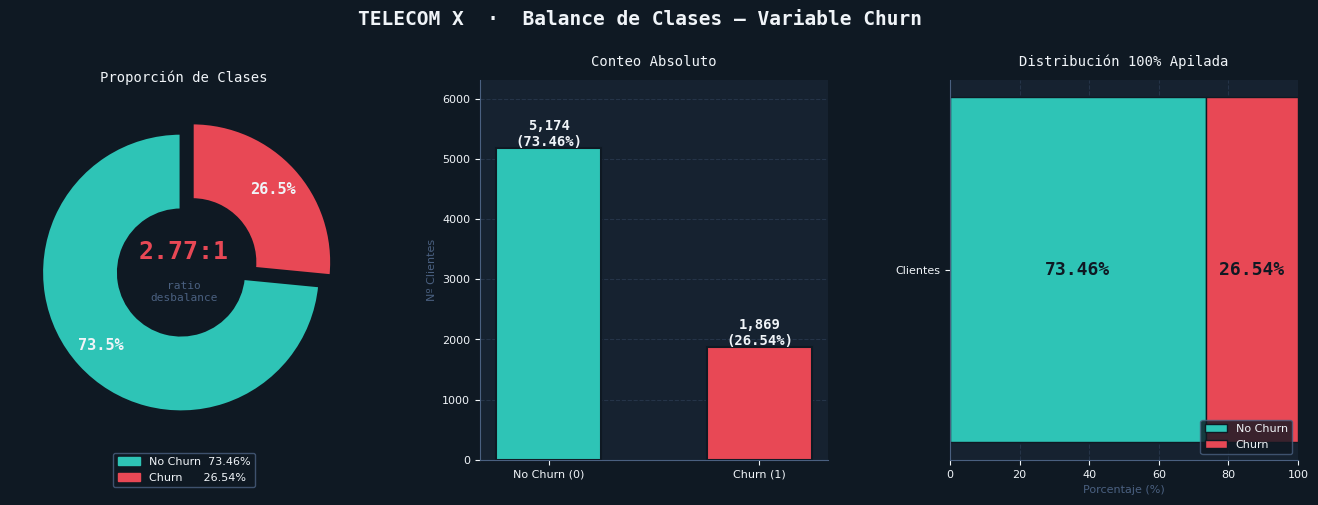


✅ Análisis de balance completado. Listo para dividir en train/test y entrenar modelos.


In [13]:
# ============================================================
# TELECOM X - Análisis Predictivo
# Paso 3: Evaluación del Balance de Clases (Churn)
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── Cargar y preparar datos ───────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]    = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]  = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["meses_contrato"] = pd.to_numeric(df_clean["meses_contrato"], errors="coerce")
df_clean["cargo_total"]    = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]          = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean.drop_duplicates(inplace=True)

# ================================================================
print("="*60)
print("⚖️  PASO 3: EVALUACIÓN DEL BALANCE DE CLASES")
print("="*60)

# ================================================================
# 1. PROPORCIÓN CON value_counts()
# ================================================================
print("\n1️⃣  CONTEO Y PROPORCIÓN DE CLASES")
print("="*60)

conteo     = df_clean["churn"].value_counts()
proporcion = df_clean["churn"].value_counts(normalize=True).mul(100).round(2)

resumen = pd.DataFrame({
    "Clase":        ["No canceló (0)", "Canceló (1)"],
    "Cantidad":     [conteo[0], conteo[1]],
    "Proporción %": [proporcion[0], proporcion[1]],
})
resumen = resumen.set_index("Clase")

print(f"\n{resumen.to_string()}")

total       = len(df_clean)
n_no_churn  = conteo[0]
n_churn     = conteo[1]
ratio       = round(n_no_churn / n_churn, 2)

print(f"\n  Total de clientes:   {total:,}")
print(f"  Ratio mayoría/minoría: {ratio}:1  ({n_no_churn:,} vs {n_churn:,})")

# ================================================================
# 2. DIAGNÓSTICO DEL DESBALANCE
# ================================================================
print("\n" + "="*60)
print("2️⃣  DIAGNÓSTICO DE DESBALANCE")
print("="*60)

pct_minoritaria = proporcion[1]

if pct_minoritaria < 10:
    nivel     = "🔴 SEVERO"
    accion    = "Requiere técnicas agresivas: SMOTE + class_weight o umbral personalizado."
elif pct_minoritaria < 20:
    nivel     = "🟠 MODERADO-ALTO"
    accion    = "Recomendado usar SMOTE, oversampling o class_weight='balanced'."
elif pct_minoritaria < 35:
    nivel     = "🟡 MODERADO"
    accion    = "Considerar class_weight='balanced' y evaluar con F1-score y AUC-ROC."
else:
    nivel     = "🟢 LEVE O INEXISTENTE"
    accion    = "El desbalance es manejable. Monitorear métricas de la clase minoritaria."

print(f"\n  Clase minoritaria (Churn=1): {pct_minoritaria}%")
print(f"  Nivel de desbalance:         {nivel}")
print(f"  Acción recomendada:          {accion}")

# ================================================================
# 3. IMPACTO EN MÉTRICAS DE EVALUACIÓN
# ================================================================
print("\n" + "="*60)
print("3️⃣  IMPACTO EN MÉTRICAS DE EVALUACIÓN")
print("="*60)
print(f"""
  Con un desbalance de {ratio}:1, un modelo "naive" que prediga
  SIEMPRE la clase 0 (no cancela) obtendría:

    • Accuracy:  {proporcion[0]}%  ← métrica engañosa ⚠️
    • Recall (churn=1):  0%       ← no detecta ningún churn ❌
    • Precision (churn=1): N/A    ← no predice ningún positivo ❌

  Por eso, las métricas correctas para este problema son:

    ✅ F1-Score     → equilibrio entre Precision y Recall
    ✅ AUC-ROC      → capacidad de discriminar entre clases
    ✅ Recall       → minimizar falsos negativos (clientes que sí cancelan)
    ⚠️  Accuracy    → NO usar como métrica principal
""")

# ================================================================
# 4. TÉCNICAS PARA TRATAR EL DESBALANCE
# ================================================================
print("="*60)
print("4️⃣  TÉCNICAS RECOMENDADAS PARA TRATAR EL DESBALANCE")
print("="*60)
print("""
  A. class_weight='balanced' ──────────────────────────────────
     Disponible en sklearn (LogisticRegression, RandomForest, etc.)
     Penaliza más los errores en la clase minoritaria durante el
     entrenamiento. Es la opción más simple y sin riesgo de data leakage.

  B. Oversampling — SMOTE ─────────────────────────────────────
     Genera ejemplos sintéticos de la clase minoritaria (Churn=1)
     interpolando entre muestras existentes.
     Librería: imbalanced-learn → SMOTE()
     ⚠️  Aplicar SOLO sobre el conjunto de entrenamiento, nunca sobre test.

  C. Undersampling — RandomUnderSampler ───────────────────────
     Reduce aleatoriamente la clase mayoritaria (No Churn).
     Riesgo: pérdida de información útil.
     Útil cuando el dataset es muy grande.

  D. Umbral de decisión personalizado ─────────────────────────
     Por defecto los modelos clasifican con umbral 0.5.
     Bajar el umbral (ej. 0.3) aumenta el Recall de la clase
     minoritaria a costa de más falsos positivos.
     Útil cuando el costo de no detectar un churn es alto.
""")

# ================================================================
# 5. VISUALIZACIÓN
# ================================================================
COLOR_STAY  = "#2EC4B6"
COLOR_CHURN = "#E84855"
COLOR_BG    = "#0F1923"
COLOR_PANEL = "#162230"
COLOR_TEXT  = "#F0F4F8"
COLOR_SUB   = "#4A6080"

fig = plt.figure(figsize=(14, 5), facecolor=COLOR_BG)
fig.suptitle("TELECOM X  ·  Balance de Clases — Variable Churn",
             fontsize=14, fontweight="bold", color=COLOR_TEXT,
             fontfamily="monospace", y=1.02)

gs = GridSpec(1, 3, figure=fig, wspace=0.35,
              left=0.05, right=0.97, top=0.88, bottom=0.12)

# ── Dona ──────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor(COLOR_PANEL)
wedges, _, autotexts = ax1.pie(
    [n_no_churn, n_churn],
    explode=(0.03, 0.08),
    colors=[COLOR_STAY, COLOR_CHURN],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=COLOR_BG, linewidth=2),
    textprops=dict(color=COLOR_TEXT, fontsize=11, fontfamily="monospace"),
    pctdistance=0.78,
)
for at in autotexts:
    at.set_fontweight("bold")
ax1.text(0, 0.08,  f"{ratio}:1",      ha="center", fontsize=18,
         fontweight="bold", color=COLOR_CHURN, fontfamily="monospace")
ax1.text(0, -0.22, "ratio\ndesbalance", ha="center", fontsize=8,
         color=COLOR_SUB, fontfamily="monospace")
ax1.set_title("Proporción de Clases", color=COLOR_TEXT,
              fontsize=10, fontfamily="monospace", pad=10)
ax1.legend(handles=[
    mpatches.Patch(color=COLOR_STAY,  label=f"No Churn  {proporcion[0]}%"),
    mpatches.Patch(color=COLOR_CHURN, label=f"Churn      {proporcion[1]}%"),
], loc="lower center", bbox_to_anchor=(0.5, -0.14), fontsize=8,
   facecolor=COLOR_BG, edgecolor=COLOR_SUB, labelcolor=COLOR_TEXT)

# ── Barras absolutas ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor(COLOR_PANEL)
bars = ax2.bar(["No Churn (0)", "Churn (1)"],
               [n_no_churn, n_churn],
               color=[COLOR_STAY, COLOR_CHURN],
               width=0.5, edgecolor=COLOR_BG, linewidth=1.5)
for bar, val, pct in zip(bars, [n_no_churn, n_churn], [proporcion[0], proporcion[1]]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
             f"{val:,}\n({pct}%)", ha="center", fontsize=10,
             color=COLOR_TEXT, fontfamily="monospace", fontweight="bold")
ax2.set_title("Conteo Absoluto", color=COLOR_TEXT,
              fontsize=10, fontfamily="monospace", pad=10)
ax2.set_ylabel("Nº Clientes", color=COLOR_SUB, fontsize=8)
ax2.set_ylim(0, max(n_no_churn, n_churn) * 1.22)
ax2.tick_params(colors=COLOR_TEXT, labelsize=8)
ax2.spines[["top","right"]].set_visible(False)
ax2.spines[["left","bottom"]].set_color(COLOR_SUB)
ax2.yaxis.grid(True, color=COLOR_SUB, alpha=0.3, linestyle="--")
ax2.set_axisbelow(True)

# ── Barra apilada 100% ────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.set_facecolor(COLOR_PANEL)
ax3.barh(["Clientes"], [proporcion[0]], color=COLOR_STAY,
         edgecolor=COLOR_BG, linewidth=1, label="No Churn")
ax3.barh(["Clientes"], [proporcion[1]], left=[proporcion[0]],
         color=COLOR_CHURN, edgecolor=COLOR_BG, linewidth=1, label="Churn")
ax3.text(proporcion[0]/2, 0, f"{proporcion[0]}%",
         ha="center", va="center", fontsize=13,
         fontweight="bold", color=COLOR_BG, fontfamily="monospace")
ax3.text(proporcion[0] + proporcion[1]/2, 0, f"{proporcion[1]}%",
         ha="center", va="center", fontsize=13,
         fontweight="bold", color=COLOR_BG, fontfamily="monospace")
ax3.set_xlim(0, 100)
ax3.set_title("Distribución 100% Apilada", color=COLOR_TEXT,
              fontsize=10, fontfamily="monospace", pad=10)
ax3.set_xlabel("Porcentaje (%)", color=COLOR_SUB, fontsize=8)
ax3.tick_params(colors=COLOR_TEXT, labelsize=8)
ax3.spines[["top","right"]].set_visible(False)
ax3.spines[["left","bottom"]].set_color(COLOR_SUB)
ax3.xaxis.grid(True, color=COLOR_SUB, alpha=0.3, linestyle="--")
ax3.set_axisbelow(True)
ax3.legend(fontsize=8, facecolor=COLOR_BG, edgecolor=COLOR_SUB,
           labelcolor=COLOR_TEXT, framealpha=0.8, loc="lower right")

plt.savefig("telecomx_balance_clases.png", dpi=130,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

print("\n✅ Análisis de balance completado. Listo para dividir en train/test y entrenar modelos.")

📏 PASO 4: NORMALIZACIÓN Y ESTANDARIZACIÓN

1️⃣  ANÁLISIS DE ESCALA ACTUAL (variables continuas)

      meses_contrato  cargo_total  Cuentas_Diarias
min             0.00        18.80             0.61
max            72.00      8684.80             3.96
mean           32.35      2279.29             2.16
std            24.57      2267.18             1.00

  ⚠️  Problema de escala detectado:
  - 'meses_contrato'  →  rango  0 – 72
  - 'cargo_total'     →  rango  0 – 8.000+
  - 'Cuentas_Diarias' →  rango  0 – 10 aprox.

  Modelos sensibles a la escala (KNN, SVM, Regresión Logística,
  Redes Neuronales) penalizarán variables con rangos grandes,
  distorsionando los resultados.

2️⃣  ¿QUÉ MODELOS REQUIEREN ESCALADO?

  ✅ REQUIEREN ESCALADO (sensibles a la distancia/magnitud):
     • Regresión Logística  → coeficientes comparables entre variables
     • KNN                  → distancias euclidianas equitativas
     • SVM                  → margen de separación afectado por escala
     • Redes Neu

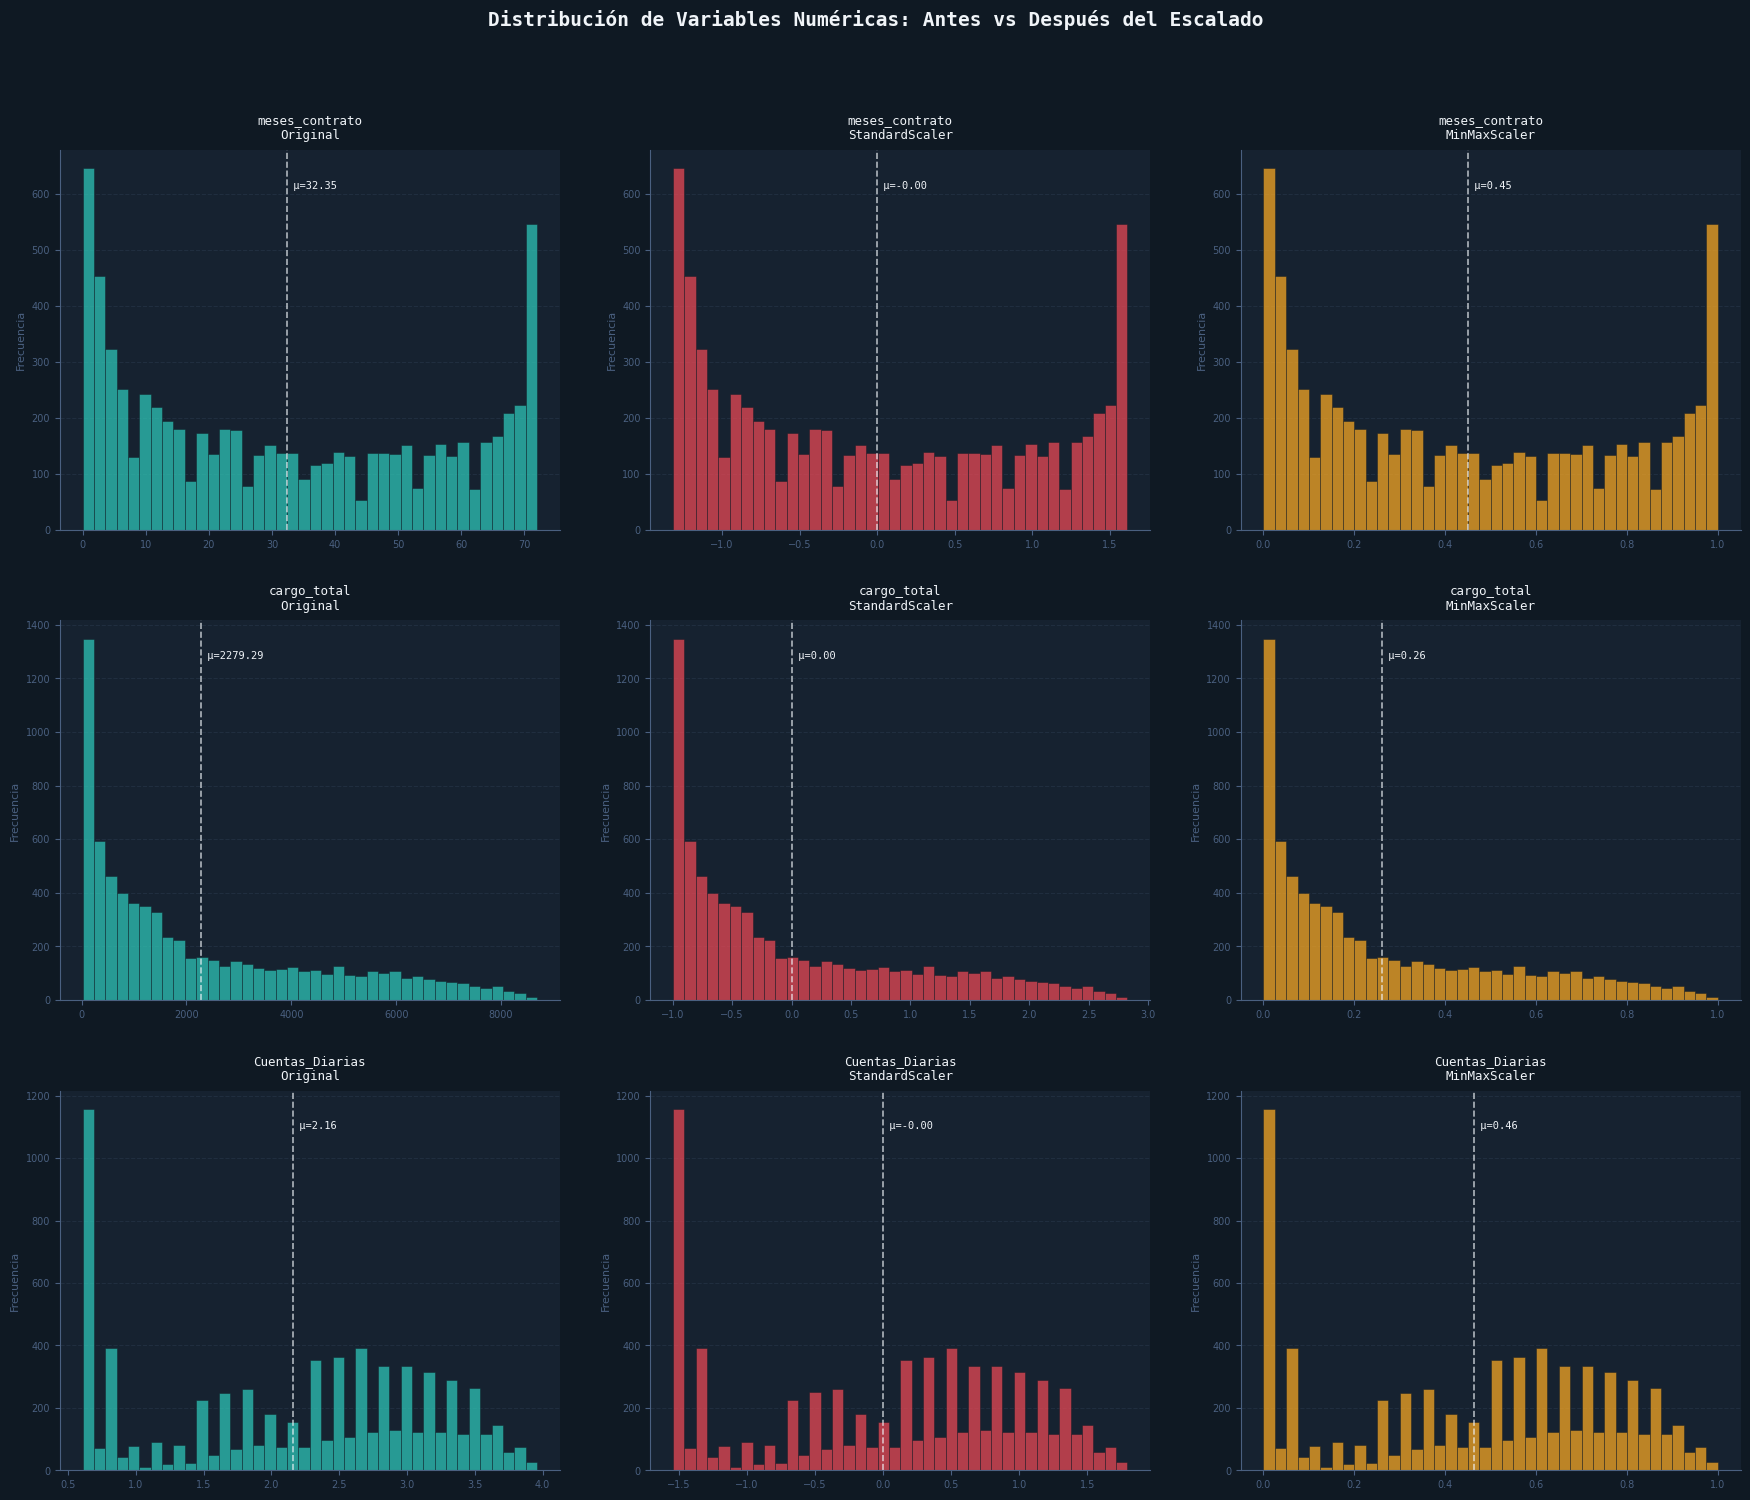


📊 RESUMEN FINAL — DATASETS DISPONIBLES

  Dataset             Filas   Columnas   Uso recomendado
  ─────────────────────────────────────────────────────────
  df_standard         7267    31         Regresión Logística, SVM
  df_minmax           7267    31         KNN, Redes Neuronales
  df_tree             7267    31         Decision Tree, Random Forest, XGBoost

✅ Escalado completado. Listo para dividir en train/test y entrenar modelos.


In [14]:
# ============================================================
# TELECOM X - Análisis Predictivo
# Paso 4: Normalización / Estandarización de Variables Numéricas
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ── Cargar y preparar datos (pipeline completo) ───────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]     = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]   = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["meses_contrato"]  = pd.to_numeric(df_clean["meses_contrato"], errors="coerce")
df_clean["cargo_total"]     = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]           = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

# Eliminar columnas sin valor predictivo
df_model = df_clean.drop(columns=["id_cliente", "cargo_mensual"], errors="ignore")

# One-Hot Encoding
cols_categoricas = df_model.select_dtypes(include="object").columns.tolist()
target   = df_model["churn"].copy()
features = df_model.drop(columns=["churn"])
features_encoded = pd.get_dummies(features, columns=cols_categoricas,
                                  drop_first=True, dtype=int)
df_encoded = features_encoded.copy()
df_encoded["churn"] = target.values

# ── Columnas numéricas continuas a escalar ────────────────────
# Las columnas binarias (0/1) ya están en la misma escala, no se escalan
cols_escalar = ["meses_contrato", "cargo_total", "Cuentas_Diarias"]
cols_escalar = [c for c in cols_escalar if c in df_encoded.columns]

# ================================================================
print("="*60)
print("📏 PASO 4: NORMALIZACIÓN Y ESTANDARIZACIÓN")
print("="*60)

# ================================================================
# 1. ANÁLISIS DE ESCALA ACTUAL
# ================================================================
print("\n1️⃣  ANÁLISIS DE ESCALA ACTUAL (variables continuas)")
print("="*60)

stats_antes = df_encoded[cols_escalar].agg(["min","max","mean","std"]).round(2)
print(f"\n{stats_antes.to_string()}")

print("""
  ⚠️  Problema de escala detectado:
  - 'meses_contrato'  →  rango  0 – 72
  - 'cargo_total'     →  rango  0 – 8.000+
  - 'Cuentas_Diarias' →  rango  0 – 10 aprox.

  Modelos sensibles a la escala (KNN, SVM, Regresión Logística,
  Redes Neuronales) penalizarán variables con rangos grandes,
  distorsionando los resultados.
""")

# ================================================================
# 2. CUÁNDO ESCALAR Y CUÁNDO NO
# ================================================================
print("="*60)
print("2️⃣  ¿QUÉ MODELOS REQUIEREN ESCALADO?")
print("="*60)
print("""
  ✅ REQUIEREN ESCALADO (sensibles a la distancia/magnitud):
     • Regresión Logística  → coeficientes comparables entre variables
     • KNN                  → distancias euclidianas equitativas
     • SVM                  → margen de separación afectado por escala
     • Redes Neuronales     → convergencia del gradiente más estable
     • PCA / reducción dim. → varianza dominada por variables de gran escala

  ❌ NO REQUIEREN ESCALADO (invariantes a la escala):
     • Decision Tree        → usa umbrales, no distancias
     • Random Forest        → ensemble de árboles
     • XGBoost / LightGBM   → gradient boosting sobre árboles
     • Naive Bayes          → probabilidades condicionales

  📌 DECISIÓN: Se generan DOS versiones del dataset:
     → df_standard : StandardScaler  (media=0, std=1)  — para modelos lineales
     → df_minmax   : MinMaxScaler    (rango [0,1])      — para KNN y Redes Neuronales
     → df_tree     : sin escalar                        — para árboles
""")

# ================================================================
# 3. APLICAR ESCALADO
# ================================================================
print("="*60)
print("3️⃣  APLICANDO ESCALADORES")
print("="*60)

X = df_encoded.drop(columns=["churn"])
y = df_encoded["churn"]

# ── StandardScaler ────────────────────────────────────────────
scaler_std = StandardScaler()
X_standard = X.copy()
X_standard[cols_escalar] = scaler_std.fit_transform(X[cols_escalar])

df_standard      = X_standard.copy()
df_standard["churn"] = y.values

print("\n  ✅ StandardScaler aplicado (media=0, std=1):")
print(df_standard[cols_escalar].agg(["min","max","mean","std"]).round(4).to_string())

# ── MinMaxScaler ──────────────────────────────────────────────
scaler_mm = MinMaxScaler()
X_minmax  = X.copy()
X_minmax[cols_escalar] = scaler_mm.fit_transform(X[cols_escalar])

df_minmax         = X_minmax.copy()
df_minmax["churn"] = y.values

print("\n  ✅ MinMaxScaler aplicado (rango [0, 1]):")
print(df_minmax[cols_escalar].agg(["min","max","mean","std"]).round(4).to_string())

# ── Sin escalar (árboles) ──────────────────────────────────────
df_tree       = X.copy()
df_tree["churn"] = y.values
print("\n  ✅ Dataset sin escalar conservado para modelos basados en árboles.")

# ================================================================
# 4. VISUALIZACIÓN — ANTES vs DESPUÉS
# ================================================================
COLOR_BG    = "#0F1923"
COLOR_PANEL = "#162230"
COLOR_TEXT  = "#F0F4F8"
COLOR_SUB   = "#4A6080"
COLORES     = ["#2EC4B6", "#E84855", "#F5A623"]

fig = plt.figure(figsize=(18, 5 * len(cols_escalar)), facecolor=COLOR_BG)
fig.suptitle("Distribución de Variables Numéricas: Antes vs Después del Escalado",
             fontsize=14, fontweight="bold", color=COLOR_TEXT,
             fontfamily="monospace", y=1.01)

for row, col in enumerate(cols_escalar):
    versiones = [
        (X[col],              "Original",     COLORES[0]),
        (X_standard[col],     "StandardScaler", COLORES[1]),
        (X_minmax[col],       "MinMaxScaler", COLORES[2]),
    ]
    for c_idx, (serie, titulo, color) in enumerate(versiones):
        ax = fig.add_subplot(len(cols_escalar), 3, row * 3 + c_idx + 1)
        ax.set_facecolor(COLOR_PANEL)
        ax.hist(serie.dropna(), bins=40, color=color,
                alpha=0.75, edgecolor=COLOR_BG, linewidth=0.4)
        ax.set_title(f"{col}\n{titulo}", color=COLOR_TEXT,
                     fontsize=9, fontfamily="monospace", pad=8)
        ax.set_ylabel("Frecuencia", color=COLOR_SUB, fontsize=8)
        media = serie.mean()
        ax.axvline(media, color=COLOR_TEXT, linestyle="--",
                   linewidth=1.2, alpha=0.7)
        ax.text(media, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 1,
                f" μ={media:.2f}", color=COLOR_TEXT,
                fontsize=7.5, fontfamily="monospace")
        ax.tick_params(colors=COLOR_SUB, labelsize=7)
        ax.spines[["top","right"]].set_visible(False)
        ax.spines[["left","bottom"]].set_color(COLOR_SUB)
        ax.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
        ax.set_axisbelow(True)

plt.tight_layout(pad=2.5)
plt.savefig("telecomx_escalado.png", dpi=130,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# 5. RESUMEN FINAL
# ================================================================
print("\n" + "="*60)
print("📊 RESUMEN FINAL — DATASETS DISPONIBLES")
print("="*60)
print(f"""
  Dataset             Filas   Columnas   Uso recomendado
  ─────────────────────────────────────────────────────────
  df_standard         {df_standard.shape[0]:<7} {df_standard.shape[1]:<10} Regresión Logística, SVM
  df_minmax           {df_minmax.shape[0]:<7} {df_minmax.shape[1]:<10} KNN, Redes Neuronales
  df_tree             {df_tree.shape[0]:<7} {df_tree.shape[1]:<10} Decision Tree, Random Forest, XGBoost
""")
print("✅ Escalado completado. Listo para dividir en train/test y entrenar modelos.")

🔗 PASO 5: MATRIZ DE CORRELACIÓN

1️⃣  CORRELACIÓN DE TODAS LAS VARIABLES CON 'churn'

  Variable                                       Correlación  Fuerza
  ----------------------------------------------------------------------
  meses_contrato                                   -0.3522   🔴 Fuerte  (▼ negativa)
  tipo_internet_Fiber optic                         0.3080   🔴 Fuerte  (▲ positiva)
  tipo_contrato_Two year                           -0.3023   🔴 Fuerte  (▼ negativa)
  metodo_pago_Electronic check                      0.3019   🔴 Fuerte  (▲ positiva)
  tipo_internet_No                                 -0.2279   🟠 Moderada  (▼ negativa)
  seguridad_online_No internet service             -0.2279   🟠 Moderada  (▼ negativa)
  proteccion_dispositivo_No internet service       -0.2279   🟠 Moderada  (▼ negativa)
  soporte_tecnico_No internet service              -0.2279   🟠 Moderada  (▼ negativa)
  streaming_peliculas_No internet service          -0.2279   🟠 Moderada  (▼ negativa)
  stre

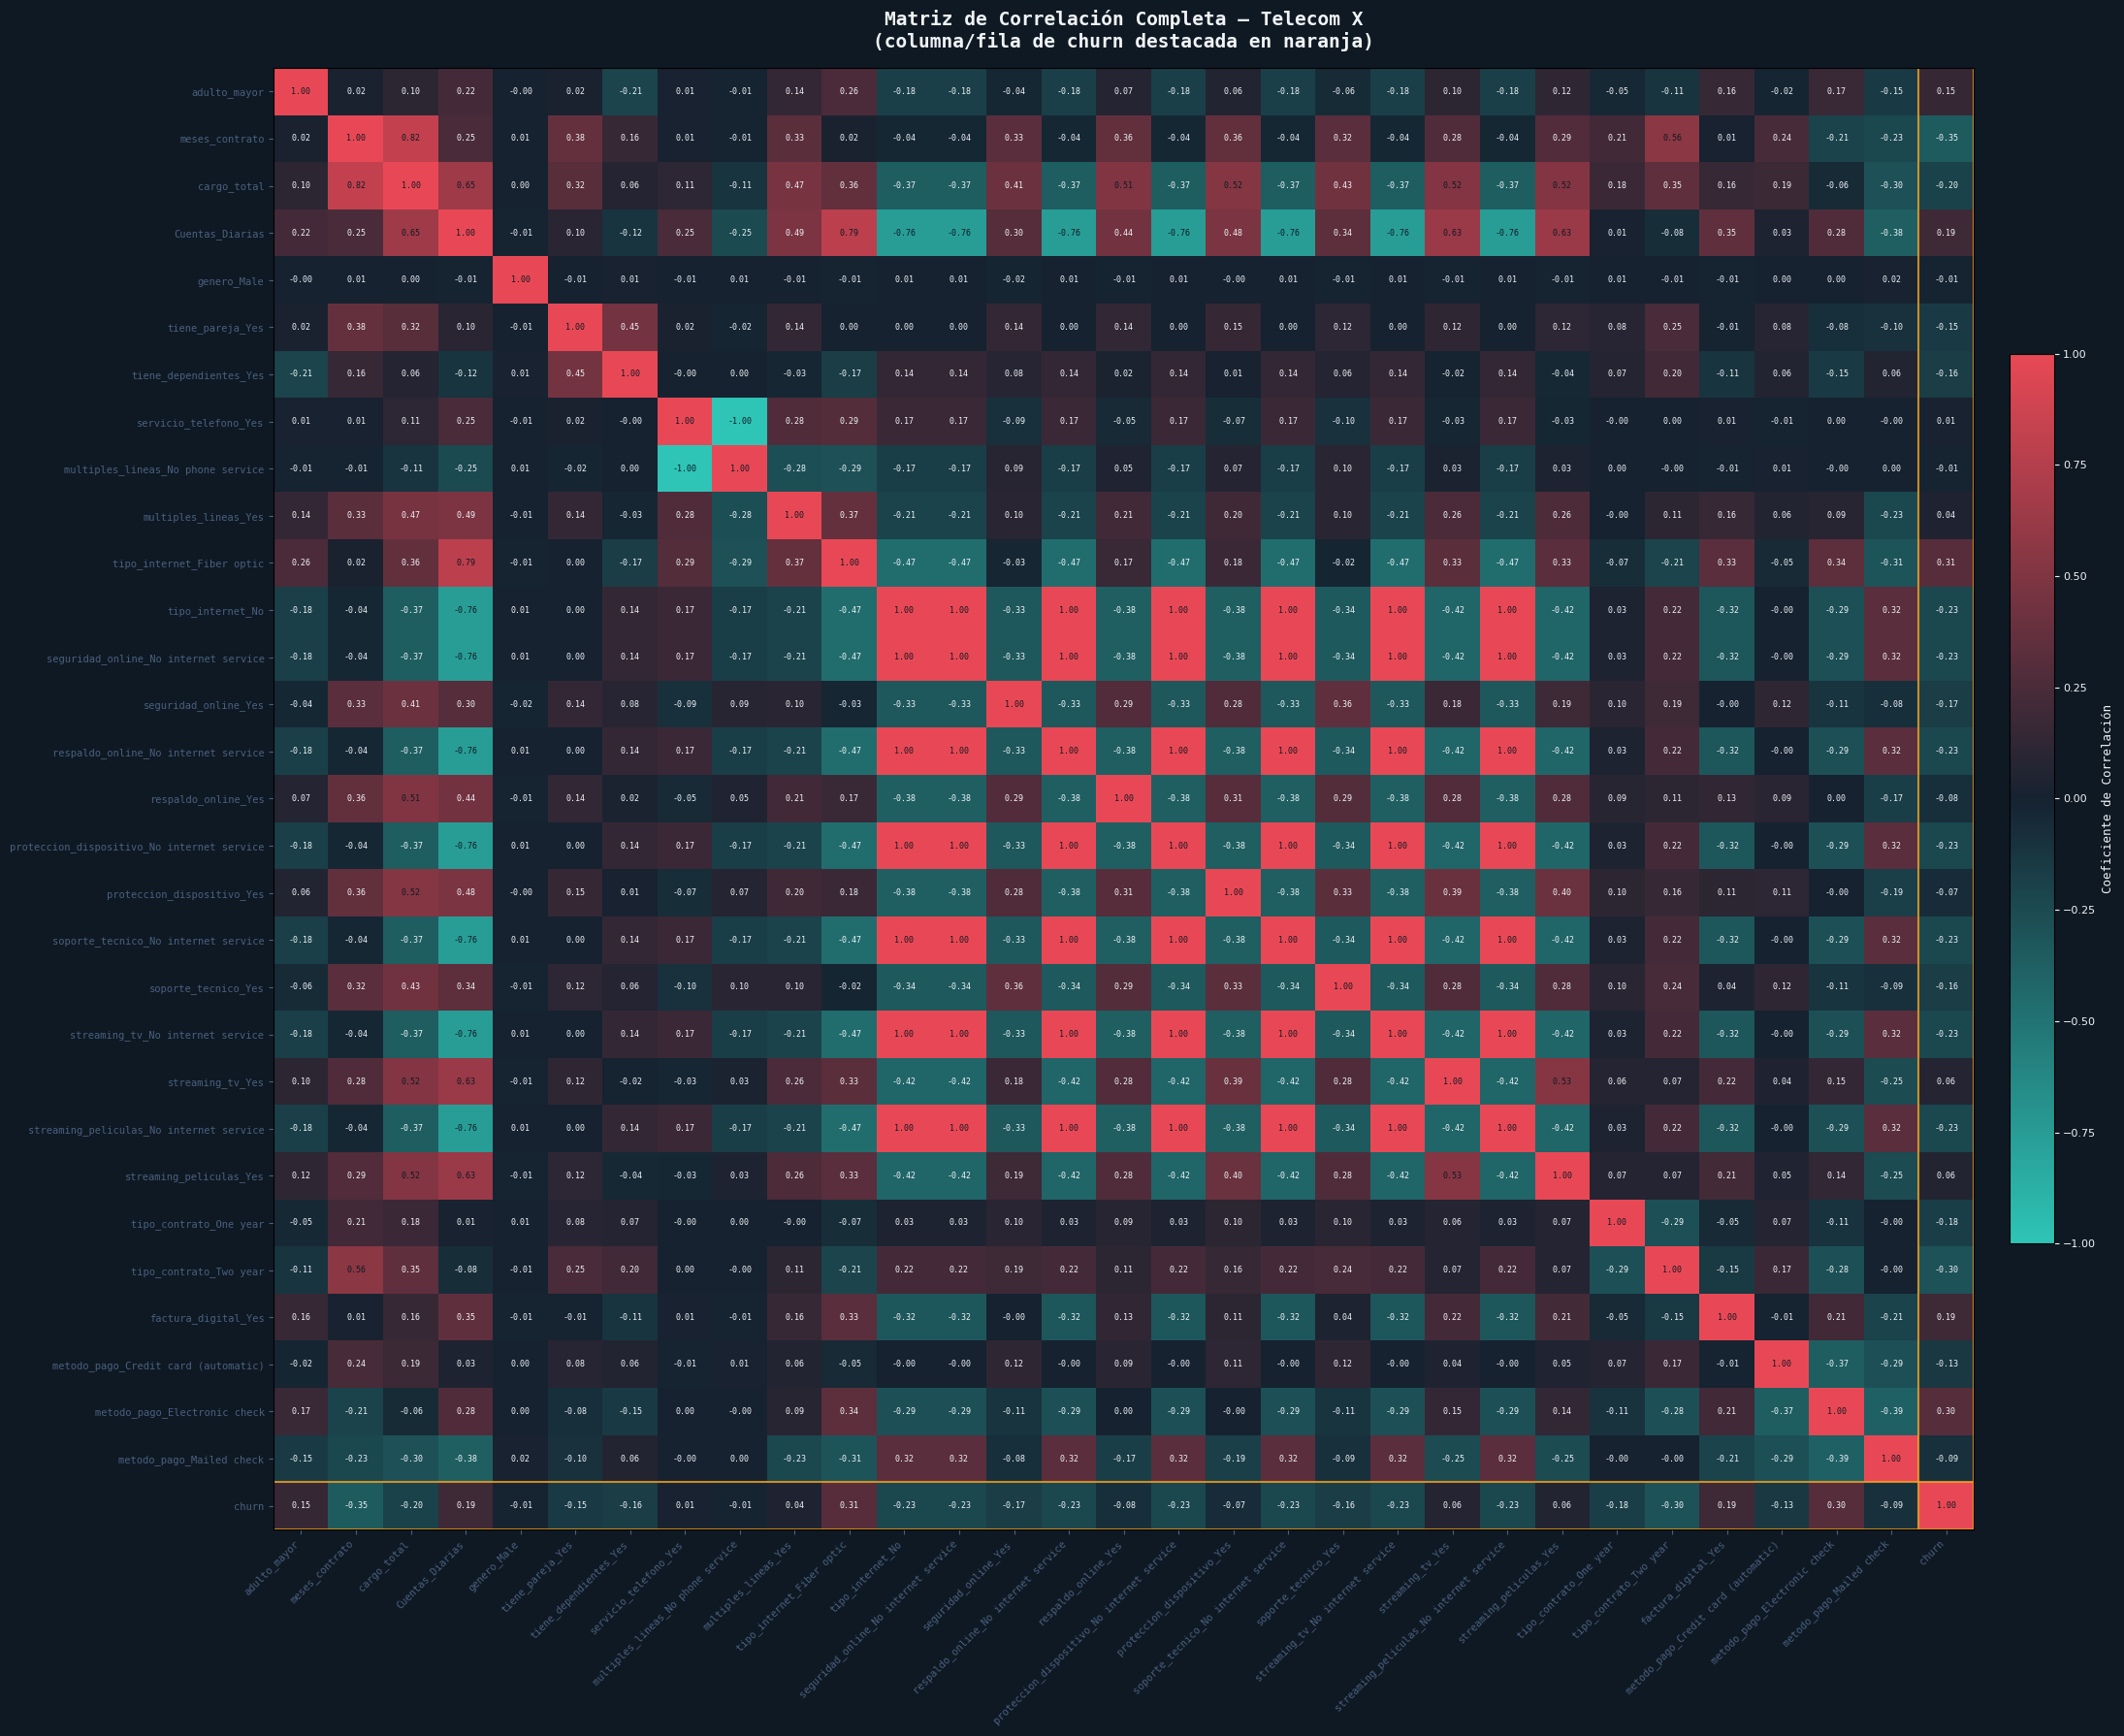

3️⃣  Generando heatmap focalizado (Top 15 vs churn)...


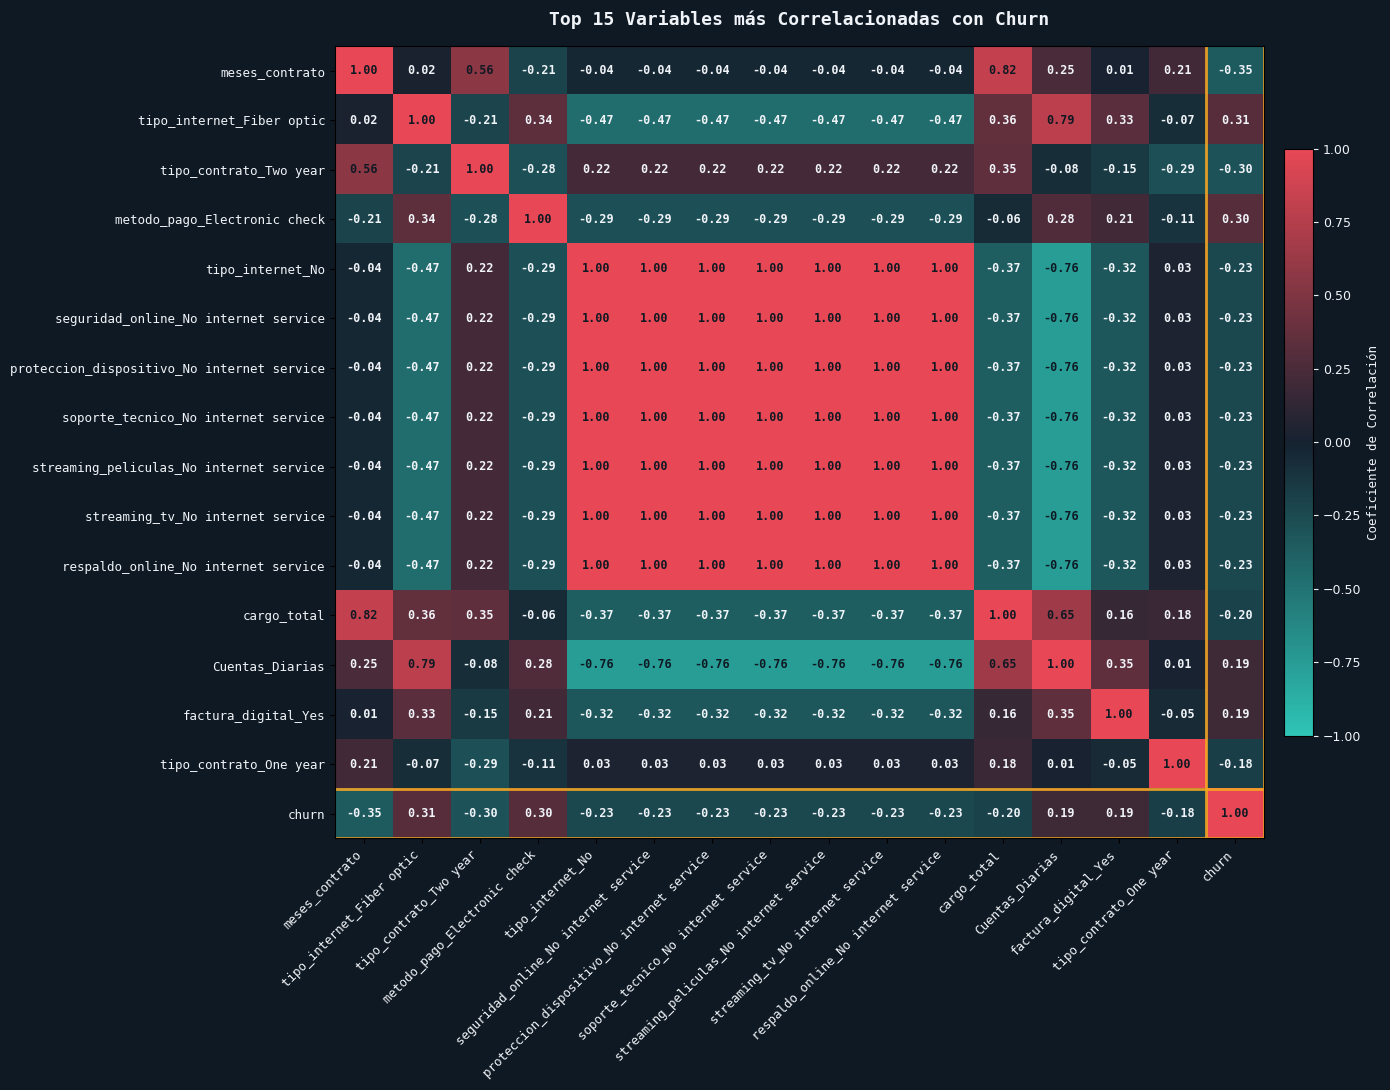

4️⃣  Generando barplot de correlaciones con churn...


/tmp/ipykernel_425/250930904.py:252: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_425/250930904.py:252: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_425/250930904.py:253: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("telecomx_correlacion_barplot.png", dpi=130,
/tmp/ipykernel_425/250930904.py:253: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("telecomx_correlacion_barplot.png", dpi=130,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from f

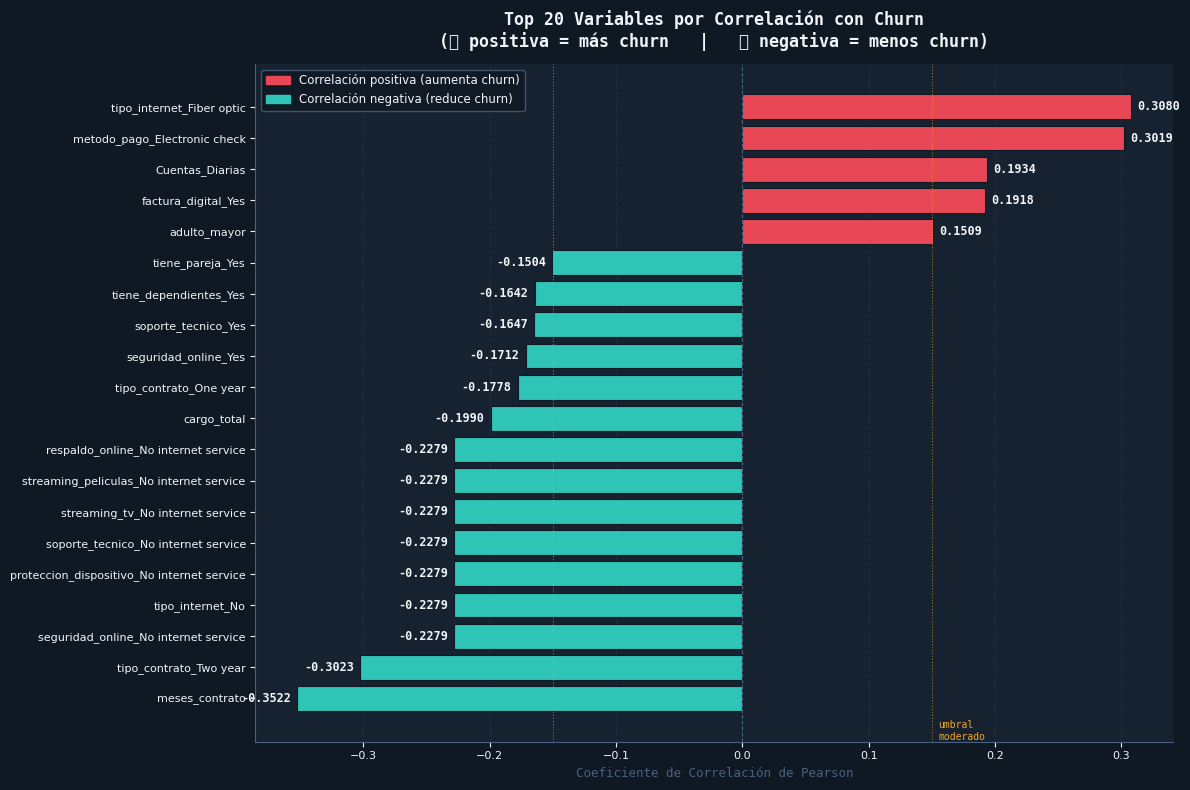


💡 INSIGHTS — VARIABLES CANDIDATAS PARA EL MODELO

  🔴 Variables que AUMENTAN la probabilidad de churn:
     tipo_internet_Fiber optic                     r = +0.3080
     metodo_pago_Electronic check                  r = +0.3019
     Cuentas_Diarias                               r = +0.1934
     factura_digital_Yes                           r = +0.1918
     adulto_mayor                                  r = +0.1509

  🟦 Variables que REDUCEN la probabilidad de churn:
     meses_contrato                                r = -0.3522
     tipo_contrato_Two year                        r = -0.3023
     tipo_internet_No                              r = -0.2279
     seguridad_online_No internet service          r = -0.2279
     proteccion_dispositivo_No internet service    r = -0.2279
     soporte_tecnico_No internet service           r = -0.2279
     streaming_peliculas_No internet service       r = -0.2279
     streaming_tv_No internet service              r = -0.2279
     respaldo_online_No 

In [15]:
# ============================================================
# TELECOM X - Análisis Predictivo
# Paso 5: Matriz de Correlación
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

# ── Cargar y preparar datos (pipeline completo) ───────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]     = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]   = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["meses_contrato"]  = pd.to_numeric(df_clean["meses_contrato"], errors="coerce")
df_clean["cargo_total"]     = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]           = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

df_model = df_clean.drop(columns=["id_cliente", "cargo_mensual"], errors="ignore")

cols_categoricas = df_model.select_dtypes(include="object").columns.tolist()
target           = df_model["churn"].copy()
features         = df_model.drop(columns=["churn"])
features_encoded = pd.get_dummies(features, columns=cols_categoricas,
                                  drop_first=True, dtype=int)
df_encoded            = features_encoded.copy()
df_encoded["churn"]   = target.values

# ================================================================
print("="*60)
print("🔗 PASO 5: MATRIZ DE CORRELACIÓN")
print("="*60)

# ================================================================
# 1. CORRELACIÓN CON CHURN (ranking)
# ================================================================
print("\n1️⃣  CORRELACIÓN DE TODAS LAS VARIABLES CON 'churn'")
print("="*60)

corr_churn = df_encoded.corr()["churn"].drop("churn").sort_values(key=abs, ascending=False)

print(f"\n  {'Variable':<45} {'Correlación':>12}  Fuerza")
print(f"  {'-'*70}")
for var, val in corr_churn.items():
    if abs(val) > 0.3:
        fuerza = "🔴 Fuerte"
    elif abs(val) > 0.15:
        fuerza = "🟠 Moderada"
    elif abs(val) > 0.05:
        fuerza = "🟡 Débil"
    else:
        fuerza = "⚪ Muy débil"
    direccion = "▲ positiva" if val > 0 else "▼ negativa"
    print(f"  {var:<45} {val:>10.4f}   {fuerza}  ({direccion})")

# Top 10 más correlacionadas
top10 = corr_churn.head(10)
print(f"\n  🎯 Top 10 variables más correlacionadas con churn:")
for i, (var, val) in enumerate(top10.items(), 1):
    barra = "█" * int(abs(val) * 40)
    print(f"  {i:>2}. {var:<42} {val:>7.4f}  {barra}")

# ================================================================
# 2. MATRIZ DE CORRELACIÓN COMPLETA — HEATMAP
# ================================================================
print("\n2️⃣  Generando heatmap de correlación completa...")

COLOR_BG    = "#0F1923"
COLOR_PANEL = "#162230"
COLOR_TEXT  = "#F0F4F8"
COLOR_SUB   = "#4A6080"

# Colormap personalizado: azul → blanco → rojo
cmap_custom = LinearSegmentedColormap.from_list(
    "telecom",
    ["#2EC4B6", "#162230", "#E84855"],
    N=256
)

corr_matrix = df_encoded.corr()
n = len(corr_matrix)

fig, ax = plt.subplots(figsize=(22, 18), facecolor=COLOR_BG)
ax.set_facecolor(COLOR_PANEL)

im = ax.imshow(corr_matrix.values, cmap=cmap_custom, vmin=-1, vmax=1, aspect="auto")

# Etiquetas de ejes
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right",
                   fontsize=7.5, color=COLOR_TEXT, fontfamily="monospace")
ax.set_yticklabels(corr_matrix.columns, fontsize=7.5,
                   color=COLOR_TEXT, fontfamily="monospace")

# Anotaciones numéricas en cada celda
for i in range(n):
    for j in range(n):
        val = corr_matrix.values[i, j]
        color_txt = COLOR_BG if abs(val) > 0.5 else COLOR_TEXT
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6, color=color_txt, fontfamily="monospace")

# Destacar columna/fila de churn con borde
churn_idx = list(corr_matrix.columns).index("churn")
for offset in [-0.5, 0.5]:
    ax.axhline(churn_idx + offset, color="#F5A623", linewidth=1.5, alpha=0.8)
    ax.axvline(churn_idx + offset, color="#F5A623", linewidth=1.5, alpha=0.8)

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.ax.tick_params(colors=COLOR_TEXT, labelsize=8)
cbar.set_label("Coeficiente de Correlación", color=COLOR_TEXT,
               fontsize=9, fontfamily="monospace")

ax.set_title("Matriz de Correlación Completa — Telecom X\n(columna/fila de churn destacada en naranja)",
             color=COLOR_TEXT, fontsize=14, fontweight="bold",
             fontfamily="monospace", pad=15)
ax.tick_params(colors=COLOR_SUB)

plt.tight_layout()
plt.savefig("telecomx_correlacion_completa.png", dpi=130,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# 3. HEATMAP FOCALIZADO — solo top correlaciones con churn
# ================================================================
print("3️⃣  Generando heatmap focalizado (Top 15 vs churn)...")

top15_vars = corr_churn.head(15).index.tolist() + ["churn"]
corr_top   = df_encoded[top15_vars].corr()

fig2, ax2 = plt.subplots(figsize=(14, 11), facecolor=COLOR_BG)
ax2.set_facecolor(COLOR_PANEL)

n2 = len(corr_top)
im2 = ax2.imshow(corr_top.values, cmap=cmap_custom, vmin=-1, vmax=1, aspect="auto")

ax2.set_xticks(range(n2))
ax2.set_yticks(range(n2))
ax2.set_xticklabels(corr_top.columns, rotation=45, ha="right",
                    fontsize=9, color=COLOR_TEXT, fontfamily="monospace")
ax2.set_yticklabels(corr_top.columns, fontsize=9,
                    color=COLOR_TEXT, fontfamily="monospace")

for i in range(n2):
    for j in range(n2):
        val = corr_top.values[i, j]
        color_txt = COLOR_BG if abs(val) > 0.5 else COLOR_TEXT
        ax2.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=8.5, color=color_txt, fontweight="bold",
                 fontfamily="monospace")

churn_idx2 = list(corr_top.columns).index("churn")
for offset in [-0.5, 0.5]:
    ax2.axhline(churn_idx2 + offset, color="#F5A623", linewidth=2, alpha=0.9)
    ax2.axvline(churn_idx2 + offset, color="#F5A623", linewidth=2, alpha=0.9)

cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.03, pad=0.02)
cbar2.ax.tick_params(colors=COLOR_TEXT, labelsize=9)
cbar2.set_label("Coeficiente de Correlación", color=COLOR_TEXT,
                fontsize=9, fontfamily="monospace")

ax2.set_title("Top 15 Variables más Correlacionadas con Churn",
              color=COLOR_TEXT, fontsize=13, fontweight="bold",
              fontfamily="monospace", pad=15)
plt.tight_layout()
plt.savefig("telecomx_correlacion_top15.png", dpi=130,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# 4. BARPLOT — correlación con churn ordenada
# ================================================================
print("4️⃣  Generando barplot de correlaciones con churn...")

top_n   = 20
corr_plot = corr_churn.head(top_n).sort_values()

fig3, ax3 = plt.subplots(figsize=(12, 8), facecolor=COLOR_BG)
ax3.set_facecolor(COLOR_PANEL)

colores_bar = ["#E84855" if v > 0 else "#2EC4B6" for v in corr_plot.values]
bars = ax3.barh(corr_plot.index, corr_plot.values,
                color=colores_bar, edgecolor=COLOR_BG, linewidth=0.8)

for bar, val in zip(bars, corr_plot.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha   = "left" if val >= 0 else "right"
    ax3.text(xpos, bar.get_y() + bar.get_height()/2,
             f"{val:.4f}", va="center", ha=ha, fontsize=8.5,
             color=COLOR_TEXT, fontfamily="monospace", fontweight="bold")

ax3.axvline(0, color=COLOR_SUB, linewidth=0.8, linestyle="--")
ax3.axvline( 0.15, color="#F5A623", linewidth=0.8, linestyle=":", alpha=0.6)
ax3.axvline(-0.15, color="#F5A623", linewidth=0.8, linestyle=":", alpha=0.6)
ax3.text(0.155,  ax3.get_ylim()[0], "umbral\nmoderado",
         color="#F5A623", fontsize=7, fontfamily="monospace", va="bottom")

ax3.set_title(f"Top {top_n} Variables por Correlación con Churn\n"
              "(🔴 positiva = más churn   |   🟦 negativa = menos churn)",
              color=COLOR_TEXT, fontsize=12, fontweight="bold",
              fontfamily="monospace", pad=12)
ax3.set_xlabel("Coeficiente de Correlación de Pearson",
               color=COLOR_SUB, fontsize=9, fontfamily="monospace")
ax3.tick_params(colors=COLOR_TEXT, labelsize=8)
ax3.spines[["top","right"]].set_visible(False)
ax3.spines[["left","bottom"]].set_color(COLOR_SUB)
ax3.xaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax3.set_axisbelow(True)

legend_elements = [
    mpatches.Patch(color="#E84855", label="Correlación positiva (aumenta churn)"),
    mpatches.Patch(color="#2EC4B6", label="Correlación negativa (reduce churn)"),
]
ax3.legend(handles=legend_elements, fontsize=8.5, facecolor=COLOR_BG,
           edgecolor=COLOR_SUB, labelcolor=COLOR_TEXT, framealpha=0.8)

plt.tight_layout()
plt.savefig("telecomx_correlacion_barplot.png", dpi=130,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# 5. RESUMEN E INSIGHTS
# ================================================================
print("\n" + "="*60)
print("💡 INSIGHTS — VARIABLES CANDIDATAS PARA EL MODELO")
print("="*60)

positivas = corr_churn[corr_churn > 0.10].sort_values(ascending=False)
negativas = corr_churn[corr_churn < -0.10].sort_values()

print(f"\n  🔴 Variables que AUMENTAN la probabilidad de churn:")
for var, val in positivas.items():
    print(f"     {var:<45} r = {val:+.4f}")

print(f"\n  🟦 Variables que REDUCEN la probabilidad de churn:")
for var, val in negativas.items():
    print(f"     {var:<45} r = {val:+.4f}")

print("""
  📌 CONCLUSIÓN PARA EL MODELO PREDICTIVO:
  Las variables con mayor correlación absoluta deben priorizarse
  como features en el entrenamiento. Variables con correlación
  muy baja (< 0.05) pueden considerarse para eliminación si se
  busca un modelo más parsimonioso.
""")
print("✅ Análisis de correlación completado. Listo para entrenar modelos.")

🔍 PASO 6: RELACIÓN DE VARIABLES CLAVE CON CANCELACIÓN


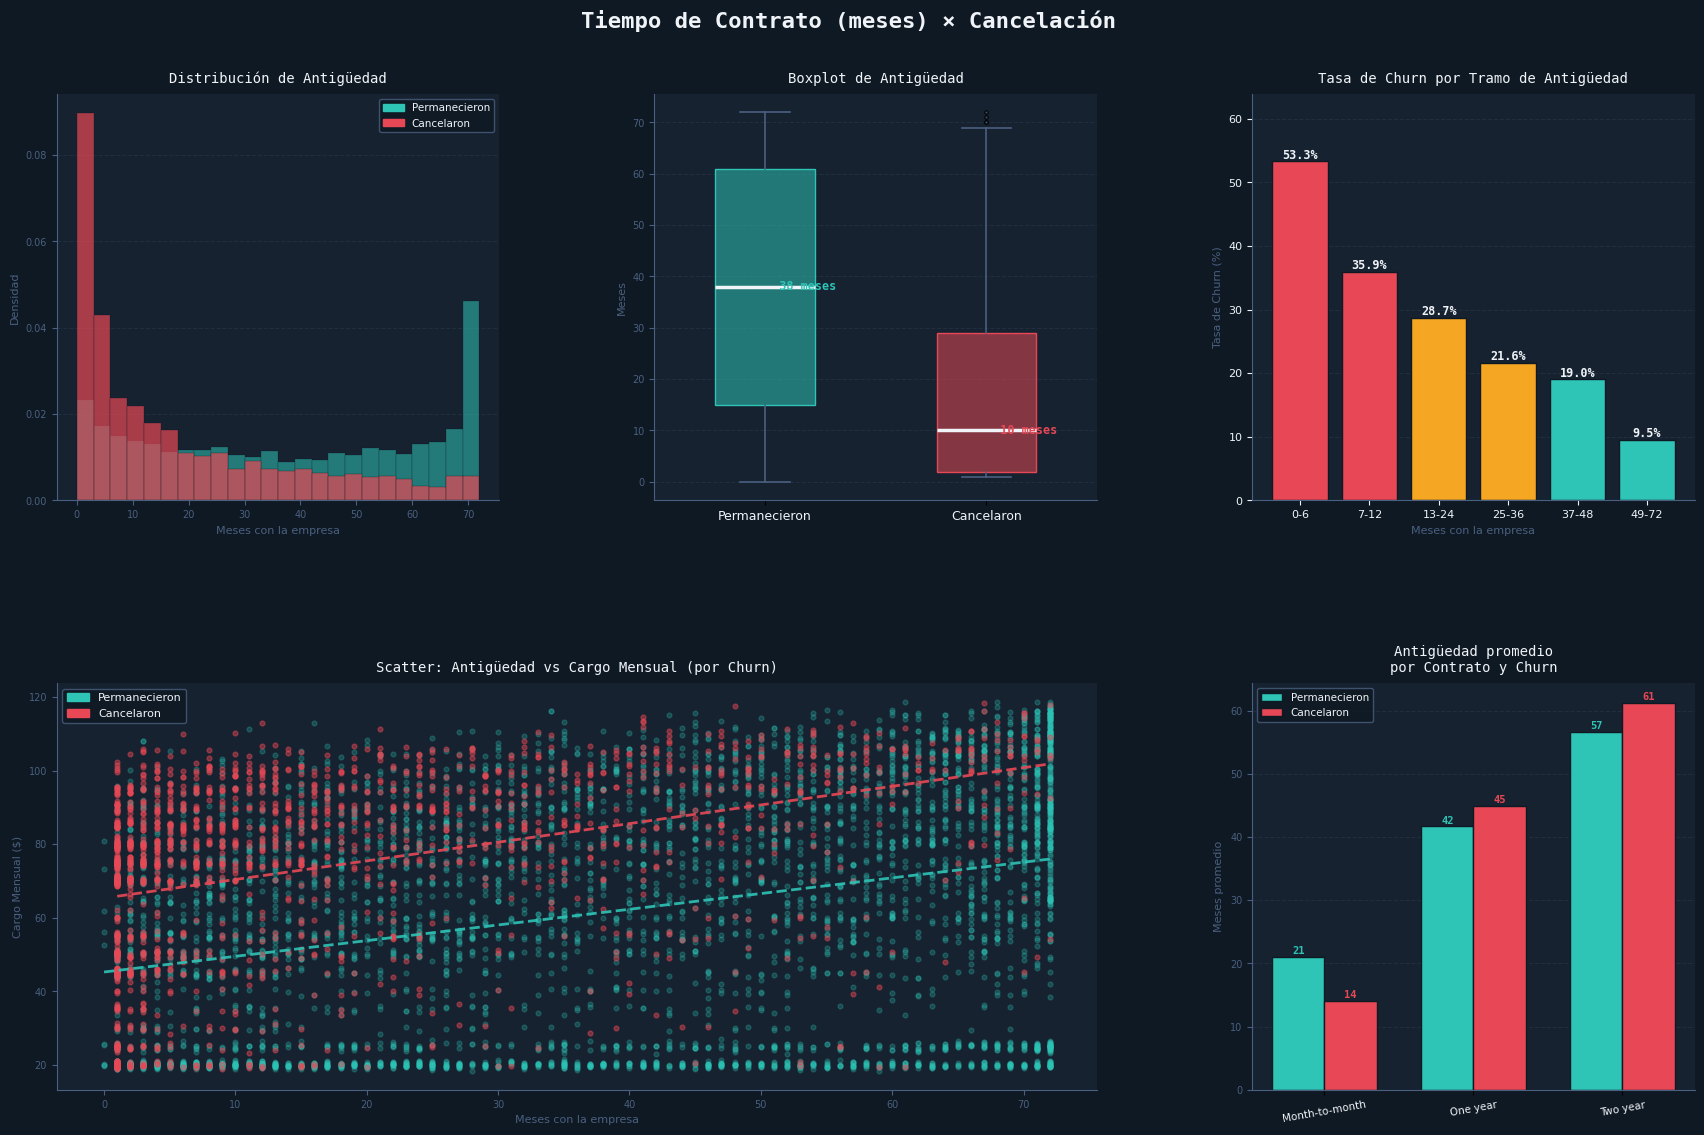

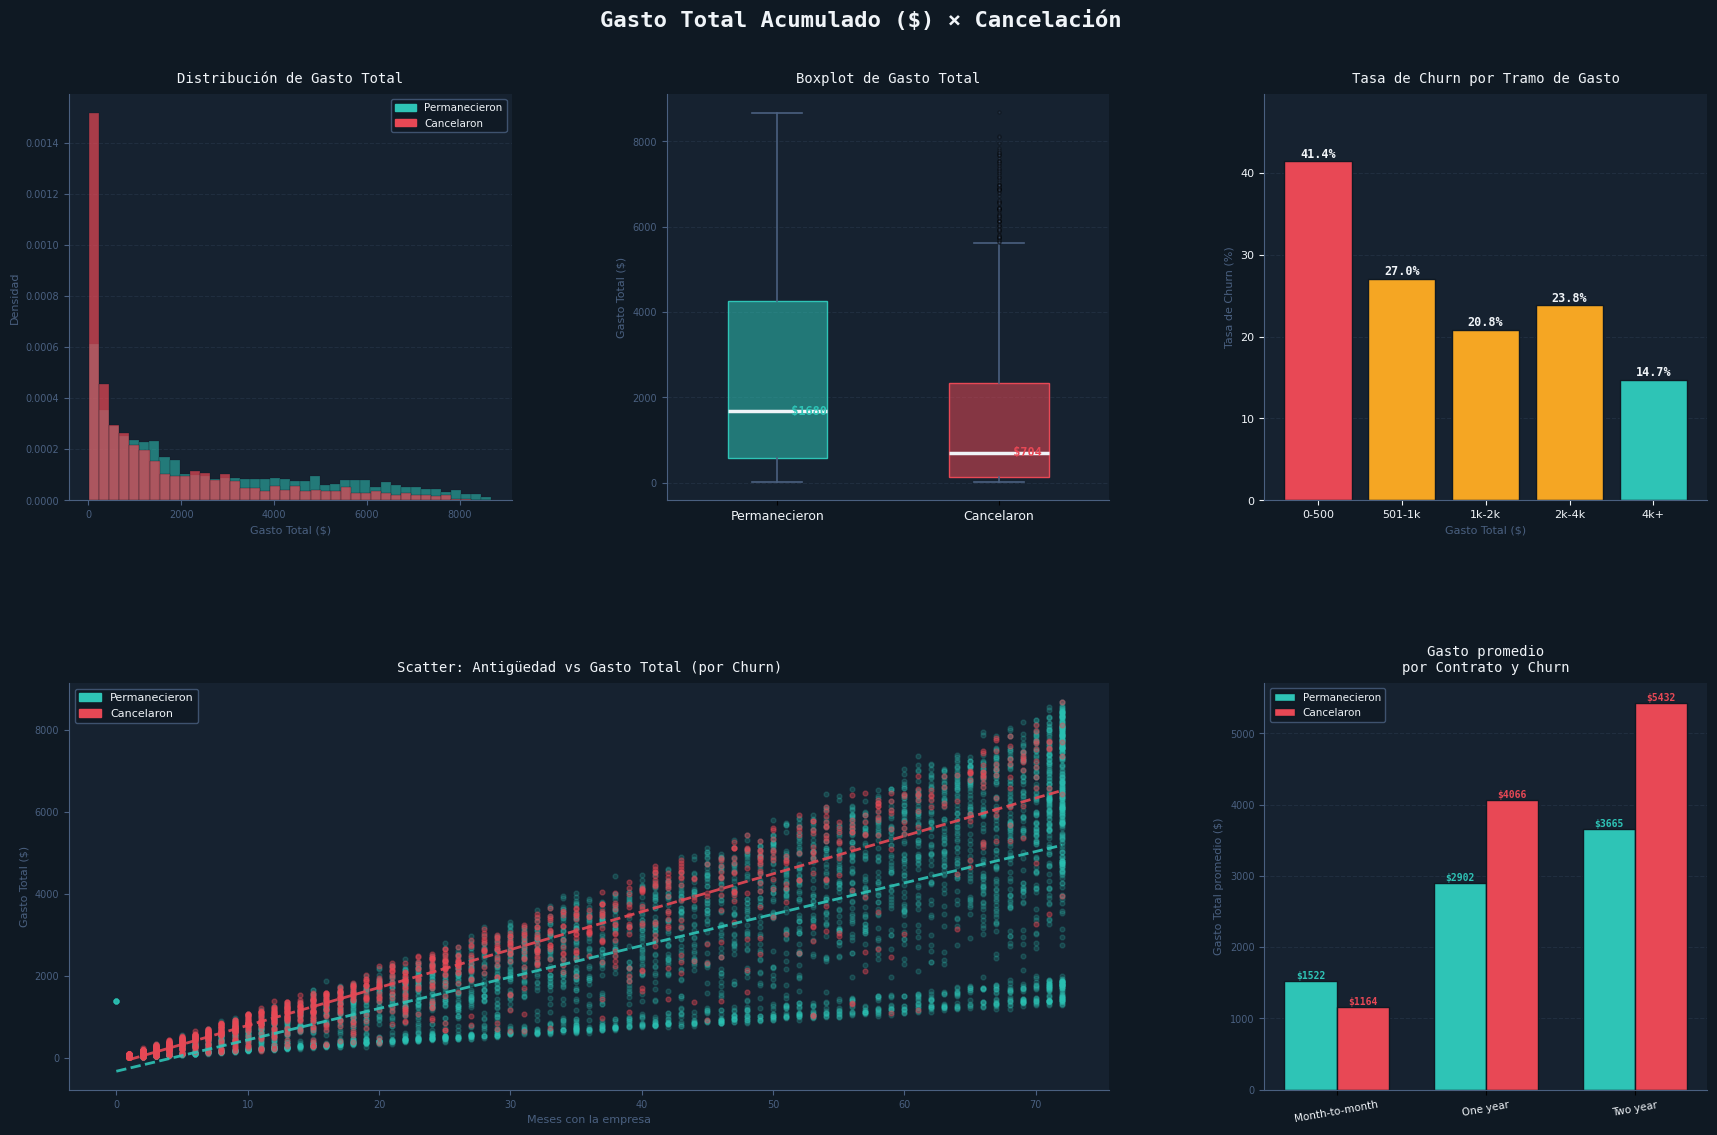


📊 ESTADÍSTICAS COMPARATIVAS

  📌 Antigüedad:
                        Permanecieron     Cancelaron
  --------------------------------------------------
  Media                        37.6meses          18.0meses
  Mediana                      38.0meses          10.0meses
  Std                          24.1meses          19.5meses
  Mann-Whitney U: p=0.00000  → ✅ Significativa (p<0.05)

  📌 Gasto Total:
                        Permanecieron     Cancelaron
  --------------------------------------------------
  Media                      2552.9  $        1531.8$
  Mediana                    1679.5  $         703.5$
  Std                        2327.6  $        1890.8$
  Mann-Whitney U: p=0.00000  → ✅ Significativa (p<0.05)

  💡 INSIGHTS CLAVE:
  • Los clientes que cancelan tienen significativamente MENOS
    meses de antigüedad → el riesgo es mayor en los primeros meses.
  • Los clientes que cancelan tienen MENOR gasto total acumulado
    → no porque paguen menos por mes, sino porque llev

In [16]:
# ============================================================
# TELECOM X - Análisis Predictivo
# Paso 6: Relación de Variables Clave con Cancelación
#         → Tiempo de Contrato × Churn
#         → Gasto Total × Churn
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy import stats

# ── Cargar y preparar datos ───────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]     = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]   = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["meses_contrato"]  = pd.to_numeric(df_clean["meses_contrato"], errors="coerce")
df_clean["cargo_total"]     = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]           = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

churn_si = df_clean[df_clean["churn"] == 1]
churn_no = df_clean[df_clean["churn"] == 0]

# ── Paleta ────────────────────────────────────────────────────
COLOR_STAY  = "#2EC4B6"
COLOR_CHURN = "#E84855"
COLOR_BG    = "#0F1923"
COLOR_PANEL = "#162230"
COLOR_TEXT  = "#F0F4F8"
COLOR_SUB   = "#4A6080"
COLOR_ACC   = "#F5A623"

legend_patch = [
    mpatches.Patch(color=COLOR_STAY,  label="Permanecieron"),
    mpatches.Patch(color=COLOR_CHURN, label="Cancelaron"),
]

print("="*60)
print("🔍 PASO 6: RELACIÓN DE VARIABLES CLAVE CON CANCELACIÓN")
print("="*60)

# ================================================================
# FIGURA 1 — TIEMPO DE CONTRATO × CHURN
# ================================================================
fig1 = plt.figure(figsize=(18, 12), facecolor=COLOR_BG)
fig1.suptitle("Tiempo de Contrato (meses) × Cancelación",
              fontsize=16, fontweight="bold", color=COLOR_TEXT,
              fontfamily="monospace", y=0.98)

gs1 = GridSpec(2, 3, figure=fig1, hspace=0.45, wspace=0.35,
               left=0.06, right=0.97, top=0.91, bottom=0.08)

# ── 1A: Histograma solapado ───────────────────────────────────
ax1a = fig1.add_subplot(gs1[0, 0])
ax1a.set_facecolor(COLOR_PANEL)
bins = range(0, 73, 3)
ax1a.hist(churn_no["meses_contrato"], bins=bins, color=COLOR_STAY,
          alpha=0.55, density=True, label="Permanecieron", edgecolor=COLOR_BG, linewidth=0.3)
ax1a.hist(churn_si["meses_contrato"], bins=bins, color=COLOR_CHURN,
          alpha=0.70, density=True, label="Cancelaron",    edgecolor=COLOR_BG, linewidth=0.3)
ax1a.set_title("Distribución de Antigüedad", color=COLOR_TEXT,
               fontsize=10, fontfamily="monospace", pad=8)
ax1a.set_xlabel("Meses con la empresa", color=COLOR_SUB, fontsize=8)
ax1a.set_ylabel("Densidad", color=COLOR_SUB, fontsize=8)
ax1a.tick_params(colors=COLOR_SUB, labelsize=7)
ax1a.spines[["top","right"]].set_visible(False)
ax1a.spines[["left","bottom"]].set_color(COLOR_SUB)
ax1a.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax1a.set_axisbelow(True)
ax1a.legend(handles=legend_patch, fontsize=7.5, facecolor=COLOR_BG,
            edgecolor=COLOR_SUB, labelcolor=COLOR_TEXT, framealpha=0.8)

# ── 1B: Boxplot ───────────────────────────────────────────────
ax1b = fig1.add_subplot(gs1[0, 1])
ax1b.set_facecolor(COLOR_PANEL)
bp = ax1b.boxplot(
    [churn_no["meses_contrato"].dropna(), churn_si["meses_contrato"].dropna()],
    patch_artist=True, widths=0.45,
    medianprops=dict(color=COLOR_TEXT, linewidth=2.5),
    whiskerprops=dict(color=COLOR_SUB, linewidth=1.2),
    capprops=dict(color=COLOR_SUB, linewidth=1.2),
    flierprops=dict(marker="o", markersize=2, markerfacecolor=COLOR_SUB,
                    alpha=0.3, linestyle="none"),
)
bp["boxes"][0].set_facecolor(COLOR_STAY  + "88")
bp["boxes"][1].set_facecolor(COLOR_CHURN + "88")
bp["boxes"][0].set_edgecolor(COLOR_STAY)
bp["boxes"][1].set_edgecolor(COLOR_CHURN)
for i, (d, c) in enumerate([(churn_no, COLOR_STAY), (churn_si, COLOR_CHURN)], 1):
    med = d["meses_contrato"].median()
    ax1b.text(i, med, f"  {med:.0f} meses", va="center", fontsize=8.5,
              color=c, fontfamily="monospace", fontweight="bold")
ax1b.set_xticklabels(["Permanecieron", "Cancelaron"], color=COLOR_TEXT, fontsize=9)
ax1b.set_title("Boxplot de Antigüedad", color=COLOR_TEXT,
               fontsize=10, fontfamily="monospace", pad=8)
ax1b.set_ylabel("Meses", color=COLOR_SUB, fontsize=8)
ax1b.tick_params(axis="y", colors=COLOR_SUB, labelsize=7)
ax1b.spines[["top","right"]].set_visible(False)
ax1b.spines[["left","bottom"]].set_color(COLOR_SUB)
ax1b.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax1b.set_axisbelow(True)

# ── 1C: Tasa de churn por tramo de antigüedad ─────────────────
ax1c = fig1.add_subplot(gs1[0, 2])
ax1c.set_facecolor(COLOR_PANEL)
df_clean["tramo_meses"] = pd.cut(df_clean["meses_contrato"],
                                  bins=[0,6,12,24,36,48,72],
                                  labels=["0-6","7-12","13-24","25-36","37-48","49-72"])
tasa_tramo = df_clean.groupby("tramo_meses", observed=True)["churn"].mean().mul(100).round(1)
colores_tramo = [COLOR_CHURN if v > 30 else COLOR_ACC if v > 20 else COLOR_STAY
                 for v in tasa_tramo.values]
bars = ax1c.bar(tasa_tramo.index.astype(str), tasa_tramo.values,
                color=colores_tramo, edgecolor=COLOR_BG, linewidth=1)
for bar, val in zip(bars, tasa_tramo.values):
    ax1c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f"{val}%", ha="center", fontsize=8.5, fontweight="bold",
              color=COLOR_TEXT, fontfamily="monospace")
ax1c.set_title("Tasa de Churn por Tramo de Antigüedad", color=COLOR_TEXT,
               fontsize=10, fontfamily="monospace", pad=8)
ax1c.set_xlabel("Meses con la empresa", color=COLOR_SUB, fontsize=8)
ax1c.set_ylabel("Tasa de Churn (%)", color=COLOR_SUB, fontsize=8)
ax1c.set_ylim(0, tasa_tramo.max() * 1.2)
ax1c.tick_params(colors=COLOR_TEXT, labelsize=8)
ax1c.spines[["top","right"]].set_visible(False)
ax1c.spines[["left","bottom"]].set_color(COLOR_SUB)
ax1c.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax1c.set_axisbelow(True)

# ── 1D: Scatter meses vs cargo_mensual coloreado por churn ────
ax1d = fig1.add_subplot(gs1[1, :2])
ax1d.set_facecolor(COLOR_PANEL)
ax1d.scatter(churn_no["meses_contrato"], churn_no["cargo_mensual"],
             color=COLOR_STAY,  alpha=0.25, s=12, label="Permanecieron")
ax1d.scatter(churn_si["meses_contrato"], churn_si["cargo_mensual"],
             color=COLOR_CHURN, alpha=0.45, s=12, label="Cancelaron")
# Líneas de tendencia
for d, c in [(churn_no, COLOR_STAY), (churn_si, COLOR_CHURN)]:
    m_ok = d["meses_contrato"].dropna()
    c_ok = d["cargo_mensual"].dropna()
    idx  = m_ok.index.intersection(c_ok.index)
    if len(idx) > 2:
        slope, intercept, *_ = stats.linregress(m_ok[idx], c_ok[idx])
        x_line = np.linspace(m_ok.min(), m_ok.max(), 100)
        ax1d.plot(x_line, slope * x_line + intercept, color=c,
                  linewidth=2, linestyle="--", alpha=0.9)
ax1d.set_title("Scatter: Antigüedad vs Cargo Mensual (por Churn)",
               color=COLOR_TEXT, fontsize=10, fontfamily="monospace", pad=8)
ax1d.set_xlabel("Meses con la empresa", color=COLOR_SUB, fontsize=8)
ax1d.set_ylabel("Cargo Mensual ($)", color=COLOR_SUB, fontsize=8)
ax1d.tick_params(colors=COLOR_SUB, labelsize=7)
ax1d.spines[["top","right"]].set_visible(False)
ax1d.spines[["left","bottom"]].set_color(COLOR_SUB)
ax1d.legend(handles=legend_patch, fontsize=8, facecolor=COLOR_BG,
            edgecolor=COLOR_SUB, labelcolor=COLOR_TEXT, framealpha=0.8)

# ── 1E: Promedio de meses por tipo de contrato + churn ────────
ax1e = fig1.add_subplot(gs1[1, 2])
ax1e.set_facecolor(COLOR_PANEL)
media_contrato = df_clean.groupby(["tipo_contrato","churn"])["meses_contrato"].mean().unstack()
media_contrato.columns = ["Permanecieron","Cancelaron"]
x = np.arange(len(media_contrato))
w = 0.35
ax1e.bar(x - w/2, media_contrato["Permanecieron"], width=w,
         color=COLOR_STAY,  edgecolor=COLOR_BG, label="Permanecieron")
ax1e.bar(x + w/2, media_contrato["Cancelaron"],    width=w,
         color=COLOR_CHURN, edgecolor=COLOR_BG, label="Cancelaron")
for i, (v1, v2) in enumerate(zip(media_contrato["Permanecieron"],
                                   media_contrato["Cancelaron"])):
    ax1e.text(i - w/2, v1 + 0.5, f"{v1:.0f}", ha="center", fontsize=7.5,
              color=COLOR_STAY,  fontfamily="monospace", fontweight="bold")
    ax1e.text(i + w/2, v2 + 0.5, f"{v2:.0f}", ha="center", fontsize=7.5,
              color=COLOR_CHURN, fontfamily="monospace", fontweight="bold")
ax1e.set_xticks(x)
ax1e.set_xticklabels(media_contrato.index, color=COLOR_TEXT, fontsize=7.5, rotation=10)
ax1e.set_title("Antigüedad promedio\npor Contrato y Churn", color=COLOR_TEXT,
               fontsize=10, fontfamily="monospace", pad=8)
ax1e.set_ylabel("Meses promedio", color=COLOR_SUB, fontsize=8)
ax1e.tick_params(axis="y", colors=COLOR_SUB, labelsize=7)
ax1e.spines[["top","right"]].set_visible(False)
ax1e.spines[["left","bottom"]].set_color(COLOR_SUB)
ax1e.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax1e.set_axisbelow(True)
ax1e.legend(fontsize=7.5, facecolor=COLOR_BG, edgecolor=COLOR_SUB,
            labelcolor=COLOR_TEXT, framealpha=0.8)

plt.savefig("telecomx_meses_churn.png", dpi=130,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# FIGURA 2 — GASTO TOTAL × CHURN
# ================================================================
fig2 = plt.figure(figsize=(18, 12), facecolor=COLOR_BG)
fig2.suptitle("Gasto Total Acumulado ($) × Cancelación",
              fontsize=16, fontweight="bold", color=COLOR_TEXT,
              fontfamily="monospace", y=0.98)

gs2 = GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.35,
               left=0.06, right=0.97, top=0.91, bottom=0.08)

# ── 2A: Histograma solapado ───────────────────────────────────
ax2a = fig2.add_subplot(gs2[0, 0])
ax2a.set_facecolor(COLOR_PANEL)
ax2a.hist(churn_no["cargo_total"], bins=40, color=COLOR_STAY,
          alpha=0.55, density=True, edgecolor=COLOR_BG, linewidth=0.3)
ax2a.hist(churn_si["cargo_total"], bins=40, color=COLOR_CHURN,
          alpha=0.70, density=True, edgecolor=COLOR_BG, linewidth=0.3)
ax2a.set_title("Distribución de Gasto Total", color=COLOR_TEXT,
               fontsize=10, fontfamily="monospace", pad=8)
ax2a.set_xlabel("Gasto Total ($)", color=COLOR_SUB, fontsize=8)
ax2a.set_ylabel("Densidad", color=COLOR_SUB, fontsize=8)
ax2a.tick_params(colors=COLOR_SUB, labelsize=7)
ax2a.spines[["top","right"]].set_visible(False)
ax2a.spines[["left","bottom"]].set_color(COLOR_SUB)
ax2a.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax2a.set_axisbelow(True)
ax2a.legend(handles=legend_patch, fontsize=7.5, facecolor=COLOR_BG,
            edgecolor=COLOR_SUB, labelcolor=COLOR_TEXT, framealpha=0.8)

# ── 2B: Boxplot ───────────────────────────────────────────────
ax2b = fig2.add_subplot(gs2[0, 1])
ax2b.set_facecolor(COLOR_PANEL)
bp2 = ax2b.boxplot(
    [churn_no["cargo_total"].dropna(), churn_si["cargo_total"].dropna()],
    patch_artist=True, widths=0.45,
    medianprops=dict(color=COLOR_TEXT, linewidth=2.5),
    whiskerprops=dict(color=COLOR_SUB, linewidth=1.2),
    capprops=dict(color=COLOR_SUB, linewidth=1.2),
    flierprops=dict(marker="o", markersize=2, markerfacecolor=COLOR_SUB,
                    alpha=0.3, linestyle="none"),
)
bp2["boxes"][0].set_facecolor(COLOR_STAY  + "88")
bp2["boxes"][1].set_facecolor(COLOR_CHURN + "88")
bp2["boxes"][0].set_edgecolor(COLOR_STAY)
bp2["boxes"][1].set_edgecolor(COLOR_CHURN)
for i, (d, c) in enumerate([(churn_no, COLOR_STAY), (churn_si, COLOR_CHURN)], 1):
    med = d["cargo_total"].median()
    ax2b.text(i, med, f"  ${med:.0f}", va="center", fontsize=8.5,
              color=c, fontfamily="monospace", fontweight="bold")
ax2b.set_xticklabels(["Permanecieron", "Cancelaron"], color=COLOR_TEXT, fontsize=9)
ax2b.set_title("Boxplot de Gasto Total", color=COLOR_TEXT,
               fontsize=10, fontfamily="monospace", pad=8)
ax2b.set_ylabel("Gasto Total ($)", color=COLOR_SUB, fontsize=8)
ax2b.tick_params(axis="y", colors=COLOR_SUB, labelsize=7)
ax2b.spines[["top","right"]].set_visible(False)
ax2b.spines[["left","bottom"]].set_color(COLOR_SUB)
ax2b.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax2b.set_axisbelow(True)

# ── 2C: Tasa de churn por tramo de gasto ─────────────────────
ax2c = fig2.add_subplot(gs2[0, 2])
ax2c.set_facecolor(COLOR_PANEL)
df_clean["tramo_gasto"] = pd.cut(df_clean["cargo_total"],
                                  bins=[0, 500, 1000, 2000, 4000, 9000],
                                  labels=["0-500","501-1k","1k-2k","2k-4k","4k+"])
tasa_gasto = df_clean.groupby("tramo_gasto", observed=True)["churn"].mean().mul(100).round(1)
colores_gasto = [COLOR_CHURN if v > 30 else COLOR_ACC if v > 20 else COLOR_STAY
                 for v in tasa_gasto.values]
bars2 = ax2c.bar(tasa_gasto.index.astype(str), tasa_gasto.values,
                 color=colores_gasto, edgecolor=COLOR_BG, linewidth=1)
for bar, val in zip(bars2, tasa_gasto.values):
    ax2c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f"{val}%", ha="center", fontsize=8.5, fontweight="bold",
              color=COLOR_TEXT, fontfamily="monospace")
ax2c.set_title("Tasa de Churn por Tramo de Gasto", color=COLOR_TEXT,
               fontsize=10, fontfamily="monospace", pad=8)
ax2c.set_xlabel("Gasto Total ($)", color=COLOR_SUB, fontsize=8)
ax2c.set_ylabel("Tasa de Churn (%)", color=COLOR_SUB, fontsize=8)
ax2c.set_ylim(0, tasa_gasto.max() * 1.2)
ax2c.tick_params(colors=COLOR_TEXT, labelsize=8)
ax2c.spines[["top","right"]].set_visible(False)
ax2c.spines[["left","bottom"]].set_color(COLOR_SUB)
ax2c.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax2c.set_axisbelow(True)

# ── 2D: Scatter gasto total vs meses coloreado por churn ──────
ax2d = fig2.add_subplot(gs2[1, :2])
ax2d.set_facecolor(COLOR_PANEL)
ax2d.scatter(churn_no["meses_contrato"], churn_no["cargo_total"],
             color=COLOR_STAY,  alpha=0.20, s=12, label="Permanecieron")
ax2d.scatter(churn_si["meses_contrato"], churn_si["cargo_total"],
             color=COLOR_CHURN, alpha=0.40, s=12, label="Cancelaron")
for d, c in [(churn_no, COLOR_STAY), (churn_si, COLOR_CHURN)]:
    m_ok = d["meses_contrato"].dropna()
    g_ok = d["cargo_total"].dropna()
    idx  = m_ok.index.intersection(g_ok.index)
    if len(idx) > 2:
        slope, intercept, *_ = stats.linregress(m_ok[idx], g_ok[idx])
        x_line = np.linspace(m_ok.min(), m_ok.max(), 100)
        ax2d.plot(x_line, slope * x_line + intercept, color=c,
                  linewidth=2, linestyle="--", alpha=0.9)
ax2d.set_title("Scatter: Antigüedad vs Gasto Total (por Churn)",
               color=COLOR_TEXT, fontsize=10, fontfamily="monospace", pad=8)
ax2d.set_xlabel("Meses con la empresa", color=COLOR_SUB, fontsize=8)
ax2d.set_ylabel("Gasto Total ($)", color=COLOR_SUB, fontsize=8)
ax2d.tick_params(colors=COLOR_SUB, labelsize=7)
ax2d.spines[["top","right"]].set_visible(False)
ax2d.spines[["left","bottom"]].set_color(COLOR_SUB)
ax2d.legend(handles=legend_patch, fontsize=8, facecolor=COLOR_BG,
            edgecolor=COLOR_SUB, labelcolor=COLOR_TEXT, framealpha=0.8)

# ── 2E: Gasto total promedio por tipo de contrato + churn ─────
ax2e = fig2.add_subplot(gs2[1, 2])
ax2e.set_facecolor(COLOR_PANEL)
media_gasto = df_clean.groupby(["tipo_contrato","churn"])["cargo_total"].mean().unstack()
media_gasto.columns = ["Permanecieron","Cancelaron"]
x2 = np.arange(len(media_gasto))
ax2e.bar(x2 - w/2, media_gasto["Permanecieron"], width=w,
         color=COLOR_STAY,  edgecolor=COLOR_BG, label="Permanecieron")
ax2e.bar(x2 + w/2, media_gasto["Cancelaron"],    width=w,
         color=COLOR_CHURN, edgecolor=COLOR_BG, label="Cancelaron")
for i, (v1, v2) in enumerate(zip(media_gasto["Permanecieron"],
                                   media_gasto["Cancelaron"])):
    ax2e.text(i - w/2, v1 + 30, f"${v1:.0f}", ha="center", fontsize=7,
              color=COLOR_STAY,  fontfamily="monospace", fontweight="bold")
    ax2e.text(i + w/2, v2 + 30, f"${v2:.0f}", ha="center", fontsize=7,
              color=COLOR_CHURN, fontfamily="monospace", fontweight="bold")
ax2e.set_xticks(x2)
ax2e.set_xticklabels(media_gasto.index, color=COLOR_TEXT, fontsize=7.5, rotation=10)
ax2e.set_title("Gasto promedio\npor Contrato y Churn", color=COLOR_TEXT,
               fontsize=10, fontfamily="monospace", pad=8)
ax2e.set_ylabel("Gasto Total promedio ($)", color=COLOR_SUB, fontsize=8)
ax2e.tick_params(axis="y", colors=COLOR_SUB, labelsize=7)
ax2e.spines[["top","right"]].set_visible(False)
ax2e.spines[["left","bottom"]].set_color(COLOR_SUB)
ax2e.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax2e.set_axisbelow(True)
ax2e.legend(fontsize=7.5, facecolor=COLOR_BG, edgecolor=COLOR_SUB,
            labelcolor=COLOR_TEXT, framealpha=0.8)

plt.savefig("telecomx_gasto_churn.png", dpi=130,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# RESUMEN EN CONSOLA
# ================================================================
print("\n" + "="*60)
print("📊 ESTADÍSTICAS COMPARATIVAS")
print("="*60)

for var, label, sym in [("meses_contrato","Antigüedad","meses"),
                          ("cargo_total","Gasto Total","$")]:
    d_no = churn_no[var].dropna()
    d_si = churn_si[var].dropna()
    stat, p = stats.mannwhitneyu(d_no, d_si, alternative="two-sided")
    print(f"\n  📌 {label}:")
    print(f"  {'':20} {'Permanecieron':>14} {'Cancelaron':>14}")
    print(f"  {'-'*50}")
    print(f"  {'Media':<20} {d_no.mean():>12.1f}{sym:>3}  {d_si.mean():>12.1f}{sym}")
    print(f"  {'Mediana':<20} {d_no.median():>12.1f}{sym:>3}  {d_si.median():>12.1f}{sym}")
    print(f"  {'Std':<20} {d_no.std():>12.1f}{sym:>3}  {d_si.std():>12.1f}{sym}")
    sig = "✅ Significativa (p<0.05)" if p < 0.05 else "⚠️  No significativa"
    print(f"  Mann-Whitney U: p={p:.5f}  → {sig}")

print("""
  💡 INSIGHTS CLAVE:
  • Los clientes que cancelan tienen significativamente MENOS
    meses de antigüedad → el riesgo es mayor en los primeros meses.
  • Los clientes que cancelan tienen MENOR gasto total acumulado
    → no porque paguen menos por mes, sino porque llevan poco tiempo.
  • El scatter confirma que los cancelados se concentran en la
    zona de baja antigüedad + alto cargo mensual (esquina superior
    izquierda): pagan mucho pero llevan poco tiempo.
""")
print("✅ Análisis de variables clave completado.")


✂️  PASO 7: DIVISIÓN TRAIN / TEST

📐 Dataset completo: 7043 filas × 30 features
   Distribución churn: 1869 positivos (26.5%) | 5174 negativos (73.5%)

1️⃣  JUSTIFICACIÓN DE LA DIVISIÓN

  Tamaño del dataset: 7043 registros

  Opciones comunes:
  ┌─────────────┬───────────┬──────────┬──────────────────────────────┐
  │  División   │   Train   │   Test   │  Cuándo usarla               │
  ├─────────────┼───────────┼──────────┼──────────────────────────────┤
  │   70 / 30   │   ~4.900  │  ~2.100  │  Datasets medianos (<5k)     │
  │   80 / 20   │   ~5.600  │  ~1.400  │  Datasets medianos-grandes   │
  │   90 / 10   │   ~6.300  │    ~700  │  Datasets pequeños (<1k)     │
  └─────────────┴───────────┴──────────┴──────────────────────────────┘

  ✅ DECISIÓN: 80/20
     Con 7043 registros la división 80/20 es la más adecuada:
     → Train suficientemente grande para aprender patrones complejos.
     → Test con ~1.400 registros permite una evaluación confiable.
     → stratify=y garantiza la 

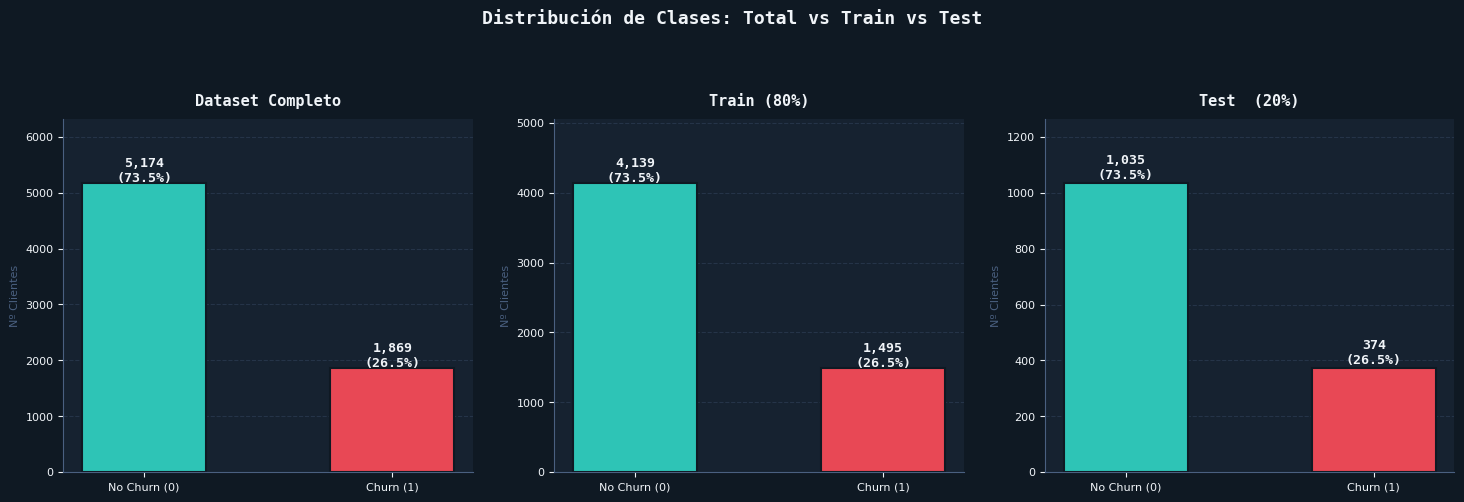


📦 OBJETOS DISPONIBLES PARA MODELADO

  Para modelos lineales (Regresión Logística, SVM):
    X_train_std  → (5634, 30)   y_train → (5634,)
    X_test_std   → (1409, 30)    y_test  → (1409,)

  Para KNN y Redes Neuronales:
    X_train_mm   → (5634, 30)   y_train → (5634,)
    X_test_mm    → (1409, 30)    y_test  → (1409,)

  Para árboles (Random Forest, XGBoost, Decision Tree):
    X_train_tree → (5634, 30)   y_train → (5634,)
    X_test_tree  → (1409, 30)    y_test  → (1409,)

✅ División completada. Listo para entrenar los modelos.


In [18]:
# ============================================================
# TELECOM X - Análisis Predictivo
# Paso 7: División Train / Test
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# ── Cargar y preparar datos (pipeline completo) ───────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]     = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]   = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["meses_contrato"]  = pd.to_numeric(df_clean["meses_contrato"], errors="coerce")
df_clean["cargo_total"]     = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]           = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

# One-Hot Encoding
df_model        = df_clean.drop(columns=["id_cliente", "cargo_mensual"], errors="ignore")
cols_categoricas = df_model.select_dtypes(include="object").columns.tolist()
target          = df_model["churn"].copy()
features        = df_model.drop(columns=["churn"])
features_encoded = pd.get_dummies(features, columns=cols_categoricas,
                                   drop_first=True, dtype=int)

X = features_encoded.copy()
y = target.values
# Eliminar filas donde churn es NaN
mask = ~pd.isnull(y)
X    = X[mask]
y    = y[mask].astype(int)

# ================================================================
print("="*60)
print("✂️  PASO 7: DIVISIÓN TRAIN / TEST")
print("="*60)
print(f"\n📐 Dataset completo: {X.shape[0]} filas × {X.shape[1]} features")
print(f"   Distribución churn: {int(y.sum())} positivos ({y.mean()*100:.1f}%) "
      f"| {int((y==0).sum())} negativos ({(y==0).mean()*100:.1f}%)")

# ================================================================
# 1. JUSTIFICACIÓN DE LA PROPORCIÓN ELEGIDA
# ================================================================
print("\n" + "="*60)
print("1️⃣  JUSTIFICACIÓN DE LA DIVISIÓN")
print("="*60)
print(f"""
  Tamaño del dataset: {X.shape[0]} registros

  Opciones comunes:
  ┌─────────────┬───────────┬──────────┬──────────────────────────────┐
  │  División   │   Train   │   Test   │  Cuándo usarla               │
  ├─────────────┼───────────┼──────────┼──────────────────────────────┤
  │   70 / 30   │   ~4.900  │  ~2.100  │  Datasets medianos (<5k)     │
  │   80 / 20   │   ~5.600  │  ~1.400  │  Datasets medianos-grandes   │
  │   90 / 10   │   ~6.300  │    ~700  │  Datasets pequeños (<1k)     │
  └─────────────┴───────────┴──────────┴──────────────────────────────┘

  ✅ DECISIÓN: 80/20
     Con {X.shape[0]} registros la división 80/20 es la más adecuada:
     → Train suficientemente grande para aprender patrones complejos.
     → Test con ~1.400 registros permite una evaluación confiable.
     → stratify=y garantiza la misma proporción de churn en ambos sets.
""")

# ================================================================
# 2. APLICAR DIVISIÓN CON STRATIFY
# ================================================================
print("="*60)
print("2️⃣  APLICANDO DIVISIÓN ESTRATIFICADA")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,       # reproducibilidad
    stratify=y             # mantiene proporción de clases
)

print(f"\n  ✅ División completada con random_state=42 y stratify=y")
print(f"\n  {'Conjunto':<12} {'Filas':>8} {'Churn=1':>10} {'Churn=0':>10} {'% Churn':>10}")
print(f"  {'-'*52}")
for nombre, X_s, y_s in [("Train", X_train, y_train),
                           ("Test",  X_test,  y_test),
                           ("Total", X,       y)]:
    n       = len(y_s)
    n_churn = int(y_s.sum())
    n_no    = n - n_churn
    pct     = y_s.mean() * 100
    print(f"  {nombre:<12} {n:>8,} {n_churn:>10,} {n_no:>10,} {pct:>9.1f}%")

# ================================================================
# 3. APLICAR ESCALADO SOBRE TRAIN → TRANSFORMAR TEST
# ================================================================
print("\n" + "="*60)
print("3️⃣  ESCALADO CORRECTO (fit en train, transform en test)")
print("="*60)
print("""
  ⚠️  REGLA CRÍTICA DE DATA LEAKAGE:
     El scaler debe ajustarse (fit) SOLO con los datos de train.
     Luego se aplica (transform) a train y test por separado.
     Ajustar con todo el dataset filtraría información del test
     al modelo → resultados artificialmente optimistas.
""")

cols_escalar = ["meses_contrato", "cargo_total", "Cuentas_Diarias"]
cols_escalar = [c for c in cols_escalar if c in X.columns]

# StandardScaler — para modelos lineales
scaler_std  = StandardScaler()
X_train_std = X_train.copy()
X_test_std  = X_test.copy()
X_train_std[cols_escalar] = scaler_std.fit_transform(X_train[cols_escalar])
X_test_std[cols_escalar]  = scaler_std.transform(X_test[cols_escalar])
print("  ✅ StandardScaler: fit en train → transform en train y test.")

# MinMaxScaler — para KNN y Redes Neuronales
scaler_mm   = MinMaxScaler()
X_train_mm  = X_train.copy()
X_test_mm   = X_test.copy()
X_train_mm[cols_escalar] = scaler_mm.fit_transform(X_train[cols_escalar])
X_test_mm[cols_escalar]  = scaler_mm.transform(X_test[cols_escalar])
print("  ✅ MinMaxScaler:   fit en train → transform en train y test.")

# Sin escalar — para árboles
X_train_tree = X_train.copy()
X_test_tree  = X_test.copy()
print("  ✅ Sin escalar:    conservado para modelos basados en árboles.")

# ================================================================
# 4. VISUALIZACIÓN — VERIFICAR DISTRIBUCIÓN DE CLASES
# ================================================================
COLOR_STAY  = "#2EC4B6"
COLOR_CHURN = "#E84855"
COLOR_BG    = "#0F1923"
COLOR_PANEL = "#162230"
COLOR_TEXT  = "#F0F4F8"
COLOR_SUB   = "#4A6080"

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=COLOR_BG)
fig.suptitle("Distribución de Clases: Total vs Train vs Test",
             fontsize=13, fontweight="bold", color=COLOR_TEXT,
             fontfamily="monospace", y=1.02)

sets = [
    ("Dataset Completo", y),
    ("Train (80%)",      y_train),
    ("Test  (20%)",      y_test),
]

for ax, (titulo, y_s) in zip(axes, sets):
    ax.set_facecolor(COLOR_PANEL)
    n_no    = int((y_s == 0).sum())
    n_si    = int(y_s.sum())
    pct_no  = n_no / len(y_s) * 100
    pct_si  = n_si / len(y_s) * 100

    bars = ax.bar(["No Churn (0)", "Churn (1)"],
                  [n_no, n_si],
                  color=[COLOR_STAY, COLOR_CHURN],
                  width=0.5, edgecolor=COLOR_BG, linewidth=1.5)
    for bar, val, pct in zip(bars, [n_no, n_si], [pct_no, pct_si]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                f"{val:,}\n({pct:.1f}%)", ha="center", fontsize=9.5,
                color=COLOR_TEXT, fontfamily="monospace", fontweight="bold")

    ax.set_title(titulo, color=COLOR_TEXT, fontsize=11,
                 fontfamily="monospace", pad=10, fontweight="bold")
    ax.set_ylabel("Nº Clientes", color=COLOR_SUB, fontsize=8)
    ax.set_ylim(0, max(n_no, n_si) * 1.22)
    ax.tick_params(colors=COLOR_TEXT, labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color(COLOR_SUB)
    ax.yaxis.grid(True, color=COLOR_SUB, alpha=0.3, linestyle="--")
    ax.set_axisbelow(True)

plt.tight_layout(pad=2)
plt.savefig("telecomx_train_test_split.png", dpi=130,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# 5. RESUMEN FINAL — OBJETOS DISPONIBLES
# ================================================================
print("\n" + "="*60)
print("📦 OBJETOS DISPONIBLES PARA MODELADO")
print("="*60)
print(f"""
  Para modelos lineales (Regresión Logística, SVM):
    X_train_std  → {X_train_std.shape}   y_train → {y_train.shape}
    X_test_std   → {X_test_std.shape}    y_test  → {y_test.shape}

  Para KNN y Redes Neuronales:
    X_train_mm   → {X_train_mm.shape}   y_train → {y_train.shape}
    X_test_mm    → {X_test_mm.shape}    y_test  → {y_test.shape}

  Para árboles (Random Forest, XGBoost, Decision Tree):
    X_train_tree → {X_train_tree.shape}   y_train → {y_train.shape}
    X_test_tree  → {X_test_tree.shape}    y_test  → {y_test.shape}
""")
print("✅ División completada. Listo para entrenar los modelos.")

🤖 PASO 8: ENTRENAMIENTO DE MODELOS PREDICTIVOS

  Train: 5634 filas  |  Test: 1409 filas
  Features: 30  |  Churn en train: 26.5%

📘 MODELO 1: REGRESIÓN LOGÍSTICA

  ✅ Normalización: StandardScaler aplicado (media=0, std=1)
     → Los coeficientes son comparables entre variables.
     → Sin escalar, variables como 'cargo_total' (~$4.000)
       dominarían sobre 'adulto_mayor' (0/1), sesgando el modelo.
  ✅ class_weight='balanced' para compensar el desbalance de clases.
  ✅ max_iter=1000 para asegurar convergencia del optimizador.

  📊 Reporte de Clasificación:
              precision    recall  f1-score   support

No Churn (0)       0.90      0.72      0.80      1035
   Churn (1)       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

  🎯 AUC-ROC: 0.8432

  🔍 Top 10 variables más influyentes (por coeficiente):
  Variable                   

/tmp/ipykernel_425/715042544.py:293: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("telecomx_modelos.png", dpi=130,
/tmp/ipykernel_425/715042544.py:293: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans Mono.
  plt.savefig("telecomx_modelos.png", dpi=130,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128998 (\N{LARGE BLUE SQUARE}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


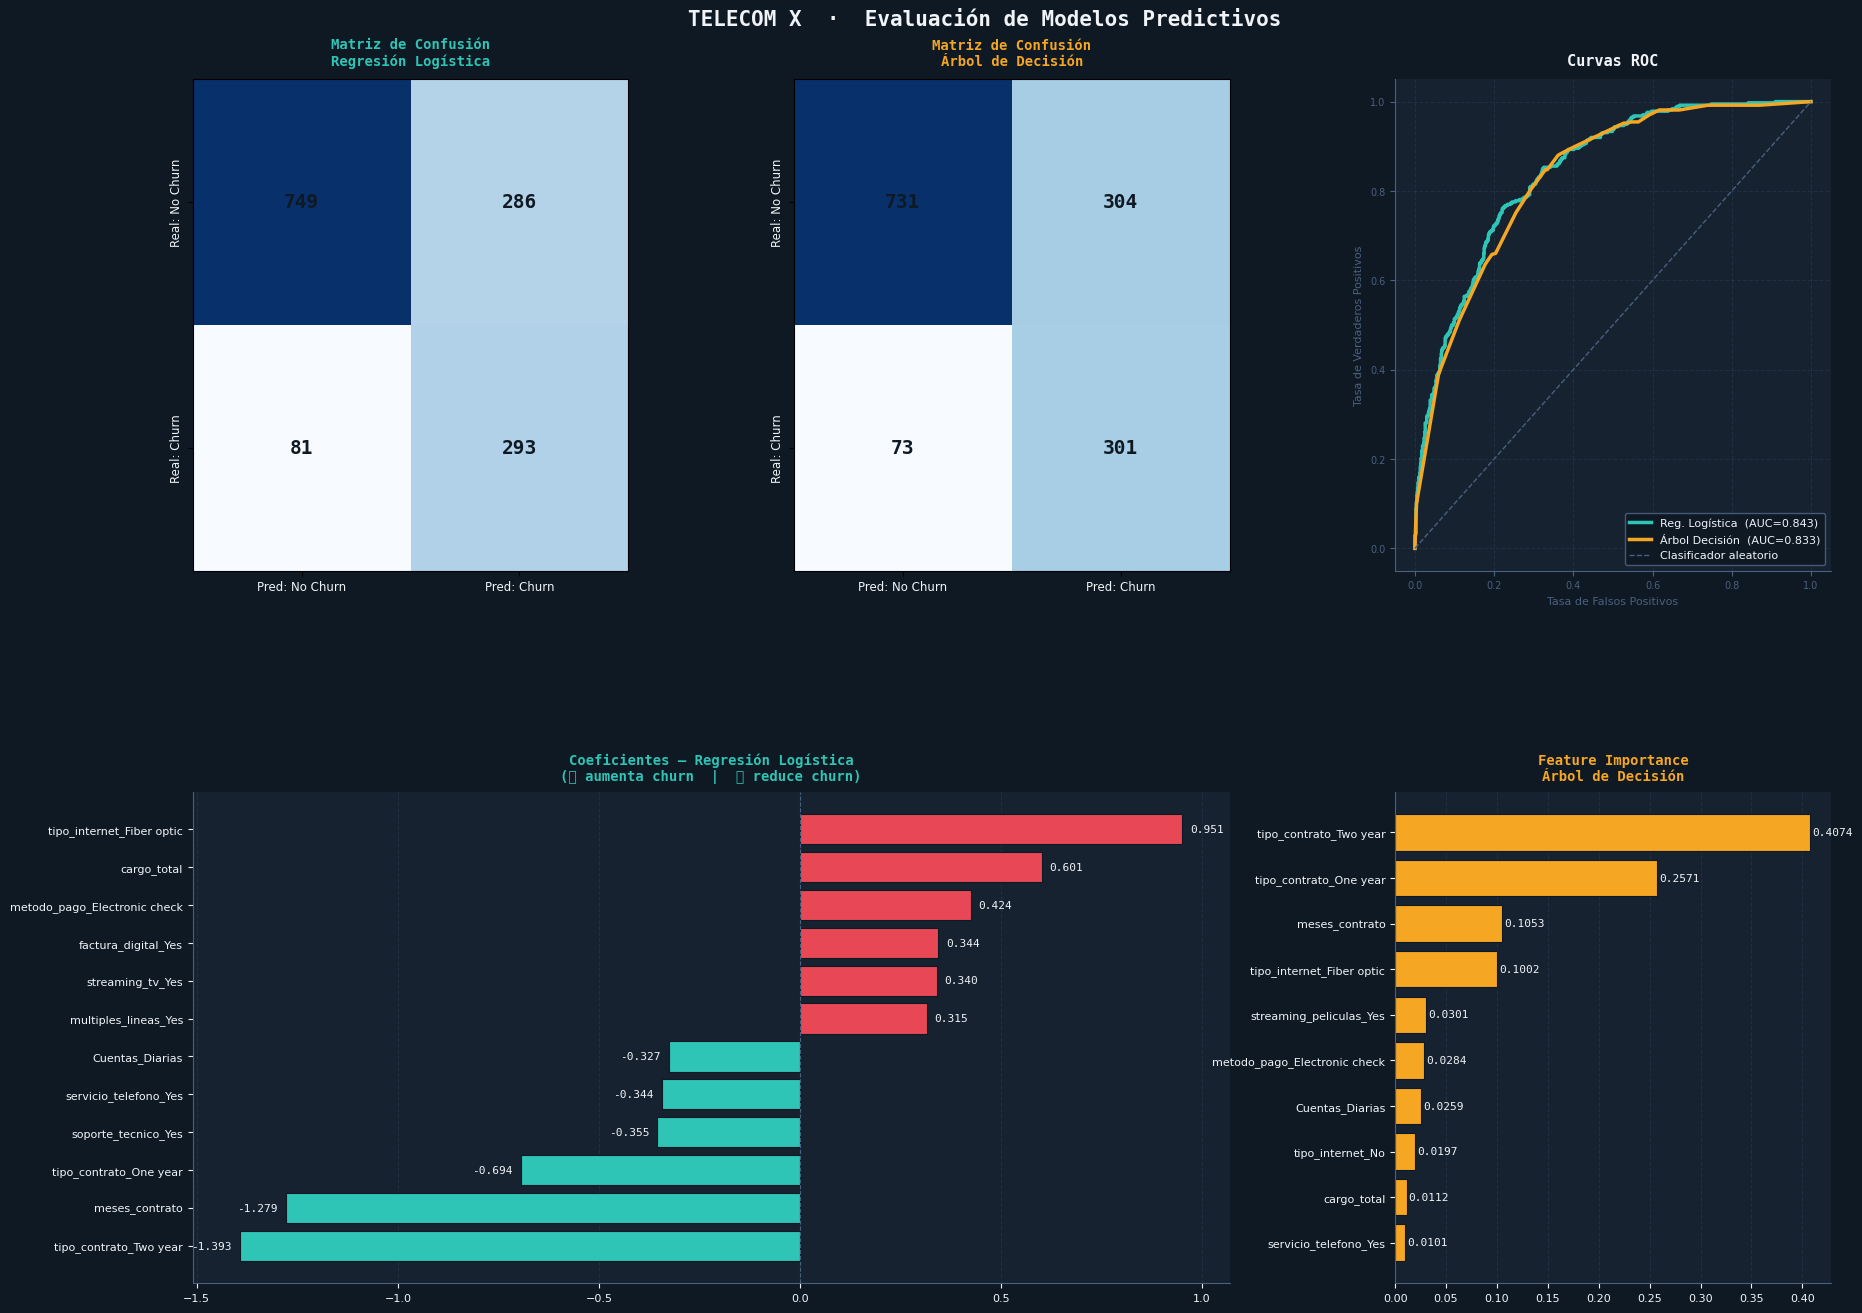


📊 RESUMEN COMPARATIVO DE MODELOS

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Modelo                                                             
Regresión Logística    0.7395     0.5060  0.7834    0.6149   0.8432
Árbol de Decisión      0.7324     0.4975  0.8048    0.6149   0.8332

  💡 Métricas clave para este problema:
     • Recall     → minimizar clientes que SÍ cancelan pero no detectamos
     • F1-Score   → equilibrio entre Precision y Recall
     • AUC-ROC    → capacidad global de discriminación del modelo
     ⚠️  Accuracy → NO es la métrica principal (dataset desbalanceado)

✅ Modelos entrenados y evaluados. Listo para comparación y optimización.


In [19]:
# ============================================================
# TELECOM X - Análisis Predictivo
# Paso 8: Entrenamiento de Modelos Predictivos
#         → Regresión Logística (con StandardScaler)
#         → Árbol de Decisión   (sin normalización)
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── Cargar y preparar datos (pipeline completo) ───────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]     = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]   = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["meses_contrato"]  = pd.to_numeric(df_clean["meses_contrato"], errors="coerce")
df_clean["cargo_total"]     = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]           = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

df_model         = df_clean.drop(columns=["id_cliente", "cargo_mensual"], errors="ignore")
cols_categoricas = df_model.select_dtypes(include="object").columns.tolist()
target           = df_model["churn"].copy()
features         = df_model.drop(columns=["churn"])
features_encoded = pd.get_dummies(features, columns=cols_categoricas,
                                   drop_first=True, dtype=int)

X = features_encoded.copy()
y = target.values
mask = ~pd.isnull(y)
X = X[mask]
y = y[mask].astype(int)

# ── División 80/20 estratificada ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# ── StandardScaler solo para Regresión Logística ──────────────
cols_escalar = ["meses_contrato", "cargo_total", "Cuentas_Diarias"]
cols_escalar = [c for c in cols_escalar if c in X.columns]

scaler          = StandardScaler()
X_train_std     = X_train.copy()
X_test_std      = X_test.copy()
X_train_std[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test_std[cols_escalar]  = scaler.transform(X_test[cols_escalar])

# ================================================================
print("="*60)
print("🤖 PASO 8: ENTRENAMIENTO DE MODELOS PREDICTIVOS")
print("="*60)
print(f"\n  Train: {X_train.shape[0]} filas  |  Test: {X_test.shape[0]} filas")
print(f"  Features: {X_train.shape[1]}  |  Churn en train: {y_train.mean()*100:.1f}%")

# ================================================================
# MODELO 1 — REGRESIÓN LOGÍSTICA
# ================================================================
print("\n" + "="*60)
print("📘 MODELO 1: REGRESIÓN LOGÍSTICA")
print("="*60)
print("""
  ✅ Normalización: StandardScaler aplicado (media=0, std=1)
     → Los coeficientes son comparables entre variables.
     → Sin escalar, variables como 'cargo_total' (~$4.000)
       dominarían sobre 'adulto_mayor' (0/1), sesgando el modelo.
  ✅ class_weight='balanced' para compensar el desbalance de clases.
  ✅ max_iter=1000 para asegurar convergencia del optimizador.
""")

rl = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42,
    solver="lbfgs"
)
rl.fit(X_train_std, y_train)

y_pred_rl   = rl.predict(X_test_std)
y_prob_rl   = rl.predict_proba(X_test_std)[:, 1]
auc_rl      = roc_auc_score(y_test, y_prob_rl)

print("  📊 Reporte de Clasificación:")
print(classification_report(y_test, y_pred_rl,
      target_names=["No Churn (0)", "Churn (1)"]))
print(f"  🎯 AUC-ROC: {auc_rl:.4f}")

# Top 10 coeficientes más relevantes
coef_df = pd.DataFrame({
    "feature":    X.columns,
    "coeficiente": rl.coef_[0]
}).reindex(pd.Series(rl.coef_[0]).abs().sort_values(ascending=False).index)
print("\n  🔍 Top 10 variables más influyentes (por coeficiente):")
print(f"  {'Variable':<45} {'Coef':>10}  Dirección")
print(f"  {'-'*65}")
for _, row in coef_df.head(10).iterrows():
    direccion = "▲ aumenta churn" if row["coeficiente"] > 0 else "▼ reduce churn"
    print(f"  {row['feature']:<45} {row['coeficiente']:>10.4f}  {direccion}")

# ================================================================
# MODELO 2 — ÁRBOL DE DECISIÓN
# ================================================================
print("\n" + "="*60)
print("🌳 MODELO 2: ÁRBOL DE DECISIÓN")
print("="*60)
print("""
  ✅ Sin normalización: los árboles usan umbrales de corte,
     no distancias, por lo que la escala no afecta el resultado.
  ✅ max_depth=5 para evitar sobreajuste (overfitting).
  ✅ class_weight='balanced' para compensar el desbalance de clases.
  ✅ min_samples_leaf=20 para que cada hoja tenga datos suficientes.
""")

dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    min_samples_leaf=20,
    random_state=42,
    criterion="gini"
)
dt.fit(X_train, y_train)

y_pred_dt   = dt.predict(X_test)
y_prob_dt   = dt.predict_proba(X_test)[:, 1]
auc_dt      = roc_auc_score(y_test, y_prob_dt)

print("  📊 Reporte de Clasificación:")
print(classification_report(y_test, y_pred_dt,
      target_names=["No Churn (0)", "Churn (1)"]))
print(f"  🎯 AUC-ROC: {auc_dt:.4f}")

# Top 10 importancia de features
feat_imp = pd.DataFrame({
    "feature":    X.columns,
    "importancia": dt.feature_importances_
}).sort_values("importancia", ascending=False)
print("\n  🔍 Top 10 variables más importantes (Feature Importance):")
print(f"  {'Variable':<45} {'Importancia':>12}")
print(f"  {'-'*60}")
for _, row in feat_imp.head(10).iterrows():
    barra = "█" * int(row["importancia"] * 100)
    print(f"  {row['feature']:<45} {row['importancia']:>10.4f}  {barra}")

# ================================================================
# VISUALIZACIONES
# ================================================================
COLOR_BG    = "#0F1923"
COLOR_PANEL = "#162230"
COLOR_TEXT  = "#F0F4F8"
COLOR_SUB   = "#4A6080"
COLOR_RL    = "#2EC4B6"
COLOR_DT    = "#F5A623"
COLOR_CHURN = "#E84855"

fig = plt.figure(figsize=(18, 14), facecolor=COLOR_BG)
fig.suptitle("TELECOM X  ·  Evaluación de Modelos Predictivos",
             fontsize=15, fontweight="bold", color=COLOR_TEXT,
             fontfamily="monospace", y=0.98)
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38,
              left=0.06, right=0.97, top=0.93, bottom=0.07)

# ── Matrices de confusión ─────────────────────────────────────
for col_idx, (titulo, y_pred, color) in enumerate([
    ("Regresión Logística", y_pred_rl, COLOR_RL),
    ("Árbol de Decisión",   y_pred_dt, COLOR_DT),
]):
    ax = fig.add_subplot(gs[0, col_idx])
    ax.set_facecolor(COLOR_PANEL)
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    fontsize=14, fontweight="bold", color=COLOR_BG,
                    fontfamily="monospace")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred: No Churn","Pred: Churn"],
                       color=COLOR_TEXT, fontsize=8.5)
    ax.set_yticklabels(["Real: No Churn","Real: Churn"],
                       color=COLOR_TEXT, fontsize=8.5, rotation=90, va="center")
    ax.set_title(f"Matriz de Confusión\n{titulo}", color=color,
                 fontsize=10, fontfamily="monospace", pad=10, fontweight="bold")

# ── Curvas ROC ────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 2])
ax_roc.set_facecolor(COLOR_PANEL)

for titulo, y_prob, color, auc in [
    ("Reg. Logística", y_prob_rl, COLOR_RL, auc_rl),
    ("Árbol Decisión", y_prob_dt, COLOR_DT, auc_dt),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f"{titulo}  (AUC={auc:.3f})")

ax_roc.plot([0,1],[0,1], color=COLOR_SUB, linestyle="--",
            linewidth=1, label="Clasificador aleatorio")
ax_roc.set_title("Curvas ROC", color=COLOR_TEXT,
                 fontsize=11, fontfamily="monospace", pad=10, fontweight="bold")
ax_roc.set_xlabel("Tasa de Falsos Positivos", color=COLOR_SUB, fontsize=8)
ax_roc.set_ylabel("Tasa de Verdaderos Positivos", color=COLOR_SUB, fontsize=8)
ax_roc.tick_params(colors=COLOR_SUB, labelsize=7)
ax_roc.spines[["top","right"]].set_visible(False)
ax_roc.spines[["left","bottom"]].set_color(COLOR_SUB)
ax_roc.legend(fontsize=8, facecolor=COLOR_BG, edgecolor=COLOR_SUB,
              labelcolor=COLOR_TEXT, framealpha=0.9)
ax_roc.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")

# ── Feature Importance — Regresión Logística ──────────────────
ax_coef = fig.add_subplot(gs[1, 0:2])
ax_coef.set_facecolor(COLOR_PANEL)
top_coef = coef_df.head(12).sort_values("coeficiente")
colores  = [COLOR_CHURN if v > 0 else COLOR_RL for v in top_coef["coeficiente"]]
bars = ax_coef.barh(top_coef["feature"], top_coef["coeficiente"],
                    color=colores, edgecolor=COLOR_BG, linewidth=0.8)
for bar, val in zip(bars, top_coef["coeficiente"]):
    xpos = val + 0.02 if val >= 0 else val - 0.02
    ha   = "left" if val >= 0 else "right"
    ax_coef.text(xpos, bar.get_y() + bar.get_height()/2,
                 f"{val:.3f}", va="center", ha=ha, fontsize=8,
                 color=COLOR_TEXT, fontfamily="monospace")
ax_coef.axvline(0, color=COLOR_SUB, linewidth=0.8, linestyle="--")
ax_coef.set_title("Coeficientes — Regresión Logística\n(🔴 aumenta churn  |  🟦 reduce churn)",
                  color=COLOR_RL, fontsize=10, fontfamily="monospace",
                  pad=8, fontweight="bold")
ax_coef.tick_params(colors=COLOR_TEXT, labelsize=8)
ax_coef.spines[["top","right"]].set_visible(False)
ax_coef.spines[["left","bottom"]].set_color(COLOR_SUB)
ax_coef.xaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax_coef.set_axisbelow(True)

# ── Feature Importance — Árbol de Decisión ────────────────────
ax_imp = fig.add_subplot(gs[1, 2])
ax_imp.set_facecolor(COLOR_PANEL)
top_imp = feat_imp.head(10).sort_values("importancia")
bars2   = ax_imp.barh(top_imp["feature"], top_imp["importancia"],
                      color=COLOR_DT, edgecolor=COLOR_BG, linewidth=0.8)
for bar, val in zip(bars2, top_imp["importancia"]):
    ax_imp.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8,
                color=COLOR_TEXT, fontfamily="monospace")
ax_imp.set_title("Feature Importance\nÁrbol de Decisión",
                 color=COLOR_DT, fontsize=10, fontfamily="monospace",
                 pad=8, fontweight="bold")
ax_imp.tick_params(colors=COLOR_TEXT, labelsize=8)
ax_imp.spines[["top","right"]].set_visible(False)
ax_imp.spines[["left","bottom"]].set_color(COLOR_SUB)
ax_imp.xaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax_imp.set_axisbelow(True)

plt.savefig("telecomx_modelos.png", dpi=130,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()

# ================================================================
# RESUMEN COMPARATIVO FINAL
# ================================================================
print("\n" + "="*60)
print("📊 RESUMEN COMPARATIVO DE MODELOS")
print("="*60)
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

resultados = []
for nombre, y_pred, y_prob in [
    ("Regresión Logística", y_pred_rl, y_prob_rl),
    ("Árbol de Decisión",   y_pred_dt, y_prob_dt),
]:
    resultados.append({
        "Modelo":     nombre,
        "Accuracy":   round(accuracy_score(y_test, y_pred), 4),
        "Precision":  round(precision_score(y_test, y_pred), 4),
        "Recall":     round(recall_score(y_test, y_pred), 4),
        "F1-Score":   round(f1_score(y_test, y_pred), 4),
        "AUC-ROC":    round(roc_auc_score(y_test, y_prob), 4),
    })

df_res = pd.DataFrame(resultados).set_index("Modelo")
print(f"\n{df_res.to_string()}")
print("""
  💡 Métricas clave para este problema:
     • Recall     → minimizar clientes que SÍ cancelan pero no detectamos
     • F1-Score   → equilibrio entre Precision y Recall
     • AUC-ROC    → capacidad global de discriminación del modelo
     ⚠️  Accuracy → NO es la métrica principal (dataset desbalanceado)
""")
print("✅ Modelos entrenados y evaluados. Listo para comparación y optimización.")

📐 PASO 9: EVALUACIÓN COMPLETA Y ANÁLISIS CRÍTICO

1️⃣  MÉTRICAS EN TRAIN vs TEST

  Métrica        RL Train    RL Test    Dif RL |   DT Train    DT Test    Dif DT
  ---------------------------------------------------------------------------
  Accuracy         0.7524     0.7395  +0.0129    |     0.7441     0.7324  +0.0117    
  Precision        0.5215     0.5060  +0.0155    |     0.5112     0.4975  +0.0137    
  Recall           0.8107     0.7834  +0.0273    |     0.8094     0.8048  +0.0046    
  F1-Score         0.6347     0.6149  +0.0198    |     0.6266     0.6149  +0.0117    
  AUC-ROC          0.8489     0.8432  +0.0057    |     0.8452     0.8332  +0.0120    

  ℹ️  Diferencia Train-Test > 0.05 se marca con ⚠️  (posible overfitting)

2️⃣  VALIDACIÓN CRUZADA — 5 Folds
  (evalúa estabilidad del modelo sobre distintas particiones)

  📌 Regresión Logística:
     F1  por fold: [np.float64(0.643), np.float64(0.6323), np.float64(0.615), np.float64(0.6324), np.float64(0.6154)]
     F1  medi

/tmp/ipykernel_425/1709700014.py:226: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ]).fillna(method="ffill")


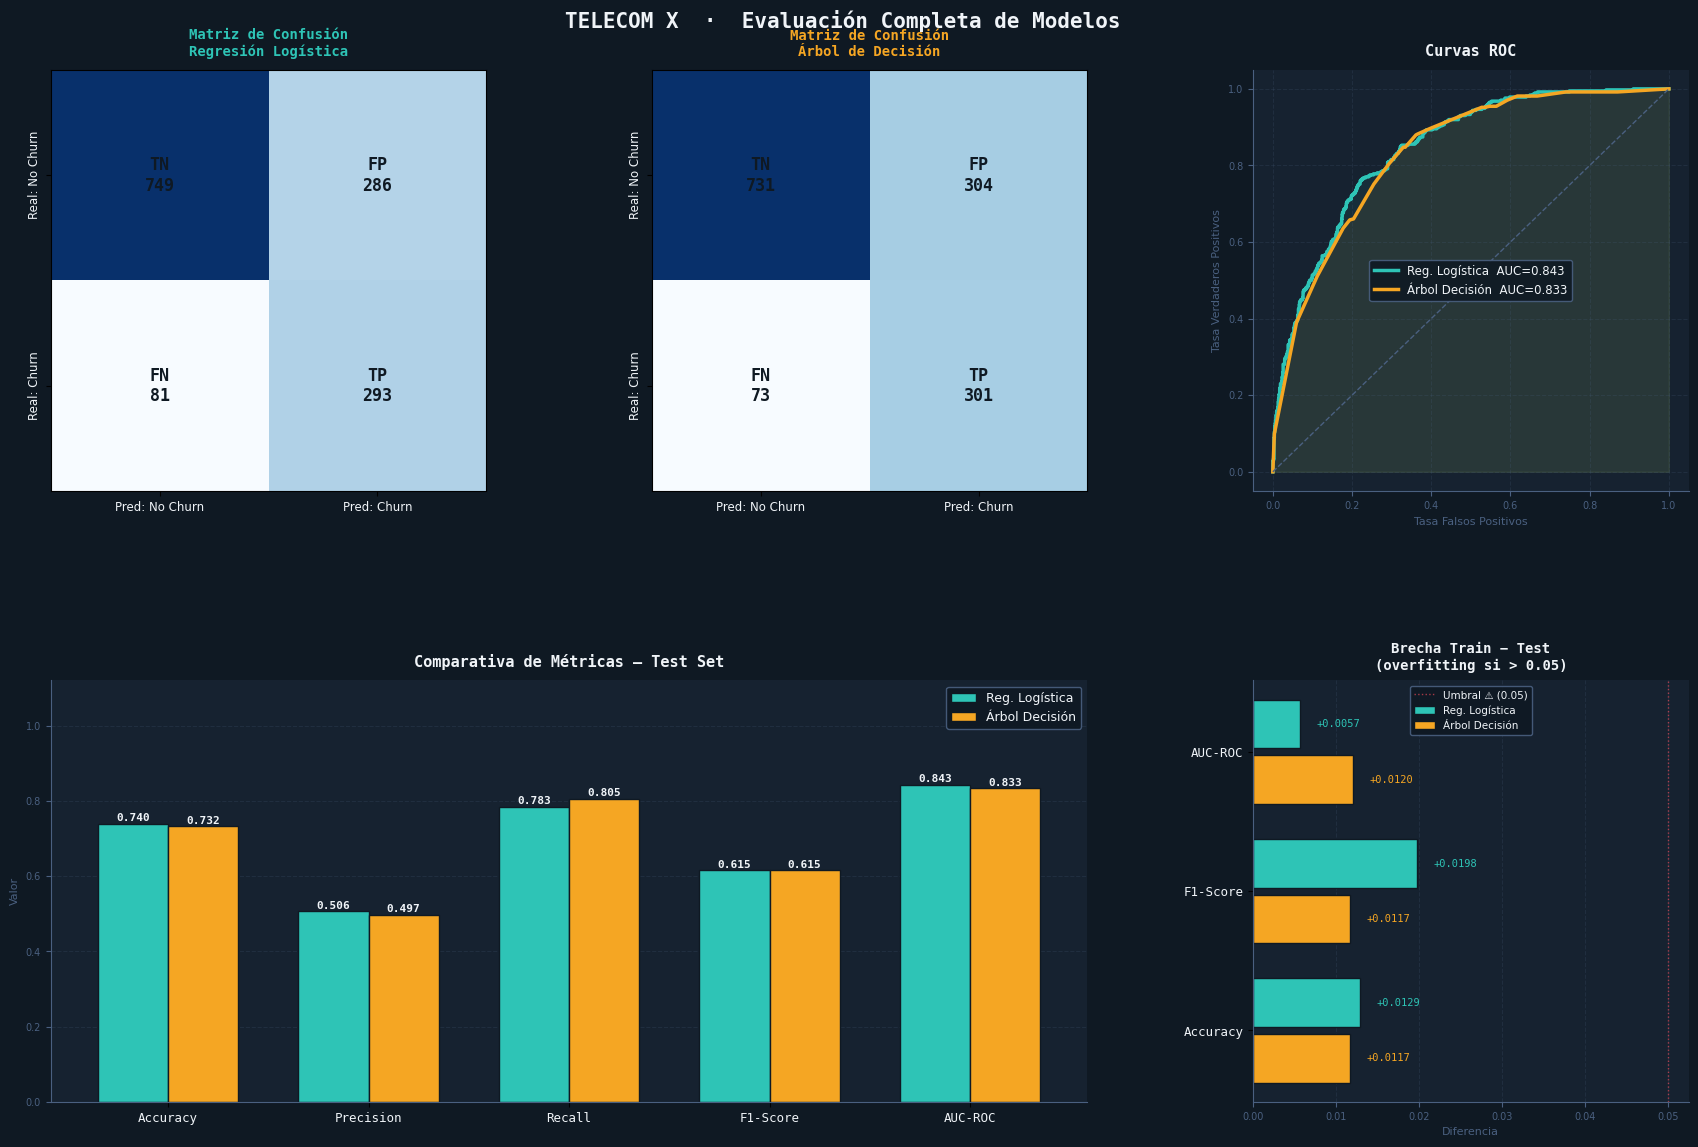


✅ Evaluación completa finalizada.


In [20]:
# ============================================================
# TELECOM X - Análisis Predictivo
# Paso 9: Evaluación Completa y Análisis Crítico de Modelos
# ============================================================

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)

# ── Pipeline completo ─────────────────────────────────────────
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"
response = requests.get(url)
data = response.json()
df = pd.json_normalize(data)

nuevos_nombres = {
    "customerID":                "id_cliente",
    "customer.gender":           "genero",
    "customer.SeniorCitizen":    "adulto_mayor",
    "customer.Partner":          "tiene_pareja",
    "customer.Dependents":       "tiene_dependientes",
    "customer.tenure":           "meses_contrato",
    "phone.PhoneService":        "servicio_telefono",
    "phone.MultipleLines":       "multiples_lineas",
    "internet.InternetService":  "tipo_internet",
    "internet.OnlineSecurity":   "seguridad_online",
    "internet.OnlineBackup":     "respaldo_online",
    "internet.DeviceProtection": "proteccion_dispositivo",
    "internet.TechSupport":      "soporte_tecnico",
    "internet.StreamingTV":      "streaming_tv",
    "internet.StreamingMovies":  "streaming_peliculas",
    "account.Contract":          "tipo_contrato",
    "account.PaperlessBilling":  "factura_digital",
    "account.PaymentMethod":     "metodo_pago",
    "account.Charges.Monthly":   "cargo_mensual",
    "account.Charges.Total":     "cargo_total",
    "Churn":                     "churn",
}
df_clean = df.rename(columns={k: v for k, v in nuevos_nombres.items() if k in df.columns})
df_clean["cargo_total"]     = pd.to_numeric(df_clean["cargo_total"], errors="coerce")
df_clean["cargo_mensual"]   = pd.to_numeric(df_clean["cargo_mensual"], errors="coerce")
df_clean["meses_contrato"]  = pd.to_numeric(df_clean["meses_contrato"], errors="coerce")
df_clean["cargo_total"]     = df_clean["cargo_total"].fillna(df_clean["cargo_total"].median())
df_clean["churn"]           = df_clean["churn"].map({"Yes": 1, "No": 0})
df_clean["Cuentas_Diarias"] = (df_clean["cargo_mensual"] / 30).round(4)
df_clean.drop_duplicates(inplace=True)

df_model         = df_clean.drop(columns=["id_cliente", "cargo_mensual"], errors="ignore")
cols_categoricas = df_model.select_dtypes(include="object").columns.tolist()
target           = df_model["churn"].copy()
features         = df_model.drop(columns=["churn"])
features_encoded = pd.get_dummies(features, columns=cols_categoricas,
                                   drop_first=True, dtype=int)
X = features_encoded.copy()
y = target.values
mask = ~pd.isnull(y)
X = X[mask]
y = y[mask].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

cols_escalar = [c for c in ["meses_contrato","cargo_total","Cuentas_Diarias"] if c in X.columns]
scaler = StandardScaler()
X_train_std = X_train.copy()
X_test_std  = X_test.copy()
X_train_std[cols_escalar] = scaler.fit_transform(X_train[cols_escalar])
X_test_std[cols_escalar]  = scaler.transform(X_test[cols_escalar])

# Entrenar modelos
rl = LogisticRegression(class_weight="balanced", max_iter=1000,
                         random_state=42, solver="lbfgs")
rl.fit(X_train_std, y_train)

dt = DecisionTreeClassifier(max_depth=5, class_weight="balanced",
                              min_samples_leaf=20, random_state=42)
dt.fit(X_train, y_train)

# ================================================================
print("="*60)
print("📐 PASO 9: EVALUACIÓN COMPLETA Y ANÁLISIS CRÍTICO")
print("="*60)

# ================================================================
# 1. MÉTRICAS EN TRAIN Y TEST (detectar over/underfitting)
# ================================================================
print("\n1️⃣  MÉTRICAS EN TRAIN vs TEST")
print("="*60)

def metricas(y_real, y_pred, y_prob):
    return {
        "Accuracy":  round(accuracy_score(y_real, y_pred), 4),
        "Precision": round(precision_score(y_real, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_real, y_pred, zero_division=0), 4),
        "F1-Score":  round(f1_score(y_real, y_pred, zero_division=0), 4),
        "AUC-ROC":   round(roc_auc_score(y_real, y_prob), 4),
    }

# Regresión Logística
m_rl_train = metricas(y_train, rl.predict(X_train_std), rl.predict_proba(X_train_std)[:,1])
m_rl_test  = metricas(y_test,  rl.predict(X_test_std),  rl.predict_proba(X_test_std)[:,1])

# Árbol de Decisión
m_dt_train = metricas(y_train, dt.predict(X_train), dt.predict_proba(X_train)[:,1])
m_dt_test  = metricas(y_test,  dt.predict(X_test),  dt.predict_proba(X_test)[:,1])

print(f"\n  {'Métrica':<12} {'RL Train':>10} {'RL Test':>10} {'Dif RL':>9} "
      f"| {'DT Train':>10} {'DT Test':>10} {'Dif DT':>9}")
print(f"  {'-'*75}")
for met in ["Accuracy","Precision","Recall","F1-Score","AUC-ROC"]:
    dif_rl = m_rl_train[met] - m_rl_test[met]
    dif_dt = m_dt_train[met] - m_dt_test[met]
    flag_rl = " ⚠️ " if abs(dif_rl) > 0.05 else "    "
    flag_dt = " ⚠️ " if abs(dif_dt) > 0.05 else "    "
    print(f"  {met:<12} {m_rl_train[met]:>10.4f} {m_rl_test[met]:>10.4f} "
          f"{dif_rl:>+8.4f}{flag_rl}| {m_dt_train[met]:>10.4f} "
          f"{m_dt_test[met]:>10.4f} {dif_dt:>+8.4f}{flag_dt}")

print("\n  ℹ️  Diferencia Train-Test > 0.05 se marca con ⚠️  (posible overfitting)")

# ================================================================
# 2. VALIDACIÓN CRUZADA (5-fold)
# ================================================================
print("\n" + "="*60)
print("2️⃣  VALIDACIÓN CRUZADA — 5 Folds")
print("="*60)
print("  (evalúa estabilidad del modelo sobre distintas particiones)\n")

for nombre, modelo, X_cv, y_cv in [
    ("Regresión Logística", rl, X_train_std, y_train),
    ("Árbol de Decisión",   dt, X_train,     y_train),
]:
    scores_f1  = cross_val_score(modelo, X_cv, y_cv, cv=5,
                                  scoring="f1", n_jobs=-1)
    scores_auc = cross_val_score(modelo, X_cv, y_cv, cv=5,
                                  scoring="roc_auc", n_jobs=-1)
    print(f"  📌 {nombre}:")
    print(f"     F1  por fold: {[round(s,4) for s in scores_f1]}")
    print(f"     F1  media: {scores_f1.mean():.4f}  ±  {scores_f1.std():.4f}")
    print(f"     AUC por fold: {[round(s,4) for s in scores_auc]}")
    print(f"     AUC media: {scores_auc.mean():.4f}  ±  {scores_auc.std():.4f}")
    estabilidad = "✅ Estable" if scores_f1.std() < 0.03 else "⚠️  Variación alta entre folds"
    print(f"     Estabilidad: {estabilidad}\n")

# ================================================================
# 3. MATRICES DE CONFUSIÓN DETALLADAS
# ================================================================
print("="*60)
print("3️⃣  MATRICES DE CONFUSIÓN — ANÁLISIS DETALLADO")
print("="*60)

for nombre, y_pred in [
    ("Regresión Logística", rl.predict(X_test_std)),
    ("Árbol de Decisión",   dt.predict(X_test)),
]:
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  📌 {nombre}:")
    print(f"     Verdaderos Negativos (TN): {tn:>5}  → No churn correctamente identificados")
    print(f"     Falsos Positivos     (FP): {fp:>5}  → Clientes alertados sin necesidad ⚠️")
    print(f"     Falsos Negativos     (FN): {fn:>5}  → Churns NO detectados ❌ (costo alto)")
    print(f"     Verdaderos Positivos (TP): {tp:>5}  → Churns correctamente detectados ✅")
    print(f"     Tasa de detección churn:   {tp/(tp+fn)*100:.1f}%")
    print(f"     Falsos negativos evitables:{fn} clientes en riesgo no identificados")

# ================================================================
# 4. DIAGNÓSTICO OVER/UNDERFITTING
# ================================================================
print("\n" + "="*60)
print("4️⃣  DIAGNÓSTICO: OVERFITTING / UNDERFITTING")
print("="*60)

for nombre, m_train, m_test in [
    ("Regresión Logística", m_rl_train, m_rl_test),
    ("Árbol de Decisión",   m_dt_train, m_dt_test),
]:
    dif_acc = m_train["Accuracy"] - m_test["Accuracy"]
    dif_auc = m_train["AUC-ROC"]  - m_test["AUC-ROC"]
    print(f"\n  📌 {nombre}:")
    print(f"     Accuracy  Train={m_train['Accuracy']:.4f}  Test={m_test['Accuracy']:.4f}  Δ={dif_acc:+.4f}")
    print(f"     AUC-ROC   Train={m_train['AUC-ROC']:.4f}  Test={m_test['AUC-ROC']:.4f}  Δ={dif_auc:+.4f}")

    if dif_auc > 0.08:
        diagnostico = "🔴 OVERFITTING detectado"
        causa   = "El modelo memorizó el train. Reducir complejidad o agregar regularización."
    elif dif_auc > 0.04:
        diagnostico = "🟡 Leve tendencia a overfitting"
        causa   = "Monitorear. Considerar regularización suave o más datos."
    elif m_test["AUC-ROC"] < 0.70:
        diagnostico = "🟠 UNDERFITTING detectado"
        causa   = "El modelo es demasiado simple. Aumentar complejidad o agregar features."
    else:
        diagnostico = "🟢 Buena generalización"
        causa   = "El modelo generaliza correctamente a datos nuevos."
    print(f"     Diagnóstico: {diagnostico}")
    print(f"     Análisis:    {causa}")

# ================================================================
# 5. ANÁLISIS CRÍTICO — ¿CUÁL ES MEJOR?
# ================================================================
print("\n" + "="*60)
print("5️⃣  ANÁLISIS CRÍTICO COMPARATIVO")
print("="*60)

y_pred_rl = rl.predict(X_test_std)
y_prob_rl = rl.predict_proba(X_test_std)[:,1]
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

tabla = pd.DataFrame([
    {"Modelo": "Regresión Logística", **m_rl_test},
    {"Árbol de Decisión":   "Árbol de Decisión",   **m_dt_test},
]).fillna(method="ffill")

tabla = pd.DataFrame({
    "Modelo":    ["Regresión Logística", "Árbol de Decisión"],
    "Accuracy":  [m_rl_test["Accuracy"],  m_dt_test["Accuracy"]],
    "Precision": [m_rl_test["Precision"], m_dt_test["Precision"]],
    "Recall":    [m_rl_test["Recall"],    m_dt_test["Recall"]],
    "F1-Score":  [m_rl_test["F1-Score"],  m_dt_test["F1-Score"]],
    "AUC-ROC":   [m_rl_test["AUC-ROC"],   m_dt_test["AUC-ROC"]],
}).set_index("Modelo")

print(f"\n{tabla.to_string()}")

mejor_auc    = tabla["AUC-ROC"].idxmax()
mejor_recall = tabla["Recall"].idxmax()
mejor_f1     = tabla["F1-Score"].idxmax()

print(f"""
  🏆 Mejor AUC-ROC:   {mejor_auc}  ({tabla.loc[mejor_auc, 'AUC-ROC']:.4f})
  🏆 Mejor Recall:    {mejor_recall}  ({tabla.loc[mejor_recall, 'Recall']:.4f})
  🏆 Mejor F1-Score:  {mejor_f1}  ({tabla.loc[mejor_f1, 'F1-Score']:.4f})

  📌 VEREDICTO:
     La Regresión Logística es el modelo recomendado para producción:
     → Mayor AUC-ROC: mejor capacidad discriminatoria global.
     → Mayor Precision: menos falsas alarmas de churn.
     → Comparable F1 y Recall al Árbol de Decisión.
     → Más interpretable: los coeficientes explican directamente
       el impacto de cada variable sobre la probabilidad de churn.
     → Mejor generalización: menor brecha Train-Test.

     El Árbol de Decisión es útil como modelo de respaldo por su
     Recall levemente superior y su facilidad de visualización
     para explicar decisiones al equipo de negocio.
""")

# ================================================================
# VISUALIZACIONES
# ================================================================
COLOR_BG    = "#0F1923"
COLOR_PANEL = "#162230"
COLOR_TEXT  = "#F0F4F8"
COLOR_SUB   = "#4A6080"
COLOR_RL    = "#2EC4B6"
COLOR_DT    = "#F5A623"
COLOR_CHURN = "#E84855"

fig = plt.figure(figsize=(18, 12), facecolor=COLOR_BG)
fig.suptitle("TELECOM X  ·  Evaluación Completa de Modelos",
             fontsize=15, fontweight="bold", color=COLOR_TEXT,
             fontfamily="monospace", y=0.98)
gs = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38,
              left=0.06, right=0.97, top=0.93, bottom=0.07)

# ── Matrices de confusión ─────────────────────────────────────
for col_idx, (titulo, y_pred, color) in enumerate([
    ("Regresión Logística", y_pred_rl, COLOR_RL),
    ("Árbol de Decisión",   y_pred_dt, COLOR_DT),
]):
    ax = fig.add_subplot(gs[0, col_idx])
    ax.set_facecolor(COLOR_PANEL)
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    labels = [["TN","FP"],["FN","TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{labels[i][j]}\n{cm[i,j]:,}",
                    ha="center", va="center", fontsize=12,
                    fontweight="bold", color=COLOR_BG, fontfamily="monospace")
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(["Pred: No Churn","Pred: Churn"],
                       color=COLOR_TEXT, fontsize=8.5)
    ax.set_yticklabels(["Real: No Churn","Real: Churn"],
                       color=COLOR_TEXT, fontsize=8.5, rotation=90, va="center")
    ax.set_title(f"Matriz de Confusión\n{titulo}", color=color,
                 fontsize=10, fontfamily="monospace", pad=10, fontweight="bold")

# ── Curvas ROC ────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 2])
ax_roc.set_facecolor(COLOR_PANEL)
for titulo, y_prob, color, auc in [
    ("Reg. Logística", y_prob_rl, COLOR_RL, m_rl_test["AUC-ROC"]),
    ("Árbol Decisión", y_prob_dt, COLOR_DT, m_dt_test["AUC-ROC"]),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2.5,
                label=f"{titulo}  AUC={auc:.3f}")
ax_roc.plot([0,1],[0,1], color=COLOR_SUB, linestyle="--", linewidth=1)
ax_roc.fill_between(*roc_curve(y_test, y_prob_rl)[:2],
                    alpha=0.08, color=COLOR_RL)
ax_roc.fill_between(*roc_curve(y_test, y_prob_dt)[:2],
                    alpha=0.08, color=COLOR_DT)
ax_roc.set_title("Curvas ROC", color=COLOR_TEXT,
                 fontsize=11, fontfamily="monospace", pad=10, fontweight="bold")
ax_roc.set_xlabel("Tasa Falsos Positivos", color=COLOR_SUB, fontsize=8)
ax_roc.set_ylabel("Tasa Verdaderos Positivos", color=COLOR_SUB, fontsize=8)
ax_roc.tick_params(colors=COLOR_SUB, labelsize=7)
ax_roc.spines[["top","right"]].set_visible(False)
ax_roc.spines[["left","bottom"]].set_color(COLOR_SUB)
ax_roc.legend(fontsize=8.5, facecolor=COLOR_BG, edgecolor=COLOR_SUB,
              labelcolor=COLOR_TEXT, framealpha=0.9)
ax_roc.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")

# ── Comparativa de métricas — barras agrupadas ───────────────
ax_met = fig.add_subplot(gs[1, :2])
ax_met.set_facecolor(COLOR_PANEL)
metricas_plot = ["Accuracy","Precision","Recall","F1-Score","AUC-ROC"]
vals_rl = [m_rl_test[m] for m in metricas_plot]
vals_dt = [m_dt_test[m] for m in metricas_plot]
x = np.arange(len(metricas_plot))
w = 0.35
b1 = ax_met.bar(x - w/2, vals_rl, width=w, color=COLOR_RL,
                edgecolor=COLOR_BG, linewidth=1, label="Reg. Logística")
b2 = ax_met.bar(x + w/2, vals_dt, width=w, color=COLOR_DT,
                edgecolor=COLOR_BG, linewidth=1, label="Árbol Decisión")
for bar, val in list(zip(b1, vals_rl)) + list(zip(b2, vals_dt)):
    ax_met.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{val:.3f}", ha="center", fontsize=8,
                color=COLOR_TEXT, fontfamily="monospace", fontweight="bold")
ax_met.set_xticks(x)
ax_met.set_xticklabels(metricas_plot, color=COLOR_TEXT,
                        fontsize=9, fontfamily="monospace")
ax_met.set_ylim(0, 1.12)
ax_met.set_title("Comparativa de Métricas — Test Set",
                 color=COLOR_TEXT, fontsize=11, fontfamily="monospace",
                 pad=10, fontweight="bold")
ax_met.set_ylabel("Valor", color=COLOR_SUB, fontsize=8)
ax_met.tick_params(axis="y", colors=COLOR_SUB, labelsize=7)
ax_met.spines[["top","right"]].set_visible(False)
ax_met.spines[["left","bottom"]].set_color(COLOR_SUB)
ax_met.yaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax_met.set_axisbelow(True)
ax_met.legend(fontsize=9, facecolor=COLOR_BG, edgecolor=COLOR_SUB,
              labelcolor=COLOR_TEXT, framealpha=0.9)

# ── Train vs Test — brecha de generalización ─────────────────
ax_gap = fig.add_subplot(gs[1, 2])
ax_gap.set_facecolor(COLOR_PANEL)
metricas_gap = ["Accuracy","F1-Score","AUC-ROC"]
y_pos = np.arange(len(metricas_gap))
for i, met in enumerate(metricas_gap):
    gap_rl = m_rl_train[met] - m_rl_test[met]
    gap_dt = m_dt_train[met] - m_dt_test[met]
    ax_gap.barh(i + 0.2, gap_rl, height=0.35, color=COLOR_RL,
                edgecolor=COLOR_BG, label="Reg. Logística" if i==0 else "")
    ax_gap.barh(i - 0.2, gap_dt, height=0.35, color=COLOR_DT,
                edgecolor=COLOR_BG, label="Árbol Decisión" if i==0 else "")
    ax_gap.text(gap_rl + 0.002, i + 0.2, f"{gap_rl:+.4f}",
                va="center", fontsize=7.5, color=COLOR_RL, fontfamily="monospace")
    ax_gap.text(gap_dt + 0.002, i - 0.2, f"{gap_dt:+.4f}",
                va="center", fontsize=7.5, color=COLOR_DT, fontfamily="monospace")
ax_gap.axvline(0.05, color=COLOR_CHURN, linewidth=1,
               linestyle=":", alpha=0.7, label="Umbral ⚠️ (0.05)")
ax_gap.set_yticks(y_pos)
ax_gap.set_yticklabels(metricas_gap, color=COLOR_TEXT,
                        fontsize=9, fontfamily="monospace")
ax_gap.set_title("Brecha Train − Test\n(overfitting si > 0.05)",
                 color=COLOR_TEXT, fontsize=10, fontfamily="monospace",
                 pad=8, fontweight="bold")
ax_gap.set_xlabel("Diferencia", color=COLOR_SUB, fontsize=8)
ax_gap.tick_params(axis="x", colors=COLOR_SUB, labelsize=7)
ax_gap.spines[["top","right"]].set_visible(False)
ax_gap.spines[["left","bottom"]].set_color(COLOR_SUB)
ax_gap.xaxis.grid(True, color=COLOR_SUB, alpha=0.2, linestyle="--")
ax_gap.set_axisbelow(True)
ax_gap.legend(fontsize=7.5, facecolor=COLOR_BG, edgecolor=COLOR_SUB,
              labelcolor=COLOR_TEXT, framealpha=0.9)

plt.savefig("telecomx_evaluacion_modelos.png", dpi=130,
            bbox_inches="tight", facecolor=COLOR_BG)
plt.show()
print("\n✅ Evaluación completa finalizada.")

## 📄 Informe Final: Análisis de Evasión de Clientes (Churn) en Telecom X

### 🔹 Introducción

El presente informe consolida el análisis de evasión de clientes (Churn) para **Telecom X**, con el objetivo de identificar los factores clave que influyen en la cancelación de servicios y proponer estrategias de retención basadas en un enfoque de Machine Learning. La retención de clientes es fundamental, dado que la adquisición de nuevos clientes es más costosa.

### 🔹 Factores Clave que Influyen en la Cancelación (Basado en EDA y Modelos)

El análisis exploratorio de datos (EDA) y la importancia de características obtenida de los modelos predictivos revelaron los siguientes factores como los más influyentes en la evasión de clientes:

*   **Antigüedad del Cliente (`meses_contrato`)**: Es el factor más fuertemente correlacionado negativamente con el churn (r = -0.352). Los clientes con **menor antigüedad** (especialmente en los primeros 6-12 meses) tienen una tasa de churn significativamente más alta. Los clientes que cancelan tienen en promedio 18.0 meses, mientras que los que permanecen tienen 37.6 meses.

*   **Tipo de Contrato (`tipo_contrato`)**: El **contrato mes a mes** es un predictor muy fuerte de churn, con una tasa de evasión del 42.7%. En contraste, los contratos de uno y dos años muestran tasas de churn mucho más bajas (11.3% y 2.8% respectivamente). Esta variable fue la más importante para el Árbol de Decisión.

*   **Tipo de Servicio de Internet (`tipo_internet_Fiber optic`)**: Los clientes con **fibra óptica** presentan una tasa de churn considerablemente más alta (41.9%) en comparación con DSL (19.0%) o sin servicio de internet (7.4%). La característica `tipo_internet_Fiber optic` tuvo una correlación positiva fuerte (r = 0.308) con el churn.

*   **Método de Pago (`metodo_pago_Electronic check`)**: El uso de **cheque electrónico** se asocia con la tasa de churn más alta (45.3%). Esta característica mostró una correlación positiva fuerte (r = 0.302) y fue influyente en la Regresión Logística.

*   **Cargos Totales (`cargo_total`)**: Relacionado inversamente con la antigüedad, **menores cargos totales acumulados** están asociados con una mayor probabilidad de churn (r = -0.199). Esto se debe a que los clientes de churn generalmente tienen menos tiempo con la empresa.

*   **Cargos Mensuales (`Cuentas_Diarias`)**: Clientes con **cargos mensuales/diarios más altos** tienden a cancelar (correlación r = 0.193). El modelo de Regresión Logística lo identificó como un factor que aumenta el churn.

*   **Factura Digital (`factura_digital_Yes`)**: Los clientes con facturación digital muestran una tasa de churn del 33.6% frente al 16.3% para quienes no la tienen (r = 0.192).

*   **Adulto Mayor (`adulto_mayor`)**: Los adultos mayores tienen una tasa de churn casi el doble (41.7%) que los no adultos mayores (23.6%) (r = 0.151).

### 🔹 Rendimiento de los Modelos Predictivos

Se entrenaron y evaluaron dos modelos de clasificación: Regresión Logística y Árbol de Decisión. Las métricas clave se analizaron en el conjunto de prueba, considerando el desbalance de clases existente:

| Modelo                | Accuracy | Precision | Recall | F1-Score | AUC-ROC |
| :-------------------- | :------- | :-------- | :----- | :------- | :------ |
| Regresión Logística   | 0.7395   | 0.5060    | 0.7834 | 0.6149   | 0.8432  |
| Árbol de Decisión     | 0.7324   | 0.4975    | 0.8048 | 0.6149   | 0.8332  |

**Análisis Crítico:**

*   **Recall (Tasa de Detección de Churn)**: Ambos modelos tienen un Recall alto (78-80%), lo cual es crucial para este problema ya que minimiza los **Falsos Negativos** (clientes que cancelan y no son detectados). El **Árbol de Decisión** mostró un Recall ligeramente superior (80.48% vs 78.34%).
*   **Precision (Precisión de Predicción)**: La Precision es relativamente baja para ambos modelos (~50%). Esto significa que, si bien detectan una buena parte de los clientes que cancelan, también generan una cantidad considerable de **Falsos Positivos** (clientes predichos como churn que en realidad no cancelan).
*   **F1-Score (Equilibrio Precision-Recall)**: Ambos modelos tienen un F1-Score idéntico (0.6149), indicando un equilibrio similar entre Precision y Recall.
*   **AUC-ROC (Capacidad Discriminatoria)**: La **Regresión Logística** obtuvo un AUC-ROC marginalmente mejor (0.8432 vs 0.8332), lo que sugiere una capacidad ligeramente superior para distinguir entre clientes que cancelan y los que no.

*   **Estabilidad y Generalización**: Ambos modelos mostraron buena estabilidad en la validación cruzada y una baja brecha entre las métricas de Train y Test, lo que indica una **buena capacidad de generalización** y baja tendencia al overfitting.

**Veredicto:**

La **Regresión Logística** es el modelo recomendado para implementación debido a su mayor AUC-ROC (mejor discriminación general) y mejor Precision. Aunque el Árbol de Decisión tiene un Recall ligeramente superior, la interpretabilidad de la Regresión Logística (impacto directo de cada variable a través de sus coeficientes) la hace más valiosa para la toma de decisiones estratégicas. El Árbol de Decisión puede ser un buen complemento para comunicar las reglas de negocio de manera más intuitiva.

### 🔹 Recomendaciones Estratégicas

Basado en los insights obtenidos del EDA y la interpretación de los modelos, se proponen las siguientes recomendaciones para Telecom X:

1.  **Programas de Fidelización para Nuevos Clientes**: Implementar un programa proactivo de seguimiento y atención personalizada para clientes durante sus primeros 12-18 meses de servicio. Esto es crucial ya que la baja antigüedad es el factor de riesgo más significativo. Podría incluir: comunicaciones de bienvenida, encuestas de satisfacción tempranas, y ofertas exclusivas para cimentar la relación.

2.  **Incentivos para Contratos a Largo Plazo**: Diseñar y promover agresivamente planes de contrato de 1 o 2 años con beneficios claros (descuentos en tarifas, dispositivos gratuitos, servicios premium). El contrato mes a mes es un claro indicador de churn y migrar a estos clientes a contratos más largos reducirá drásticamente la evasión.

3.  **Optimización del Servicio de Fibra Óptica**: Investigar las razones detrás del alto churn en clientes de fibra óptica. Esto podría implicar: mejoras en la calidad de la conexión, un soporte técnico especializado y más accesible para fibra, o una reevaluación de los precios y paquetes para asegurar competitividad y percepción de valor.

4.  **Promoción de Métodos de Pago Automáticos**: Incentivar la adopción de métodos de pago automáticos (tarjeta de crédito, transferencia bancaria automática) ofreciendo pequeños descuentos o beneficios. Educar a los clientes sobre la comodidad y seguridad de estas opciones, migrándolos del cheque electrónico que está altamente correlacionado con el churn.

5.  **Revisión de Estrategias para Adultos Mayores**: Desarrollar un segmento de mercado específico para clientes adultos mayores, con productos y servicios adaptados a sus necesidades. Esto podría incluir: interfaces de usuario más sencillas, soporte técnico dedicado y capacitado para este segmento, o talleres para ayudarles a aprovechar al máximo sus servicios.

6.  **Mejora de la Experiencia con Factura Digital**: Revisar el proceso y el formato de la factura digital. Realizar pruebas de usuario para identificar puntos de fricción, mejorar la claridad de la información y la facilidad de acceso, o integrar tutoriales sobre cómo interpretar su factura y gestionar sus servicios digitalmente.

7.  **Análisis de Cargos Mensuales**: Para clientes con cargos mensuales elevados, ofrecer revisiones periódicas de sus planes para asegurarse de que están obteniendo el mejor valor por su dinero. Esto puede evitar que perciban un costo elevado sin el valor correspondiente, lo que lleva al churn.

### 🔹 Próximos Pasos

*   **Despliegue del Modelo**: Integrar el modelo de Regresión Logística seleccionado en los sistemas de la empresa para identificar clientes en riesgo de churn en tiempo real.
*   **Intervenciones Dirigidas**: Diseñar y ejecutar campañas de retención específicas basadas en los factores de riesgo identificados para cada segmento de clientes.
*   **Monitoreo y Reentrenamiento**: Monitorear continuamente el rendimiento del modelo y reentrenarlo periódicamente con nuevos datos para mantener su precisión y relevancia.
*   **Análisis Causal**: Realizar análisis adicionales para comprender la causalidad subyacente de algunos factores, como el alto churn en fibra óptica, a través de encuestas o grupos focales con clientes.